In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from scipy.stats import entropy, mannwhitneyu

In [2]:
adata = sc.read_h5ad('workspace/hpca/hpca_downstream/julia_concat_objects_new/T1D_T2D_aab_core_2705.h5ad')

In [ ]:
adata

AnnData object with n_obs × n_vars = 1086688 × 36805
    obs: 'barcode', 'Dataset', 'ID', 'sample_id', 'donor_id', 'alignment_software', 'assay_ontology_term_id', 'institute', 'library_id', 'library_preparation_batch', 'library_sequencing_run', 'Manual_Annotation', 'cell_enrichment', 'condition', 'celltype_all', 'manner_of_death', 'reference_genome', 'sample_collection_method', 'sample_source', 'sampled_site_condition', 'samples', 'sex', 'sex--cell_ontology_term_id', 'suspension_type', 'technology', 'tissue_type', 'assay', 'tissue', 'organism', 'disease', 'gene_annotation_version', 'batch_covar_split', 'batch_covar_split_donor_id', 'batch_covariate', 'info_batch_covariate_split', 'doublet_score', 'predicted_doublet', 'n_genes', 'total_counts', 'total_counts_mito', 'total_counts_ribo', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mito', 'log1p_total_counts_ribo', 'n_genes_by_counts', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top

In [11]:
adata.obs["Level_3_extension_diabetes"].unique().tolist()      # True for disease-associated candidate cells

['Alpha Cell',
 'Beta Cell',
 'Pancreatic Polypeptide Cell',
 'Stellate Cell',
 'Delta Cell',
 'Ductal Cell',
 'Endothelial Cell',
 'Pericyte',
 'Mixed Endocrine Cell',
 'Epsilon Cell',
 'Schwann Cell',
 'T Cell',
 'Acinar Cell',
 'Mast Cell',
 'Fibroblast',
 'Macrophage',
 'NK Cell',
 'Smooth Muscle Cell',
 'Plasma Cell',
 'Adipocyte',
 'Pancreatic Polypeptide Cell_T1D',
 'Alpha Cell_T1D',
 'Delta Cell_T1D',
 'Beta Cell_T1D',
 'Alpha Cell_T2D',
 'Beta Cell_T2D',
 'Delta Cell_T2D',
 'Pancreatic Polypeptide Cell_T2D',
 'Beta Cell_aab',
 'Alpha Cell_aab',
 'Delta Cell_aab',
 'Pancreatic Polypeptide Cell_aab']

In [20]:
adata.obs['Level_4_extension_diabetes_simplified'] = adata.obs.Level_4_extension_diabetes.copy()
adata.obs.Level_4_extension_diabetes_simplified = np.where(adata.obs.Level_3_extension_diabetes.str.contains('T1D|T2D|aab'), adata.obs.Level_3_extension_diabetes, adata.obs.Level_4_extension_diabetes)
adata.obs["Level_4_extension_diabetes_simplified"].unique().tolist()

['Alpha Cell: GCG_Low',
 'Beta Cell: Mature Identity',
 'Beta Cell: Dedifferentiation-like',
 'Pancreatic Polypeptide Cell',
 'Alpha Cell: Mature Identity',
 'Beta Cell: High OxPhos',
 'Alpha Cell: ER Stress',
 'Beta Cell: INS_Mid, IAPP_High',
 'Alpha Cell: High OxPhos',
 'Alpha Cell: GCG_High',
 'Beta Cell: Immediate Early Activation',
 'Alpha Cell: GCG_Mid',
 'Beta Cell: INS_Low',
 'Stellate Cell: Quiescent',
 'Delta Cell',
 'Ductal Cell: Centroacinar Cell',
 'Alpha Cell: Interferon Response',
 'Alpha Cell: Oxidative Stress',
 'Beta Cell: Interferon Response',
 'Beta Cell: Oxidative Stress',
 'Beta Cell: Ion Channel Activity',
 'Beta Cell: ER Stress',
 'Endothelial Cell: Vascular',
 'Delta Cell: Dedifferentiation-like',
 'Pericyte',
 'Beta Cell: Secretory Granules',
 'Beta Cell: INS_High',
 'Alpha Cell: Dedifferentiation-like',
 'Delta Cell: High OxPhos',
 'Alpha-Beta-Delta Cell',
 'Delta Cell: Oxidative Stress',
 'Delta Cell: Interferon Response',
 'Beta Cell: Proliferating',
 'Alph

In [21]:
adata.obs["Dataset_Source"] = adata.obs["Dataset"].astype(str) + "_" + adata.obs["source"].astype(str)
adata.obs['Dataset_ID'] = adata.obs["Dataset_Source"].astype(str) + ' : ' + adata.obs['donor_id'].astype(str)
adata.obs.groupby('Dataset_Source')['Dataset_ID'].nunique()

Dataset_Source
GSE101207_remapped_core               6
GSE114297_remapped_core              12
GSE150724_core                        3
GSE183568_core                        5
GSE198623_core                        5
GSE251913_T2D_extension               2
GSE84133_remapped_core                4
HPAP_T1D_extension                   10
HPAP_T2D_extension                   17
HPAP_aab_extension                   11
HPAP_core                            27
Jimenez_T1D_extension                16
Jimenez_aab_extension                10
Jimenez_core                         11
Karakose_core                         6
Tabula_Sapiens_core                   2
charite_snRNA_core                    3
espace_scRNA_cultured_islets_core     5
espace_snRNA_adult_whole_core        16
espace_snRNA_frozen_islets_core       4
Name: Dataset_ID, dtype: int64

In [14]:
df_counts_beta = adata[adata.obs.Level_3_extension_diabetes.str.contains('Beta')].obs.groupby(['disease', 'Level_4_extension_diabetes_simplified']).size().unstack().T
df_counts_beta.sort_values(by='T2D', ascending=False)

/tmp/ipykernel_688480/831528157.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_counts_beta = adata[adata.obs.Level_3_extension_diabetes.str.contains('Beta')].obs.groupby(['disease', 'Level_4_extension_diabetes_simplified']).size().unstack().T


disease,T1D,T2D,aab,healthy
Level_4_extension_diabetes_simplified,,,,
Beta Cell: INS_High,343,4406,4069,18556
Beta Cell_T2D,0,3410,0,0
Beta Cell: Interferon Response,159,1313,971,5321
Beta Cell: Immediate Early Activation,204,1226,509,4716
Beta Cell: Proliferating,67,844,796,4396
Beta Cell: Dedifferentiation-like,8,741,23,4294
Beta Cell: Oxidative Stress,40,422,275,4398
Beta Cell: High OxPhos,68,389,336,3914
Beta Cell: ER Stress,46,364,192,4140


In [15]:
df_counts_beta.sort_values(by='T1D', ascending=False)

disease,T1D,T2D,aab,healthy
Level_4_extension_diabetes_simplified,,,,
Beta Cell_T1D,396,0,0,0
Beta Cell: INS_High,343,4406,4069,18556
Beta Cell: INS_Low,248,15,580,10509
Beta Cell: Immediate Early Activation,204,1226,509,4716
Beta Cell: Interferon Response,159,1313,971,5321
Beta Cell: High OxPhos,68,389,336,3914
Beta Cell: Proliferating,67,844,796,4396
Beta Cell: ER Stress,46,364,192,4140
Beta Cell: Oxidative Stress,40,422,275,4398


In [16]:
df_counts_beta.sort_values(by='aab', ascending=False)

disease,T1D,T2D,aab,healthy
Level_4_extension_diabetes_simplified,,,,
Beta Cell: INS_High,343,4406,4069,18556
Beta Cell_aab,0,0,2621,0
Beta Cell: Interferon Response,159,1313,971,5321
Beta Cell: Proliferating,67,844,796,4396
Beta Cell: INS_Low,248,15,580,10509
Beta Cell: Immediate Early Activation,204,1226,509,4716
Beta Cell: High OxPhos,68,389,336,3914
Beta Cell: Oxidative Stress,40,422,275,4398
Beta Cell: ER Stress,46,364,192,4140


In [17]:
df_counts_alpha= adata[adata.obs.Level_3_extension_diabetes.str.contains('Alpha')].obs.groupby(['disease', 'Level_4_extension_diabetes_simplified']).size().unstack().T
df_counts_alpha.sort_values(by='T2D', ascending=False)

/tmp/ipykernel_688480/355193132.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_counts_alpha= adata[adata.obs.Level_3_extension_diabetes.str.contains('Alpha')].obs.groupby(['disease', 'Level_4_extension_diabetes_simplified']).size().unstack().T


disease,T1D,T2D,aab,healthy
Level_4_extension_diabetes_simplified,,,,
Alpha Cell: GCG_High,1242,5666,1895,29720
Alpha Cell_T2D,0,4752,0,0
Alpha Cell: GCG_Mid,2435,3751,1178,14706
Alpha Cell: Interferon Response,746,1171,540,7434
Alpha Cell: Oxidative Stress,574,935,309,5617
Alpha Cell: Proliferating,284,830,344,3807
Alpha Cell: ER Stress,443,520,530,5770
Alpha Cell: Dedifferentiation-like,146,483,61,6760
Alpha Cell: Mature Identity,99,434,124,5880


In [18]:
df_counts_alpha.sort_values(by='T1D', ascending=False)

disease,T1D,T2D,aab,healthy
Level_4_extension_diabetes_simplified,,,,
Alpha Cell_T1D,2646,0,0,0
Alpha Cell: GCG_Mid,2435,3751,1178,14706
Alpha Cell: GCG_Low,1714,246,781,10532
Alpha Cell: GCG_High,1242,5666,1895,29720
Alpha Cell: Interferon Response,746,1171,540,7434
Alpha Cell: Oxidative Stress,574,935,309,5617
Alpha Cell: ER Stress,443,520,530,5770
Alpha Cell: Proliferating,284,830,344,3807
Alpha Cell: High OxPhos,277,434,229,5633


In [19]:
df_counts_alpha.sort_values(by='aab', ascending=False)

disease,T1D,T2D,aab,healthy
Level_4_extension_diabetes_simplified,,,,
Alpha Cell_aab,0,0,1996,0
Alpha Cell: GCG_High,1242,5666,1895,29720
Alpha Cell: GCG_Mid,2435,3751,1178,14706
Alpha Cell: GCG_Low,1714,246,781,10532
Alpha Cell: Interferon Response,746,1171,540,7434
Alpha Cell: ER Stress,443,520,530,5770
Alpha Cell: Proliferating,284,830,344,3807
Alpha Cell: Oxidative Stress,574,935,309,5617
Alpha Cell: High OxPhos,277,434,229,5633


In [20]:
for _adata in [adata]:
    mask = (
        (_adata.obs['Dataset_Source'].isin(['Jimenez_T1D_extension', 'Jimenez_aab_extension']))
        & (_adata.obs['suspension_type'] != 'nucleus')
    )
    _adata.obs.loc[mask, 'suspension_type'] = 'nucleus'

In [21]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

def disease_to_core_knn_composition(
    adata_sub,
    disease_labels,
    label_col="Level_4_extension_diabetes_simplified",
    source_col="source",
    rep_key="X_scvi",
    core_label="core",
    n_neighbors=50,
    min_cells=10,
):
    """
    For each disease candidate state:
    - use disease cells as query
    - use core healthy cells as reference
    - find k nearest healthy neighbors
    - summarize healthy state composition
    """

    healthy_mask = (
        (adata_sub.obs[source_col] == core_label) &
        (~adata_sub.obs[label_col].astype(str).str.contains("T1D|T2D|aab", na=False))
    )

    healthy = adata_sub[healthy_mask].copy()

    print(f"Healthy reference cells: {healthy.n_obs}")
    print("Healthy states:")
    print(healthy.obs[label_col].value_counts())

    X_ref = normalize(healthy.obsm[rep_key])

    nn = NearestNeighbors(
        n_neighbors=n_neighbors,
        metric="cosine",
        algorithm="brute",
    )
    nn.fit(X_ref)

    comp_results = {}
    per_cell_results = []

    for disease_label in disease_labels:
        query_mask = adata_sub.obs[label_col].astype(str).eq(disease_label)
        query = adata_sub[query_mask].copy()

        print(f"\n{disease_label}: {query.n_obs} query cells")

        if query.n_obs < min_cells:
            print(f"Skipping {disease_label}: too few cells")
            continue

        X_query = normalize(query.obsm[rep_key])

        distances, indices = nn.kneighbors(X_query)

        neighbor_labels = healthy.obs[label_col].iloc[indices.flatten()].values

        comp = (
            pd.Series(neighbor_labels)
            .value_counts(normalize=True)
            .rename(disease_label)
        )

        comp_results[disease_label] = comp

        for cell_id, neigh_idx, neigh_dist in zip(query.obs_names, indices, distances):
            neigh_labels = healthy.obs[label_col].iloc[neigh_idx].values

            tmp = pd.DataFrame({
                "query_cell": cell_id,
                "disease_state": disease_label,
                "neighbor_cell": healthy.obs_names[neigh_idx],
                "neighbor_state": neigh_labels,
                "cosine_distance": neigh_dist,
                "cosine_similarity": 1 - neigh_dist,
            })

            per_cell_results.append(tmp)

    comp_df = pd.DataFrame(comp_results).fillna(0).T

    neighbor_df = pd.concat(per_cell_results, axis=0, ignore_index=True)

    return comp_df, neighbor_df

In [22]:
lineage_col = 'Level_3_extension_diabetes'
beta_cells = adata[adata.obs[lineage_col].str.contains('Beta')].copy()
alpha_cells = adata[adata.obs[lineage_col].str.contains('Alpha')].copy()

In [23]:
beta_cells

AnnData object with n_obs × n_vars = 108958 × 36805
    obs: 'barcode', 'Dataset', 'ID', 'sample_id', 'donor_id', 'alignment_software', 'assay_ontology_term_id', 'institute', 'library_id', 'library_preparation_batch', 'library_sequencing_run', 'Manual_Annotation', 'cell_enrichment', 'condition', 'celltype_all', 'manner_of_death', 'reference_genome', 'sample_collection_method', 'sample_source', 'sampled_site_condition', 'samples', 'sex', 'sex--cell_ontology_term_id', 'suspension_type', 'technology', 'tissue_type', 'assay', 'tissue', 'organism', 'disease', 'gene_annotation_version', 'batch_covar_split', 'batch_covar_split_donor_id', 'batch_covariate', 'info_batch_covariate_split', 'doublet_score', 'predicted_doublet', 'n_genes', 'total_counts', 'total_counts_mito', 'total_counts_ribo', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mito', 'log1p_total_counts_ribo', 'n_genes_by_counts', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_

In [24]:
beta_cells.obs[lineage_col].unique().tolist()

['Beta Cell', 'Beta Cell_T1D', 'Beta Cell_T2D', 'Beta Cell_aab']

In [25]:
alpha_cells

AnnData object with n_obs × n_vars = 143120 × 36805
    obs: 'barcode', 'Dataset', 'ID', 'sample_id', 'donor_id', 'alignment_software', 'assay_ontology_term_id', 'institute', 'library_id', 'library_preparation_batch', 'library_sequencing_run', 'Manual_Annotation', 'cell_enrichment', 'condition', 'celltype_all', 'manner_of_death', 'reference_genome', 'sample_collection_method', 'sample_source', 'sampled_site_condition', 'samples', 'sex', 'sex--cell_ontology_term_id', 'suspension_type', 'technology', 'tissue_type', 'assay', 'tissue', 'organism', 'disease', 'gene_annotation_version', 'batch_covar_split', 'batch_covar_split_donor_id', 'batch_covariate', 'info_batch_covariate_split', 'doublet_score', 'predicted_doublet', 'n_genes', 'total_counts', 'total_counts_mito', 'total_counts_ribo', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mito', 'log1p_total_counts_ribo', 'n_genes_by_counts', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_

In [26]:
alpha_cells.obs[lineage_col].unique().tolist()

['Alpha Cell', 'Alpha Cell_T1D', 'Alpha Cell_T2D', 'Alpha Cell_aab']

In [27]:
label_col = "Level_4_extension_diabetes_simplified"
source_col = "source"
rep_key = "X_scvi"

beta_disease_labels = [
    "Beta Cell_T1D",
    "Beta Cell_T2D",
    "Beta Cell_aab",
]

beta_knn_comp, beta_neighbor_df = disease_to_core_knn_composition(
    beta_cells,
    disease_labels=beta_disease_labels,
    label_col=label_col,
    source_col=source_col,
    rep_key=rep_key,
    n_neighbors=50,
)

alpha_disease_labels = [
    "Alpha Cell_T1D",
    "Alpha Cell_T2D",
    "Alpha Cell_aab",
]

alpha_knn_comp, alpha_neighbor_df = disease_to_core_knn_composition(
    alpha_cells,
    disease_labels=alpha_disease_labels,
    label_col=label_col,
    source_col=source_col,
    rep_key=rep_key,
    n_neighbors=50,)

Healthy reference cells: 82668
Healthy states:
Level_4_extension_diabetes_simplified
Beta Cell: INS_High                      18556
Beta Cell: INS_Low                       10509
Beta Cell: INS_Mid, IAPP_High            10183
Beta Cell: Interferon Response            5321
Beta Cell: Immediate Early Activation     4716
Beta Cell: Oxidative Stress               4398
Beta Cell: Proliferating                  4396
Beta Cell: Dedifferentiation-like         4294
Beta Cell: ER Stress                      4140
Beta Cell: High OxPhos                    3914
Beta Cell: Mature Identity                3378
Beta Cell: Secretory Granules             2766
Beta Cell: Ion Channel Activity           2623
Beta Cell: INS_Mid                        2278
Beta Cell: INS_High, IAPP_Low             1196
Name: count, dtype: int64

Beta Cell_T1D: 396 query cells

Beta Cell_T2D: 3410 query cells

Beta Cell_aab: 2621 query cells
Healthy reference cells: 105249
Healthy states:
Level_4_extension_diabetes_simplified


In [28]:
beta_knn_comp.T

,Beta Cell_T1D,Beta Cell_T2D,Beta Cell_aab
Beta Cell: Dedifferentiation-like,0.015000,0.065889,0.019573
Beta Cell: ER Stress,0.087525,0.078850,0.072621
Beta Cell: High OxPhos,0.053283,0.045994,0.079901
Beta Cell: INS_High,0.279343,0.270205,0.353216
"Beta Cell: INS_High, IAPP_Low",0.006313,0.012804,0.012011
Beta Cell: INS_Low,0.093788,0.004991,0.039596
Beta Cell: INS_Mid,0.012576,0.038798,0.010973
"Beta Cell: INS_Mid, IAPP_High",0.030000,0.117425,0.056726
Beta Cell: Immediate Early Activation,0.127929,0.084475,0.067936
Beta Cell: Interferon Response,0.109444,0.053935,0.107020


In [29]:
alpha_knn_comp.T

,Alpha Cell_T1D,Alpha Cell_T2D,Alpha Cell_aab
Alpha Cell: Dedifferentiation-like,0.053930,0.073779,0.032635
Alpha Cell: ER Stress,0.126372,0.092904,0.153938
Alpha Cell: GCG_High,0.234747,0.264436,0.278196
"Alpha Cell: GCG_High, IRX2_High",0.002169,0.011082,0.000551
Alpha Cell: GCG_Low,0.056417,0.042656,0.048427
"Alpha Cell: GCG_Low, POU6F2_High",0.006599,0.002176,0.004970
Alpha Cell: GCG_Mid,0.206266,0.192256,0.193036
Alpha Cell: High OxPhos,0.067029,0.072647,0.082034
Alpha Cell: Interferon Response,0.119161,0.108733,0.102014
Alpha Cell: Mature Identity,0.022736,0.040589,0.025541


# KNN Similarity to see the composition

In [30]:
import os
os.chdir('workspace/hpca/hpca_downstream/Diabetes_Results/')

In [31]:
def plot_knn_composition_heatmap(
    comp_df,
    cell_type="Beta",
    save_path=None,
    cmap="Reds",
):

    comp_df = comp_df.T
    # Enforce disease state order: aab, T1D, T2D (if present in columns)
    disease_order = [
        f"{cell_type} Cell_aab",
        f"{cell_type} Cell_T1D",
        f"{cell_type} Cell_T2D",
    ]
    # Reorder columns if possible, else leave as is
    present = [x for x in disease_order if x in comp_df.columns]
    extra_cols = [col for col in comp_df.columns if col not in present]
    ordered_columns = present + extra_cols
    comp_df = comp_df[ordered_columns]

    # Removed: Insert empty gap column between T1D and T2D

    n_rows, n_cols = comp_df.shape
    fig_width = 12
    fig_height = 14 #n_rows * 2
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=300)
    sns.heatmap(
        comp_df,
        cmap=cmap,
        annot=False,
        fmt=".2f",
        ax=ax,
        cbar_kws={"shrink": 0.7, "label": "Proportion"},
        linewidths=0.5,
        linecolor="lightgrey",
    )
    ax.set_xlabel(f"Healthy HPCA {cell_type} states")
    ax.set_ylabel(f"Disease candidate {cell_type} states")
    ax.set_title(
        f"Healthy-neighborhood composition of candidate disease-associated {cell_type} states"
    )
    ax.grid(False)
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center", fontsize=12)
    plt.setp(ax.get_yticklabels(), fontsize=15)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, format="svg", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


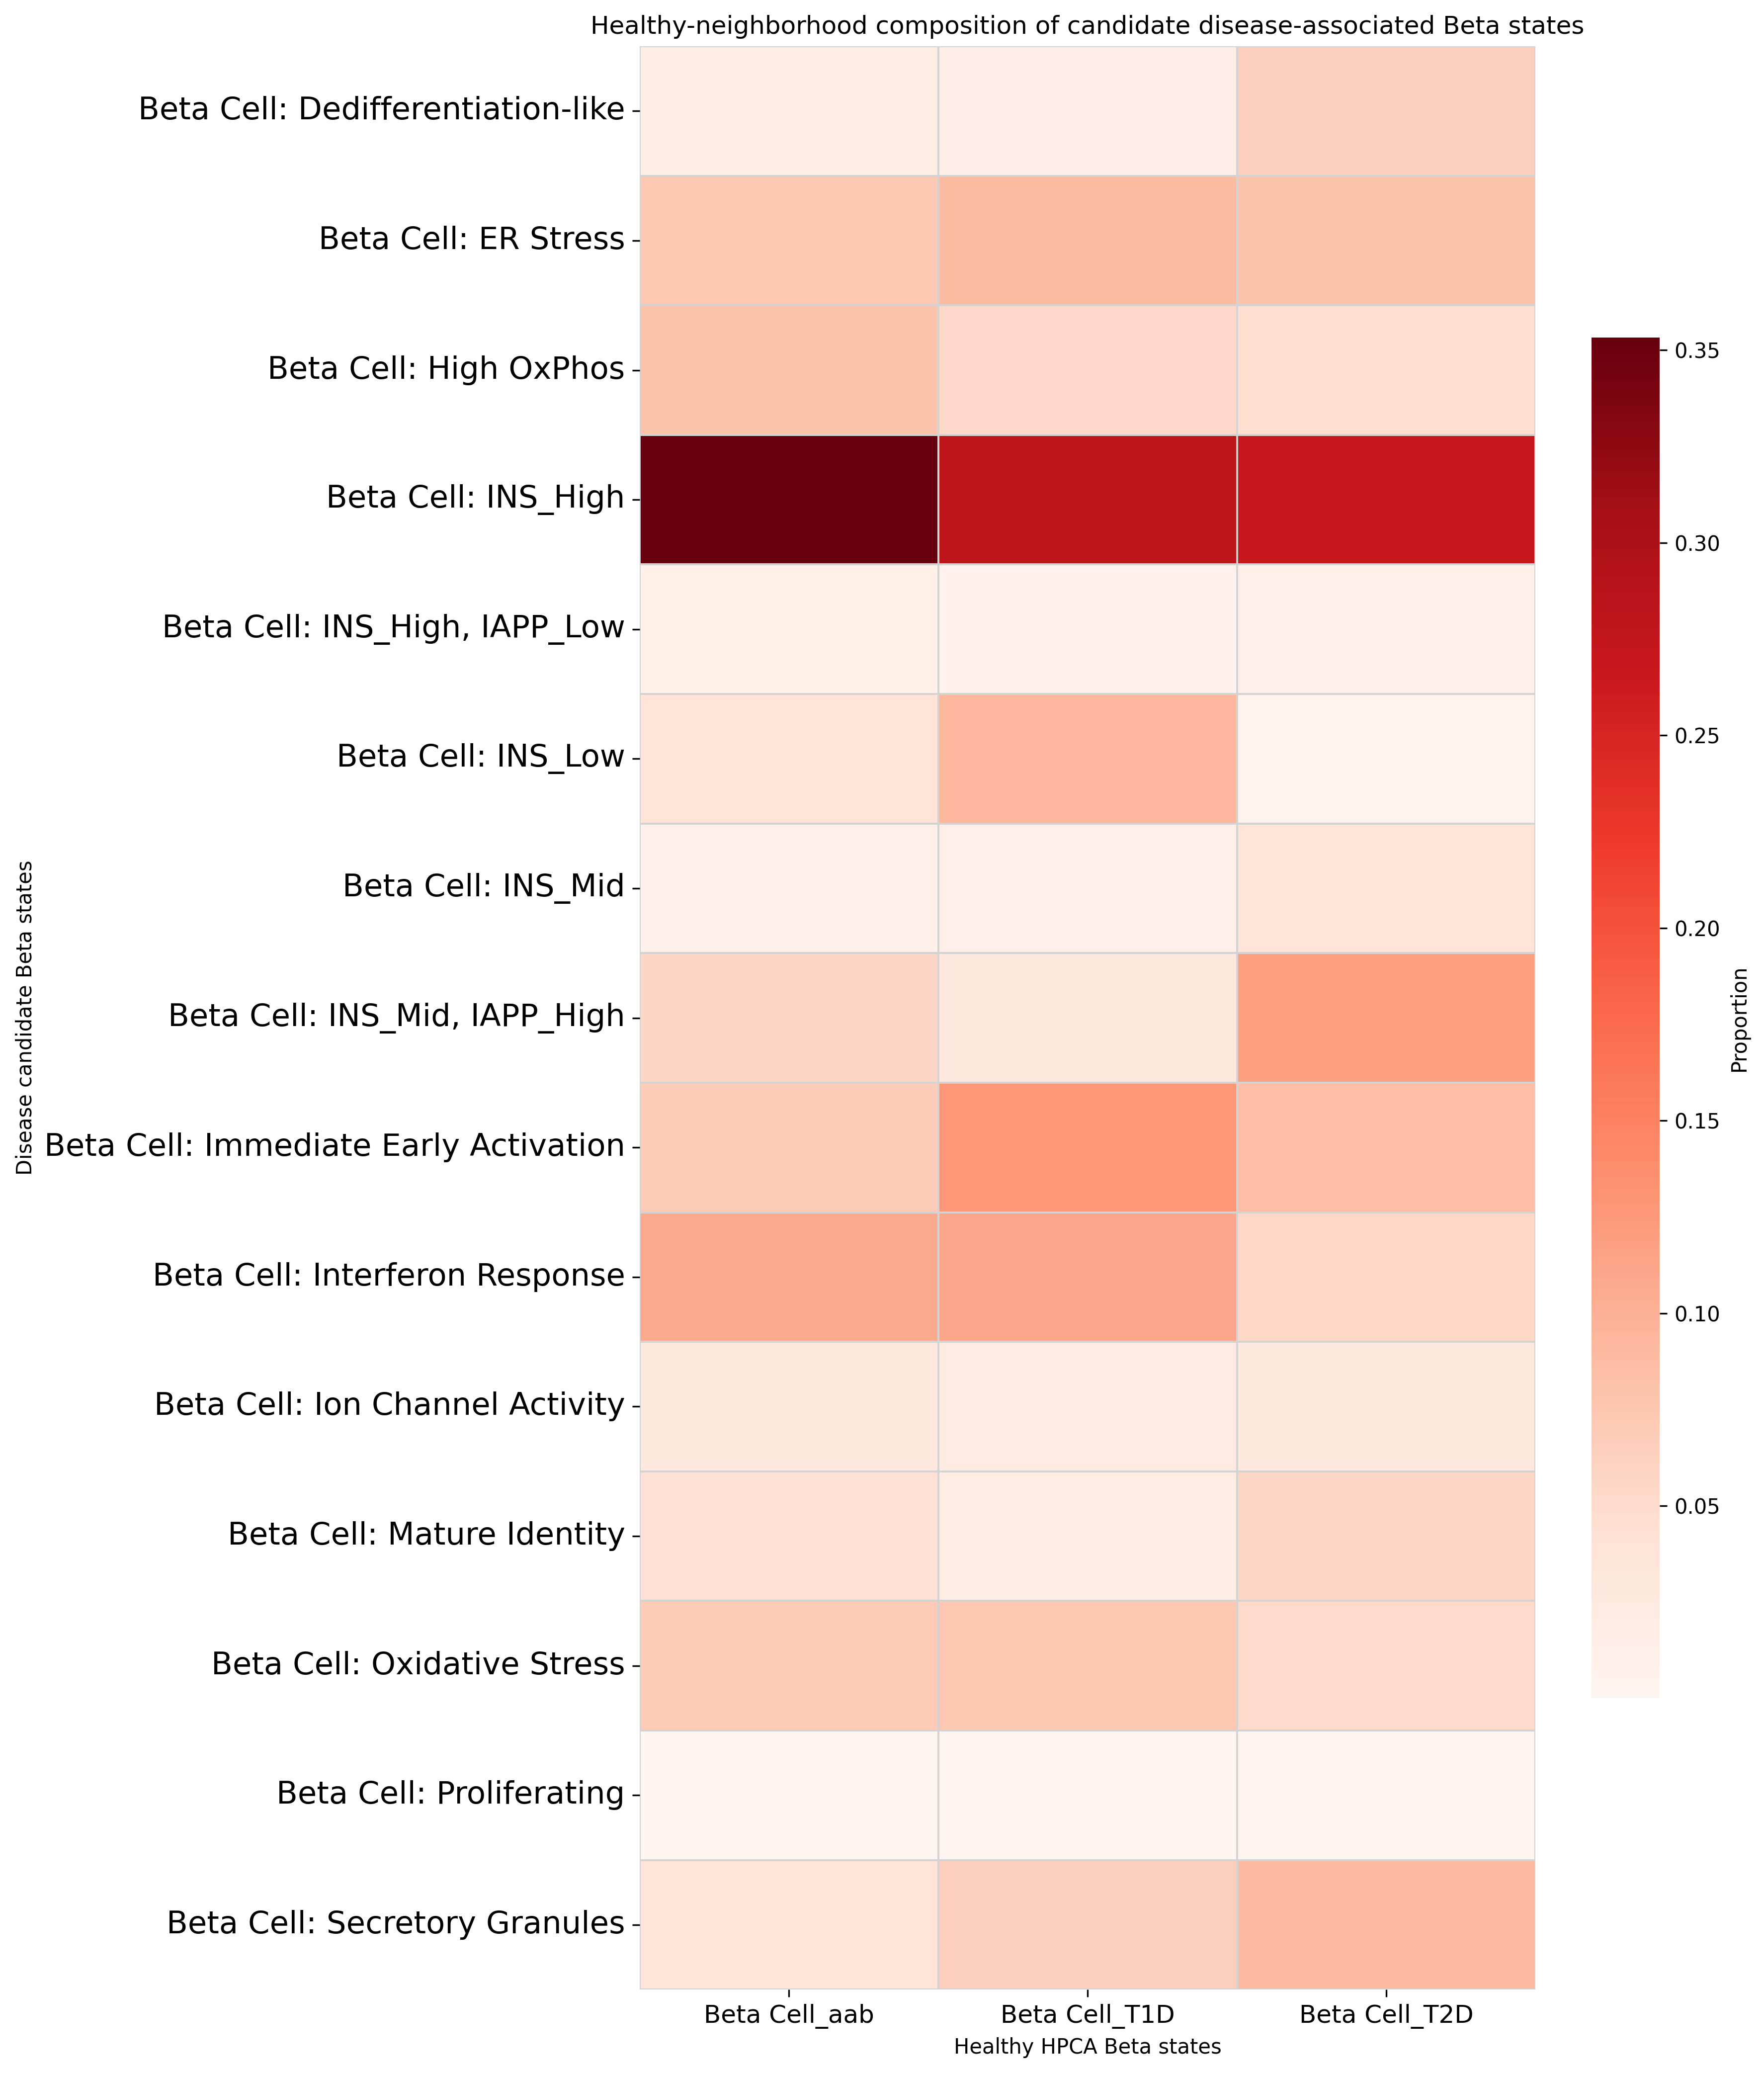

In [32]:
plot_knn_composition_heatmap(beta_knn_comp,) #save_path='figures/beta_knn_comp.svg')

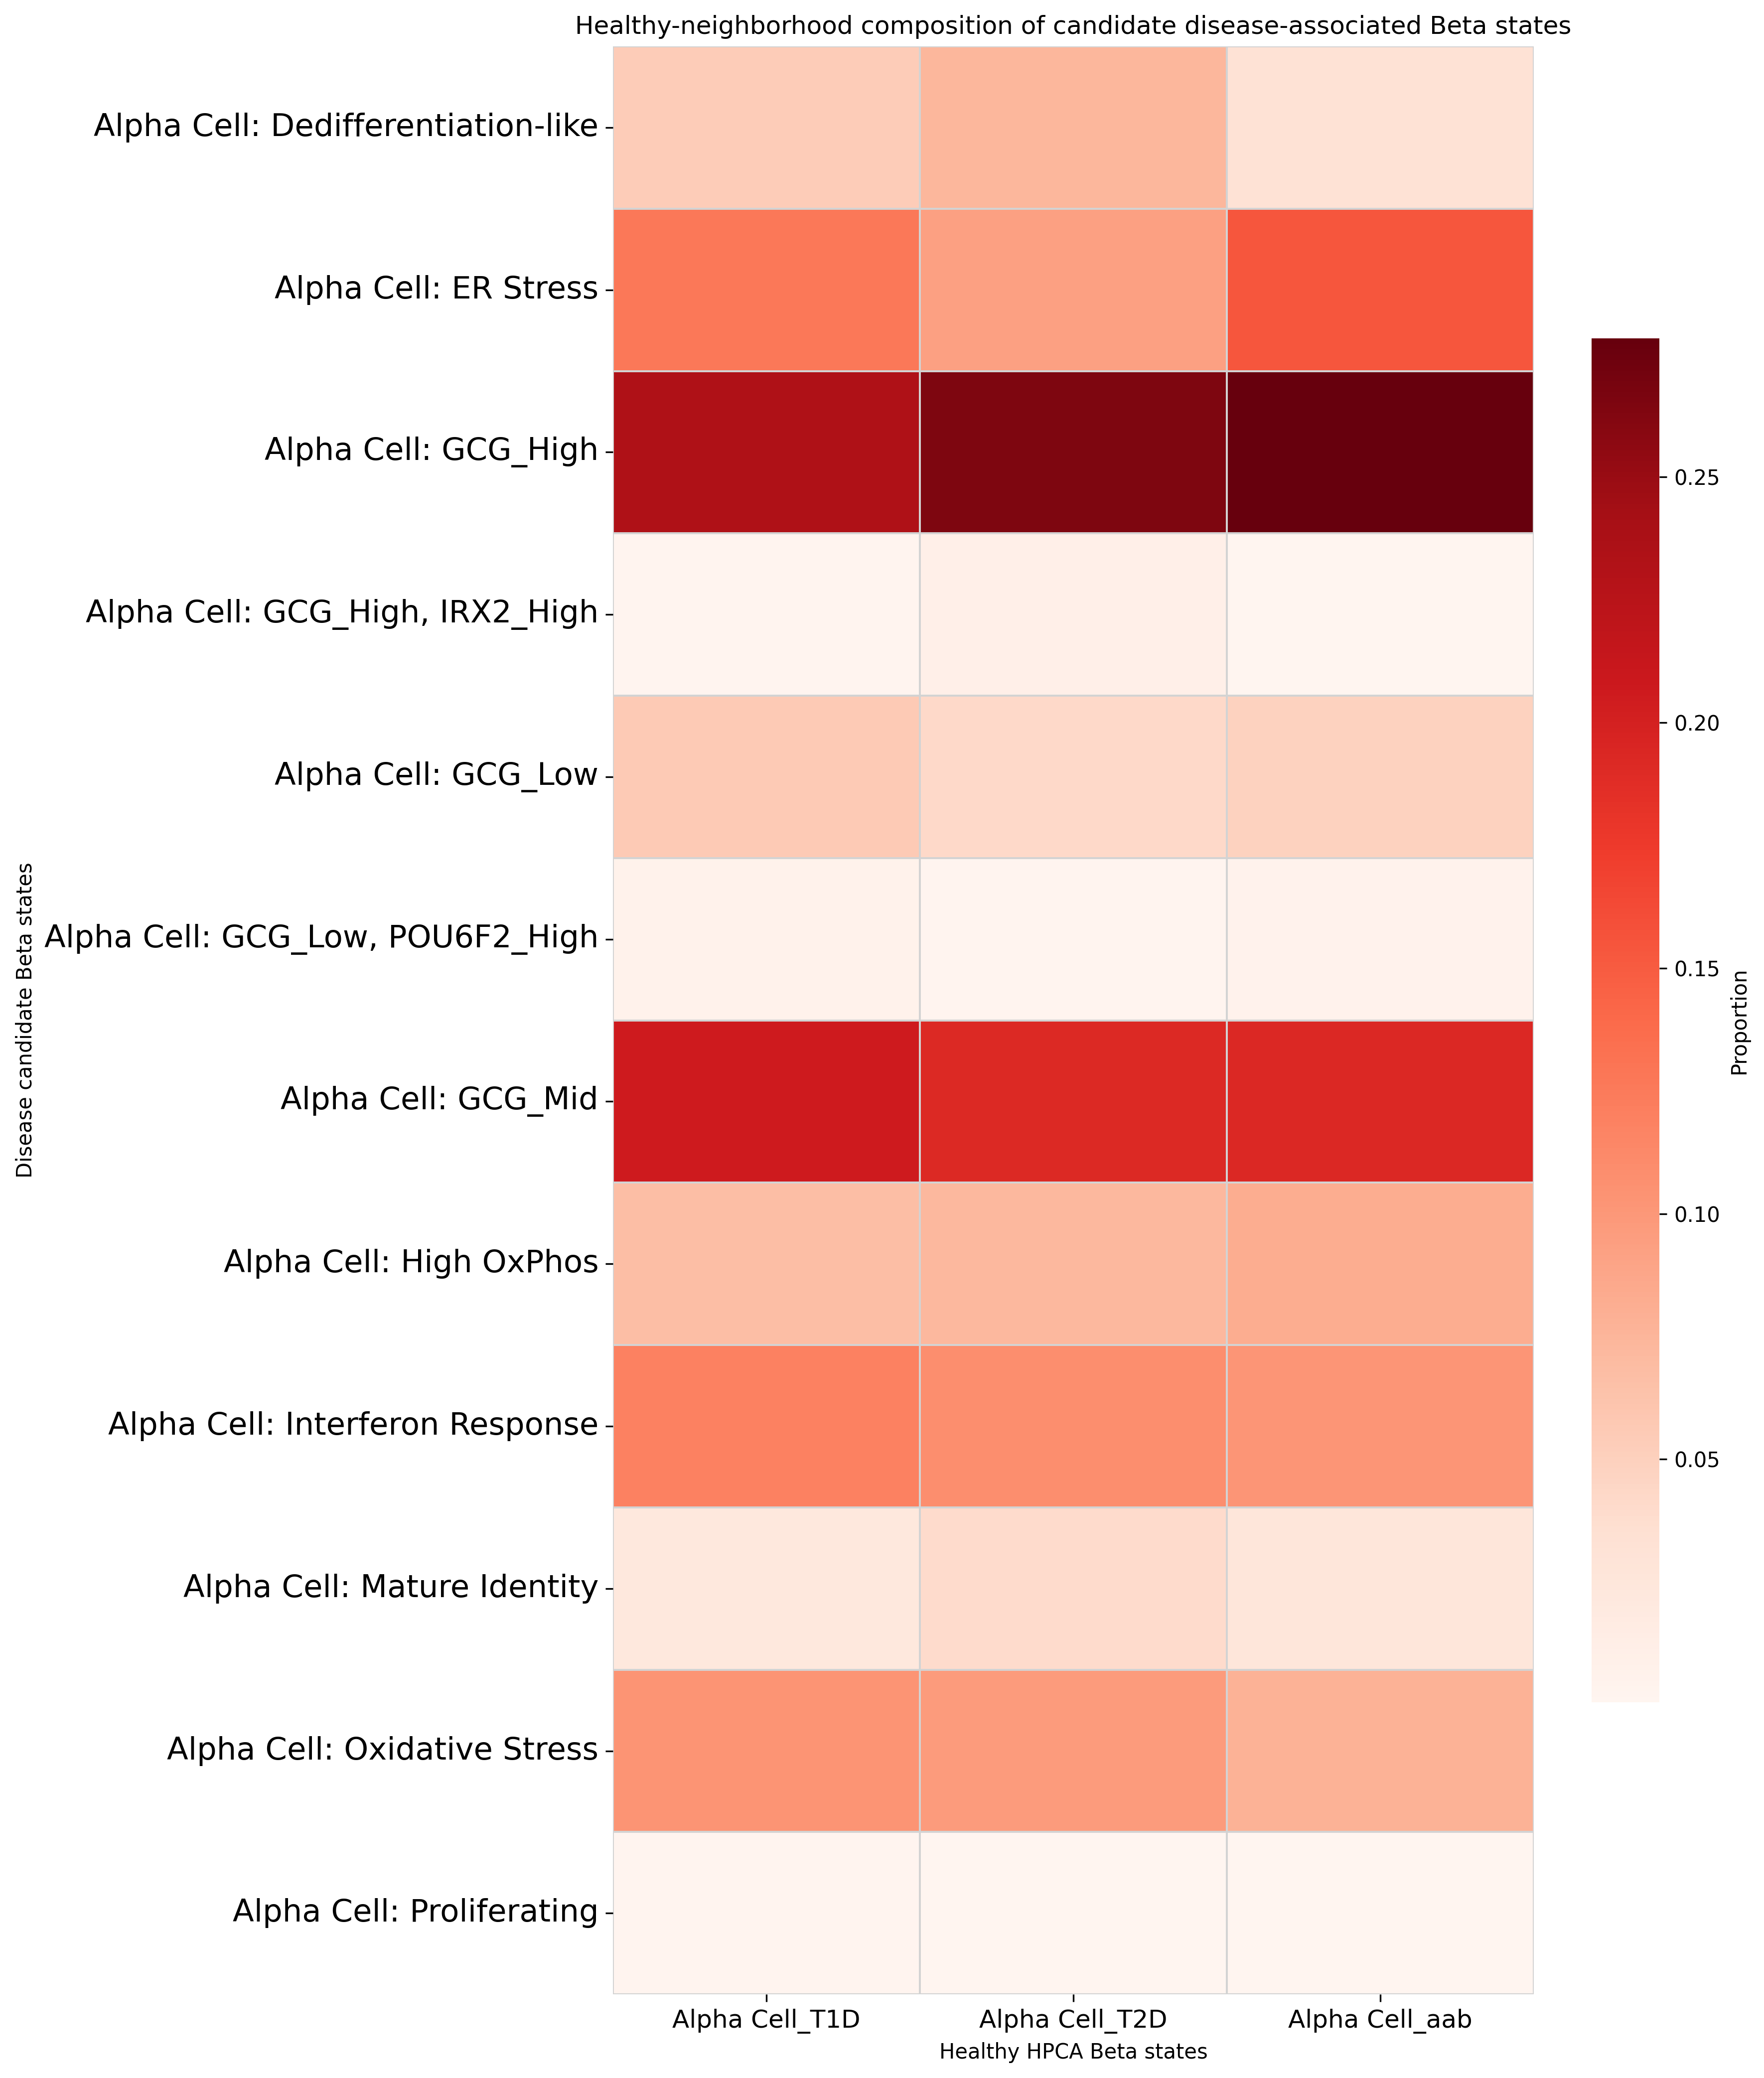

In [33]:
plot_knn_composition_heatmap(alpha_knn_comp, save_path='figures/alpha_knn_comp.svg')

# Entropy

In [34]:
from scipy.stats import entropy
def compute_disease_to_core_weighted_entropy(
    adata_sub,
    disease_labels,
    label_col="Level_4_extension_diabetes_simplified",
    source_col="source",
    rep_key="X_scvi",
    core_label="core",
    n_neighbors=50,
    distance_epsilon=1e-6,
    normalize_entropy=True,
):
    """
    Compute weighted Shannon entropy for disease-associated cells
    using ONLY healthy/core neighbors as reference.

    Question:
    How diffusely vs specifically does a disease-associated cell
    localize within the healthy HPCA manifold?
    """
    healthy_mask = (
        (adata_sub.obs[source_col] == core_label) &
        (~adata_sub.obs[label_col].astype(str).str.contains("T1D|T2D|aab", na=False))
    )

    healthy = adata_sub[healthy_mask].copy()

    print(f"Healthy reference cells: {healthy.n_obs}")

    healthy_labels = healthy.obs[label_col].astype(str).values
    unique_labels = np.unique(healthy_labels)
    X_ref = normalize(healthy.obsm[rep_key])

    nn = NearestNeighbors(
        n_neighbors=n_neighbors,
        metric="cosine",
        algorithm="brute",
    )

    nn.fit(X_ref)
    entropy_results = []
    for disease_label in disease_labels:

        query_mask = adata_sub.obs[label_col].astype(str).eq(disease_label)

        query = adata_sub[query_mask].copy()

        print(f"\n{disease_label}: {query.n_obs} cells")

        if query.n_obs == 0:
            continue

        X_query = normalize(query.obsm[rep_key])

        distances, indices = nn.kneighbors(X_query)
        for cell_id, neigh_idx, neigh_dist in zip(
            query.obs_names,
            indices,
            distances,
        ):

            neigh_labels = healthy_labels[neigh_idx]

            # inverse-distance weighting
            weights = 1.0 / (neigh_dist + distance_epsilon)

            # aggregate weights by healthy label
            weight_df = pd.DataFrame({
                "label": neigh_labels,
                "weight": weights,
            })

            label_weights = (
                weight_df
                .groupby("label")["weight"]
                .sum()
            )

            probs = label_weights / label_weights.sum()

            # Shannon entropy
            H = entropy(probs.values, base=2)

            # normalize to [0,1]
            if normalize_entropy:
                H = H / np.log2(len(unique_labels))

            entropy_results.append({
                "cell_id": cell_id,
                "disease_state": disease_label,
                "weighted_entropy": H,
                "dominant_healthy_state": probs.idxmax(),
                "dominant_healthy_weight": probs.max(),
                "n_unique_neighbor_states": len(probs),
            })

    entropy_df = pd.DataFrame(entropy_results)

    return entropy_df

In [35]:
beta_entropy_df = compute_disease_to_core_weighted_entropy(
    beta_cells,
    disease_labels=beta_disease_labels,
    label_col="Level_4_extension_diabetes_simplified",
    source_col="source",
    rep_key="X_scvi",
    n_neighbors=50,
)

Healthy reference cells: 82668

Beta Cell_T1D: 396 cells

Beta Cell_T2D: 3410 cells

Beta Cell_aab: 2621 cells


In [36]:
alpha_entropy_df = compute_disease_to_core_weighted_entropy(
    alpha_cells,
    disease_labels=alpha_disease_labels,
    label_col="Level_4_extension_diabetes_simplified",
    source_col="source",
    rep_key="X_scvi",
    n_neighbors=50,
)

Healthy reference cells: 105249

Alpha Cell_T1D: 2646 cells

Alpha Cell_T2D: 4752 cells

Alpha Cell_aab: 1996 cells


In [37]:
beta_entropy_df

,cell_id,disease_state,weighted_entropy,dominant_healthy_state,dominant_healthy_weight,n_unique_neighbor_states
0,MM_401_AGGAGGTCAGGCGTTC-1_0,Beta Cell_T1D,0.330532,Beta Cell: INS_Low,0.600625,4
1,MM_401_CACACAACATCAGTGT-1_0,Beta Cell_T1D,0.400320,Beta Cell: INS_Low,0.448436,5
2,MM_401_CCGGTGACATCCGTGG-1_0,Beta Cell_T1D,0.404508,Beta Cell: Interferon Response,0.495180,6
3,MM_401_CGGGTCAAGTTGGCTT-1_0,Beta Cell_T1D,0.383269,Beta Cell: INS_Low,0.590017,5
4,MM_401_GGGAAGTAGTGGCGAT-1_0,Beta Cell_T1D,0.516814,Beta Cell: INS_Low,0.457861,7
...,...,...,...,...,...,...
6422,HPAP-107_TTTCGATAGGTCACTT-1_1,Beta Cell_aab,0.389827,Beta Cell: INS_High,0.461033,6
6423,HPAP-107_TTTGACTTCCTAAACG-1_1,Beta Cell_aab,0.261891,Beta Cell: INS_High,0.644842,3
6424,HPAP-107_TTTGATCCACGACCTG-1_1,Beta Cell_aab,0.241921,Beta Cell: INS_High,0.806577,4
6425,HPAP-107_TTTGGAGGTGGTAATA-1_1,Beta Cell_aab,0.389298,Beta Cell: INS_High,0.533820,4


In [38]:
beta_entropy_summary = (
    beta_entropy_df
    .groupby("disease_state")["weighted_entropy"]
    .agg(["median", "mean", "std", "min", "max"])
)

beta_entropy_summary

,median,mean,std,min,max
disease_state,,,,,
Beta Cell_T1D,0.406701,0.411813,0.094530,0.165803,0.737198
Beta Cell_T2D,0.469094,0.468524,0.104096,0.148496,0.854332
Beta Cell_aab,0.396276,0.401433,0.093317,0.140105,0.718899


In [39]:
alpha_entropy_summary = (
    alpha_entropy_df
    .groupby("disease_state")["weighted_entropy"]
    .agg(["median", "mean", "std", "min", "max"])
)

alpha_entropy_summary

,median,mean,std,min,max
disease_state,,,,,
Alpha Cell_T1D,0.428940,0.433339,0.098057,0.165260,0.798994
Alpha Cell_T2D,0.417717,0.424121,0.104045,0.111055,0.771108
Alpha Cell_aab,0.421106,0.423265,0.092155,0.116265,0.754588


In [40]:
dominant_state_summary = (
    beta_entropy_df
    .groupby("disease_state")["dominant_healthy_state"]
    .value_counts(normalize=True)
    .rename("fraction")
    .reset_index()
)

# For each disease_state, keep only the top 3 dominant_healthy_state by fraction
dominant_state_summary = (
    dominant_state_summary
    .sort_values(["disease_state", "fraction"], ascending=[True, False])
    .groupby("disease_state")
    .head(5)
    .reset_index(drop=True)
)

dominant_state_summary

,disease_state,dominant_healthy_state,fraction
0,Beta Cell_T1D,Beta Cell: INS_High,0.300505
1,Beta Cell_T1D,Beta Cell: Immediate Early Activation,0.136364
2,Beta Cell_T1D,Beta Cell: Interferon Response,0.133838
3,Beta Cell_T1D,Beta Cell: INS_Low,0.118687
4,Beta Cell_T1D,Beta Cell: ER Stress,0.106061
5,Beta Cell_T2D,Beta Cell: INS_High,0.274780
6,Beta Cell_T2D,"Beta Cell: INS_Mid, IAPP_High",0.102346
7,Beta Cell_T2D,Beta Cell: ER Stress,0.100880
8,Beta Cell_T2D,Beta Cell: Immediate Early Activation,0.095601
9,Beta Cell_T2D,Beta Cell: Secretory Granules,0.092082


In [41]:
adata

AnnData object with n_obs × n_vars = 1086688 × 36805
    obs: 'barcode', 'Dataset', 'ID', 'sample_id', 'donor_id', 'alignment_software', 'assay_ontology_term_id', 'institute', 'library_id', 'library_preparation_batch', 'library_sequencing_run', 'Manual_Annotation', 'cell_enrichment', 'condition', 'celltype_all', 'manner_of_death', 'reference_genome', 'sample_collection_method', 'sample_source', 'sampled_site_condition', 'samples', 'sex', 'sex--cell_ontology_term_id', 'suspension_type', 'technology', 'tissue_type', 'assay', 'tissue', 'organism', 'disease', 'gene_annotation_version', 'batch_covar_split', 'batch_covar_split_donor_id', 'batch_covariate', 'info_batch_covariate_split', 'doublet_score', 'predicted_doublet', 'n_genes', 'total_counts', 'total_counts_mito', 'total_counts_ribo', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mito', 'log1p_total_counts_ribo', 'n_genes_by_counts', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top

In [42]:
dominant_state_summary = (
    alpha_entropy_df
    .groupby("disease_state")["dominant_healthy_state"]
    .value_counts(normalize=True)
    .rename("fraction")
    .reset_index()
)

# For each disease_state, keep only the top 3 dominant_healthy_state by fraction
dominant_state_summary = (
    dominant_state_summary
    .sort_values(["disease_state", "fraction"], ascending=[True, False])
    .groupby("disease_state")
    .head(5)
    .reset_index(drop=True)
)

dominant_state_summary

,disease_state,dominant_healthy_state,fraction
0,Alpha Cell_T1D,Alpha Cell: GCG_High,0.250945
1,Alpha Cell_T1D,Alpha Cell: Interferon Response,0.160242
2,Alpha Cell_T1D,Alpha Cell: GCG_Mid,0.151550
3,Alpha Cell_T1D,Alpha Cell: ER Stress,0.144369
4,Alpha Cell_T1D,Alpha Cell: Oxidative Stress,0.114135
5,Alpha Cell_T2D,Alpha Cell: GCG_High,0.268729
6,Alpha Cell_T2D,Alpha Cell: GCG_Mid,0.144150
7,Alpha Cell_T2D,Alpha Cell: Interferon Response,0.135522
8,Alpha Cell_T2D,Alpha Cell: Oxidative Stress,0.114689
9,Alpha Cell_T2D,Alpha Cell: ER Stress,0.106481


In [43]:
import os
os.chdir('/')

In [44]:
import yaml
with open("workspace/hpca/hpca_downstream/hpca_color_palette.yaml", "r") as f:
    palettes = yaml.safe_load(f)


In [45]:
os.chdir('workspace/hpca/hpca_downstream/Diabetes_Results/')

In [46]:
palettes['Level_3_extension_diabetes']

{'Pancreatic Polypeptide Cell': '#8e44ad',
 'Alpha Cell': '#e67e22',
 'Beta Cell': '#1f77b4',
 'Ductal Cell': '#17becf',
 'Stellate Cell': '#a6761d',
 'Delta Cell': '#2ca02c',
 'Mixed Endocrine Cell': '#7f7f7f',
 'Pericyte': '#8c564b',
 'T Cell': '#d62728',
 'Epsilon Cell': '#bcbd22',
 'Schwann Cell': '#9467bd',
 'Endothelial Cell': '#1b9e77',
 'Acinar Cell': '#66a61e',
 'Mast Cell': '#e7298a',
 'Fibroblast': '#b15928',
 'Macrophage': '#ff7f0e',
 'NK Cell': '#fb9a99',
 'Smooth Muscle Cell': '#6a3d9a',
 'Plasma Cell': '#cab2d6',
 'Adipocyte': '#fdbf6f',
 'Delta Cell_T1D': '#e53935',
 'Beta Cell_T1D': '#8e24aa',
 'Alpha Cell_T1D': '#d81b60',
 'Pancreatic Polypeptide Cell_T1D': '#ad1457',
 'Alpha Cell_T2D': '#00acc1',
 'Beta Cell_T2D': '#1e88e5',
 'Delta Cell_T2D': '#00e5ff',
 'Pancreatic Polypeptide Cell_T2D': '#1565c0',
 'Beta Cell_aab': '#ffb300',
 'Alpha Cell_aab': '#fdd835',
 'Delta Cell_aab': '#ff8f00',
 'Pancreatic Polypeptide Cell_aab': '#f57f17'}

In [47]:
# Subset Level_3_extension_diabetes palette to just Alpha/Beta Cell *_T1D, *_T2D, *_aab, and also just Beta Cell and Alpha Cell (no suffix)
beta_alpha_keys = [
    k for k in palettes['Level_3_extension_diabetes'].keys()
    if (
        (k.startswith("Beta Cell") or k.startswith("Alpha Cell"))
        and (
            k.endswith("_T1D")
            or k.endswith("_T2D")
            or k.endswith("_aab")
            or k == "Beta Cell"
            or k == "Alpha Cell"
        )
    )
]
beta_alpha_palette = {k: palettes['Level_3_extension_diabetes'][k] for k in beta_alpha_keys}
beta_alpha_palette

{'Alpha Cell': '#e67e22',
 'Beta Cell': '#1f77b4',
 'Beta Cell_T1D': '#8e24aa',
 'Alpha Cell_T1D': '#d81b60',
 'Alpha Cell_T2D': '#00acc1',
 'Beta Cell_T2D': '#1e88e5',
 'Beta Cell_aab': '#ffb300',
 'Alpha Cell_aab': '#fdd835'}

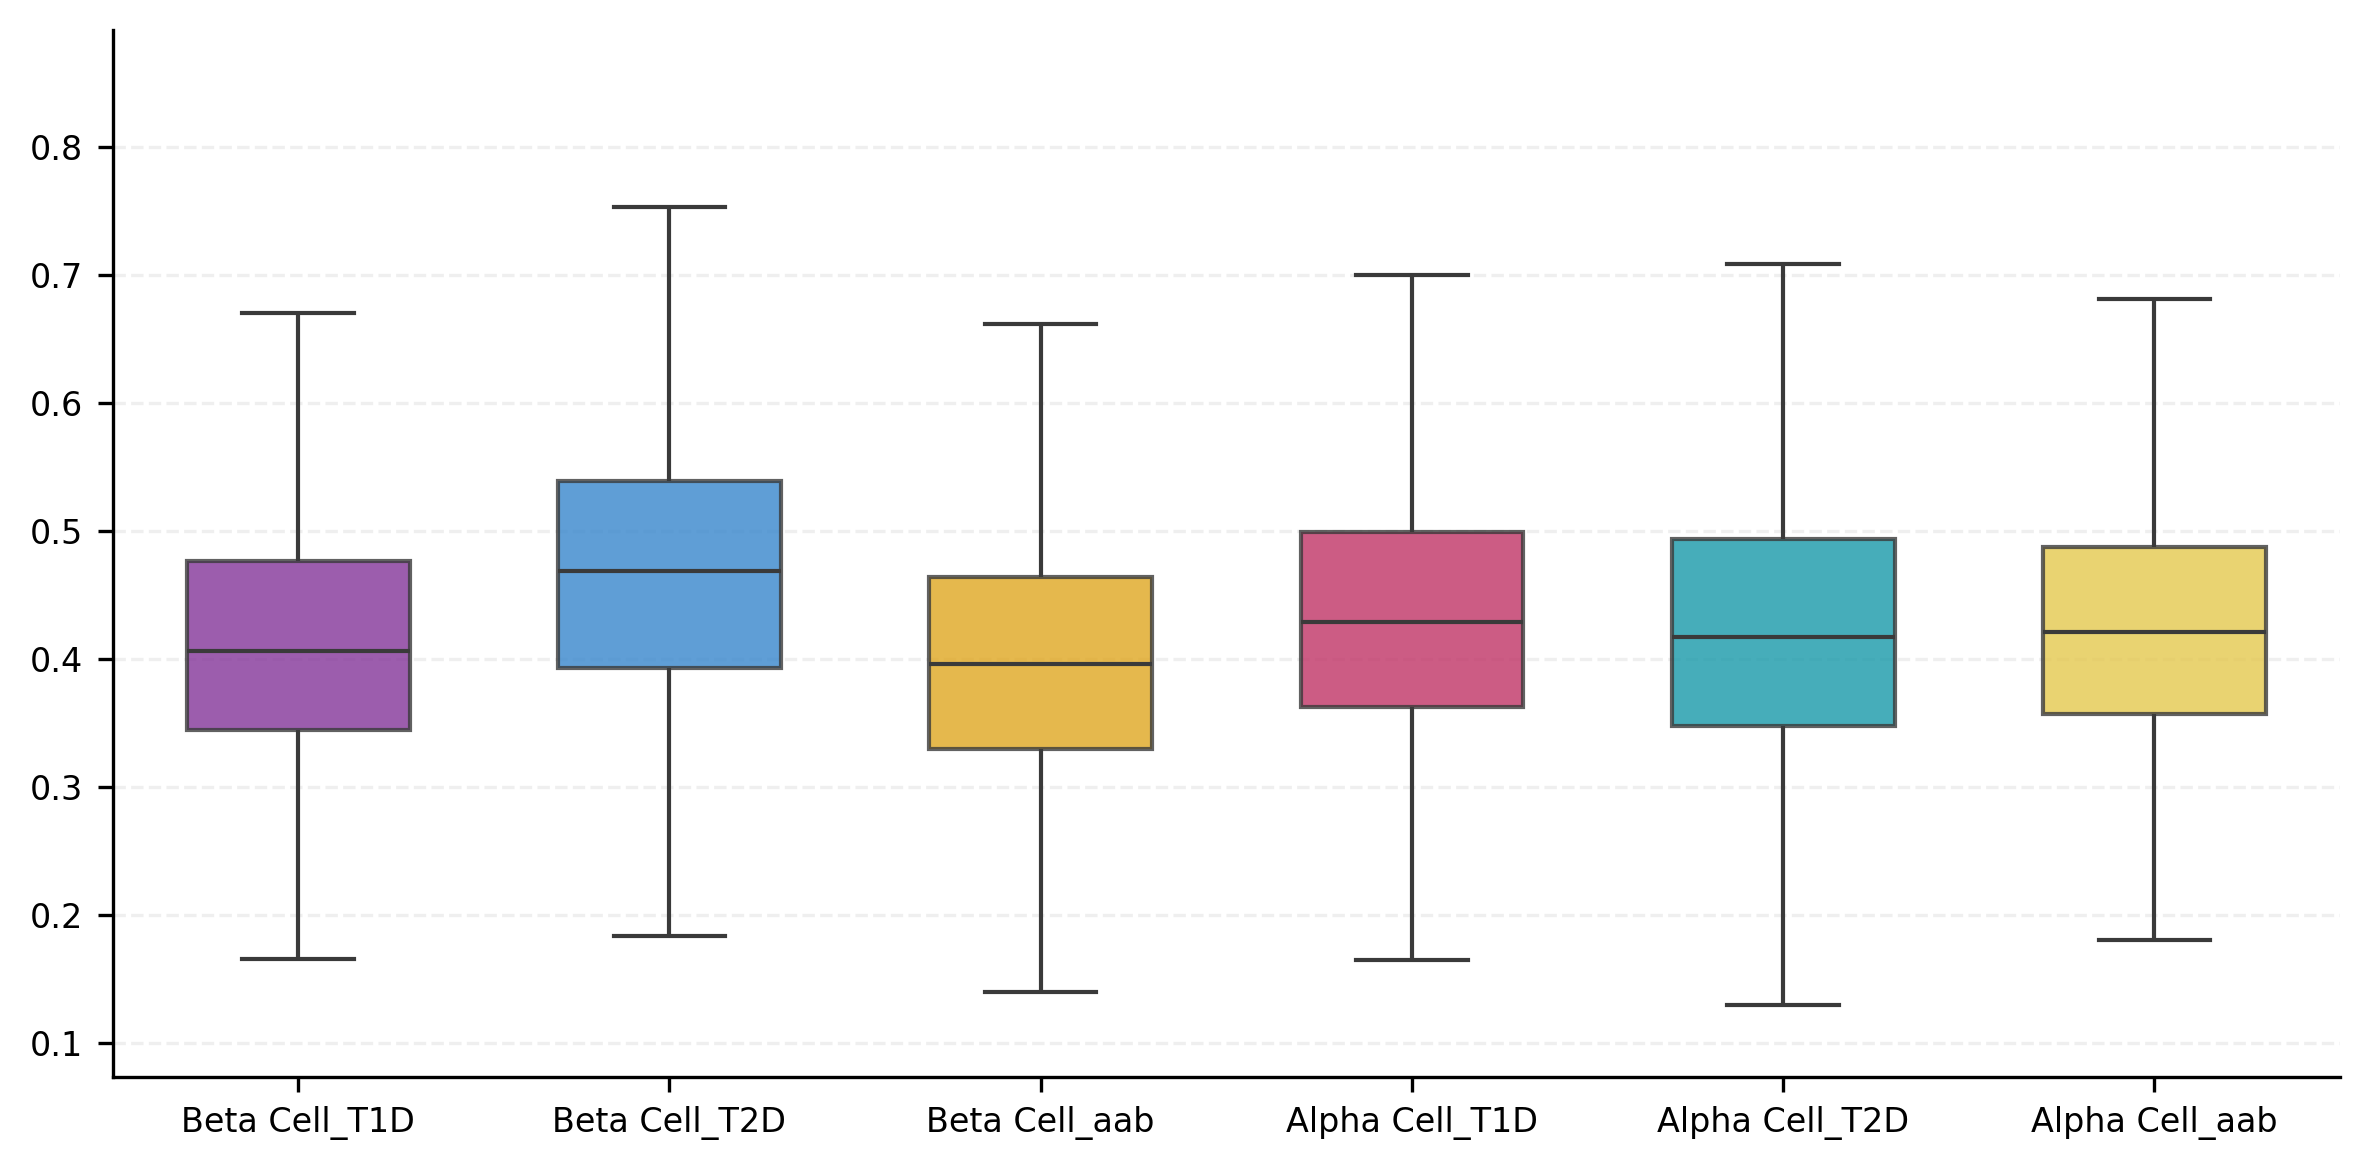

In [48]:
plt.figure(figsize=(8, 4), dpi=300)

beta_df_plot = beta_entropy_df.copy()
beta_df_plot["Cell Type"] = beta_df_plot["disease_state"].copy()

alpha_df_plot = alpha_entropy_df.copy()
alpha_df_plot["Cell Type"] = alpha_df_plot["disease_state"].copy()

df_plot = pd.concat([beta_df_plot, alpha_df_plot], ignore_index=True)

ax = sns.boxplot(
    data=df_plot,
    x="disease_state",
    y="weighted_entropy",
    hue="disease_state",
    width=0.6,
    linewidth=1,
    fliersize=0,
    boxprops=dict(alpha=0.8),
    palette=beta_alpha_palette
)

plt.ylabel("", fontsize=14, labelpad=10)
plt.xlabel("")
plt.title("", fontsize=16, fontweight="bold", pad=15)

plt.xticks(fontsize=8, rotation=0)
plt.yticks(fontsize=8)
sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.2)
plt.tight_layout()
plt.savefig("figures/beta_alpha_entropy_boxplot.svg", format="svg", dpi=300)
plt.show()

In [49]:
from scipy.stats import entropy

label_col = "Level_4_extension_diabetes_simplified"
source_col = "source"
core_label = "core"
dominant_col = "dominant_healthy_state"
entropy_col = "weighted_entropy"

In [50]:
def summarize_knn_neighbors_per_cell(
    neighbor_df,
    distance_epsilon=1e-6,
    normalize_entropy=True,
):
    rows = []

    all_states = neighbor_df["neighbor_state"].astype(str).unique()
    n_total_states = len(all_states)

    for cell_id, sub in neighbor_df.groupby("query_cell"):
        disease_state = sub["disease_state"].iloc[0]

        weights = 1.0 / (sub["cosine_distance"].values + distance_epsilon)

        wdf = pd.DataFrame({
            "neighbor_state": sub["neighbor_state"].astype(str).values,
            "weight": weights,
        })

        state_weights = wdf.groupby("neighbor_state")["weight"].sum()
        probs = state_weights / state_weights.sum()

        H = entropy(probs.values, base=2)

        if normalize_entropy and n_total_states > 1:
            H = H / np.log2(n_total_states)

        rows.append({
            "cell_id": cell_id,
            "disease_state": disease_state,
            "dominant_healthy_state": probs.idxmax(),
            "dominant_healthy_weight": probs.max(),
            "weighted_entropy": H,
            "n_neighbor_states": len(probs),
        })

    return pd.DataFrame(rows)

In [143]:
beta_knn_summary = summarize_knn_neighbors_per_cell(beta_neighbor_df)
alpha_knn_summary = summarize_knn_neighbors_per_cell(alpha_neighbor_df)

knn_summary = pd.concat(
    [beta_knn_summary, alpha_knn_summary],
    axis=0,
    ignore_index=True,
)

knn_summary

,cell_id,disease_state,dominant_healthy_state,dominant_healthy_weight,weighted_entropy,n_neighbor_states
0,AAACCCAAGCCGCTTG-1_0,Beta Cell_T2D,Beta Cell: INS_High,0.578338,0.402118,5
1,AAACCCACACGGTGCT-1_0,Beta Cell_T2D,Beta Cell: Interferon Response,0.599407,0.429106,7
2,AAACCCAGTCATCCCT-1_0-1,Beta Cell_T2D,Beta Cell: Ion Channel Activity,0.463581,0.389626,3
3,AAACCCATCACCCATC-1_0,Beta Cell_T2D,Beta Cell: INS_High,0.423717,0.516063,6
4,AAACGAAAGCGCCTTG-1_0,Beta Cell_T2D,Beta Cell: Mature Identity,0.362960,0.534852,5
...,...,...,...,...,...,...
15816,TTTGATCCAGCAATTC-1_0,Alpha Cell_T2D,Alpha Cell: Interferon Response,0.473211,0.430269,6
15817,TTTGGAGAGTTCATCG-1_0,Alpha Cell_T2D,"Alpha Cell: GCG_High, IRX2_High",0.430402,0.464440,5
15818,TTTGGAGTCCATTCAT-1_0,Alpha Cell_T2D,Alpha Cell: GCG_High,0.597784,0.392324,4
15819,TTTGGTTTCCAGCTCT-1_0,Alpha Cell_T2D,Alpha Cell: Dedifferentiation-like,0.492101,0.444278,5


In [144]:
def add_knn_summary_to_adata(adata_sub, knn_summary):
    knn_summary = knn_summary.set_index("cell_id")

    for col in [
        "disease_state",
        "dominant_healthy_state",
        "dominant_healthy_weight",
        "weighted_entropy",
        "n_neighbor_states",
    ]:
        adata_sub.obs[col] = adata_sub.obs_names.map(knn_summary[col])

    return adata_sub

In [145]:
beta_cells = add_knn_summary_to_adata(beta_cells, beta_knn_summary)
alpha_cells = add_knn_summary_to_adata(alpha_cells, alpha_knn_summary)

In [146]:
display(
    beta_cells.obs.loc[
        beta_cells.obs[dominant_col].notna(),
        [label_col, dominant_col, "dominant_healthy_weight", entropy_col]
    ].head()
)

display(
    alpha_cells.obs.loc[
        alpha_cells.obs[dominant_col].notna(),
        [label_col, dominant_col, "dominant_healthy_weight", entropy_col]
    ].head()
)

,Level_4_extension_diabetes_simplified,dominant_healthy_state,dominant_healthy_weight,weighted_entropy
MM_401_AGGAGGTCAGGCGTTC-1_0,Beta Cell_T1D,Beta Cell: INS_Low,0.600625,0.330532
MM_401_CACACAACATCAGTGT-1_0,Beta Cell_T1D,Beta Cell: INS_Low,0.448436,0.400320
MM_401_CCGGTGACATCCGTGG-1_0,Beta Cell_T1D,Beta Cell: Interferon Response,0.495180,0.404508
MM_401_CGGGTCAAGTTGGCTT-1_0,Beta Cell_T1D,Beta Cell: INS_Low,0.590017,0.383269
MM_401_GGGAAGTAGTGGCGAT-1_0,Beta Cell_T1D,Beta Cell: INS_Low,0.457861,0.516814


,Level_4_extension_diabetes_simplified,dominant_healthy_state,dominant_healthy_weight,weighted_entropy
MM_355_GACTCAATCAAACGTC-1_0,Alpha Cell_T1D,Alpha Cell: Oxidative Stress,0.537772,0.277794
MM_380_AGGAAATTCCCAGGAC-1_0,Alpha Cell_T1D,Alpha Cell: Interferon Response,0.714665,0.322719
MM_380_AGTAGCTCAAATGCGG-1_0,Alpha Cell_T1D,Alpha Cell: High OxPhos,0.601883,0.383626
MM_380_ATCATTCAGAGAATCT-1_0,Alpha Cell_T1D,Alpha Cell: GCG_Low,0.708070,0.370883
MM_380_CACTAAGGTCCTCCAT-1_0,Alpha Cell_T1D,Alpha Cell: High OxPhos,0.439534,0.493293


## single cell DE

In [ ]:
# from cProfile import label


# def state_matched_de(
#     adata_sub,
#     disease_state,
#     healthy_state,
#     label_col="Level_4_extension_diabetes_simplified",
#     source_col="source",
#     dominant_col="dominant_healthy_state",
#     core_label="core",
#     min_disease_cells=30,
#     min_healthy_cells=30,
#     method="wilcoxon",
# ):
#     disease_mask = (
#         adata_sub.obs[label_col].astype(str).eq(disease_state)
#         & adata_sub.obs[dominant_col].astype(str).eq(healthy_state)
#     )

#     healthy_mask = (
#         adata_sub.obs[source_col].astype(str).eq(core_label)
#         & adata_sub.obs[label_col].astype(str).eq(healthy_state)
#     )

#     n_disease = int(disease_mask.sum())
#     n_healthy = int(healthy_mask.sum())

#     print(f"{disease_state} mapped to {healthy_state}")
#     print(f"  disease cells: {n_disease}")
#     print(f"  healthy cells: {n_healthy}")

#     if n_disease < min_disease_cells or n_healthy < min_healthy_cells:
#         print("  skipped: too few cells\n")
#         return None

#     tmp = adata_sub[disease_mask | healthy_mask].copy()

#     tmp.obs["de_group"] = "healthy"
#     tmp.obs.loc[tmp.obs_names.isin(adata_sub.obs_names[disease_mask]), "de_group"] = "disease"

#     tmp.obs["de_group"] = pd.Categorical(
#         tmp.obs["de_group"],
#         categories=["healthy", "disease"],
#     )

#     sc.tl.rank_genes_groups(
#         tmp,
#         groupby="de_group",
#         groups=["disease"],
#         reference="healthy",
#         method=method,
#         use_raw=False,
#     )

#     res = sc.get.rank_genes_groups_df(tmp, group="disease")

#     res["disease_state"] = disease_state
#     res["matched_healthy_state"] = healthy_state
#     res["n_disease"] = n_disease
#     res["n_healthy"] = n_healthy

#     return res

# def get_top_dominant_states(
#     adata_sub,
#     disease_states,
#     label_col="Level_4_extension_diabetes_simplified",
#     dominant_col="dominant_healthy_state",
#     source_col="Cell Type Grouped",
#     top_n=3,
#     min_cells=30,
# ):
#     rows = []

#     # get the healthy core label for each disease state (by stripping _T1D/_T2D/_aab/etc.)
#     def get_core_label(dstate):
#         # Heuristics: expect form like "Beta Cell_T1D" -> "Beta Cell"
#         return dstate.split("_")[0]

#     for dstate in disease_states:
#         sub = adata_sub.obs.loc[
#             adata_sub.obs[label_col].astype(str).eq(dstate)
#             & adata_sub.obs[dominant_col].notna()
#         ]

#         counts = sub[dominant_col].value_counts()
#         core_label = get_core_label(dstate)

#         for state, n in counts.head(top_n).items():
#             if n >= min_cells:
#                 # Also count the number of healthy cells of the matched state
#                 healthy_mask = (
#                     adata_sub.obs['source'].astype(str).eq('core')
#                     & adata_sub.obs[label_col].astype(str).eq(state)
#                 )
#                 n_healthy = adata_sub.obs[healthy_mask].shape[0]

#                 rows.append({
#                     "disease_state": dstate,
#                     "matched_healthy_state": state,
#                     "n_disease_cells": int(n),
#                     "fraction": n / len(sub),
#                     "n_healthy_cells": n_healthy,
#                 })

#     return pd.DataFrame(rows)
# beta_disease_states = ["Beta Cell_T1D", "Beta Cell_T2D", "Beta Cell_aab"]
# alpha_disease_states = ["Alpha Cell_T1D", "Alpha Cell_T2D", "Alpha Cell_aab"]

# beta_top_states = get_top_dominant_states(
#     beta_cells,
#     beta_disease_states,
#     top_n=2,
#     min_cells=30,
# )

# alpha_top_states = get_top_dominant_states(
#     alpha_cells,
#     alpha_disease_states,
#     top_n=2,
#     min_cells=30,
# )

# display(beta_top_states)
# display(alpha_top_states)
# def run_state_matched_de(
#     adata_sub,
#     top_states_df,
#     min_disease_cells=30,
#     min_healthy_cells=30,
# ):
#     results = []

#     for _, row in top_states_df.iterrows():
#         res = state_matched_de(
#             adata_sub=adata_sub,
#             disease_state=row["disease_state"],
#             healthy_state=row["matched_healthy_state"],
#             min_disease_cells=min_disease_cells,
#             min_healthy_cells=min_healthy_cells,
#         )

#         if res is not None:
#             results.append(res)

#     if len(results) == 0:
#         return pd.DataFrame()

#     return pd.concat(results, axis=0, ignore_index=True)
# import re
# beta_cells_genes_filtered = beta_cells.copy()
# alpha_cells_genes_filtered = alpha_cells.copy()
# print(f"Beta Cell genes before filtering: {len(beta_cells_genes_filtered.var_names)}")
# sc.pp.filter_genes(beta_cells_genes_filtered, min_cells=5)

# bad_genes_beta = (
#     beta_cells_genes_filtered.var_names.str.startswith(("MT-", "RPL", "RPS", "HB", "LINC"))
#     | beta_cells_genes_filtered.var_names.str.match(r"^A[A-Z]\d+(\.\d+)?$")
# )
# print(f"Beta Cell genes to exclude: {bad_genes_beta.sum()}")
# print(beta_cells_genes_filtered.var_names[bad_genes_beta])

# beta_cells_genes_filtered = beta_cells_genes_filtered[:, ~bad_genes_beta].copy()
# print(f"Beta Cell genes after filtering: {len(beta_cells_genes_filtered.var_names)}")

# # Filter alpha_cells for low-abundance and unwanted genes
# print(f"Alpha Cell genes before filtering: {len(alpha_cells_genes_filtered.var_names)}")
# sc.pp.filter_genes(alpha_cells_genes_filtered, min_cells=5)

# bad_genes_alpha = (
#     alpha_cells_genes_filtered.var_names.str.startswith(("MT-", "RPL", "RPS", "HB", "LINC"))
#     | alpha_cells_genes_filtered.var_names.str.match(r"^A[A-Z]\d+(\.\d+)?$")
# )
# print(f"Alpha Cell genes to exclude: {bad_genes_alpha.sum()}")
# print(alpha_cells_genes_filtered.var_names[bad_genes_alpha])

# alpha_cells_genes_filtered = alpha_cells_genes_filtered[:, ~bad_genes_alpha].copy()
# print(f"Alpha Cell genes after filtering: {len(alpha_cells_genes_filtered.var_names)}")

# beta_cells_genes_filtered.obs.high_ambient_rna = beta_cells_genes_filtered.obs.high_ambient_rna.astype(str)
# alpha_cells_genes_filtered.obs.high_ambient_rna = alpha_cells_genes_filtered.obs.high_ambient_rna.astype(str)
# beta_cells_genes_filtered = beta_cells_genes_filtered[beta_cells_genes_filtered.obs.high_ambient_rna != 'True'].copy()
# alpha_cells_genes_filtered = alpha_cells_genes_filtered[alpha_cells_genes_filtered.obs.high_ambient_rna != 'True'].copy()
# alpha_cells_genes_filtered.X.max()
# alpha_cells_genes_filtered.layers['counts'].max()
# beta_state_matched_de = run_state_matched_de(
#     beta_cells_genes_filtered,
#     beta_top_states,
#     min_disease_cells=30,
#     min_healthy_cells=30,
# )


# alpha_state_matched_de = run_state_matched_de(
#     alpha_cells_genes_filtered,
#     alpha_top_states,
#     min_disease_cells=30,
#     min_healthy_cells=30,
# )
# def top_de_genes(
#     de_df,
#     n=10,
#     padj=0.05,
#     min_logfc=0.25,
# ):
#     if de_df.empty:
#         return de_df

#     return (
#         de_df
#         .query("pvals_adj < @padj and logfoldchanges > @min_logfc")
#         .sort_values(
#             ["disease_state", "matched_healthy_state", "logfoldchanges"],
#             ascending=[True, True, False],
#         )
#         .groupby(["disease_state", "matched_healthy_state"])
#         .head(n)
#     )
# beta_top_de = top_de_genes(beta_state_matched_de, n=30)
# alpha_top_de = top_de_genes(alpha_state_matched_de, n=30)


# beta_top_de
# alpha_top_de
# # Create a DataFrame of n_disease_donors and n_healthy_donors for each (disease_state, matched_healthy_state) pair in beta_top_pb
# cell_counts_beta = (
#     beta_top_de.groupby(['disease_state', 'matched_healthy_state'])
#     .agg({'n_disease':'first', 'n_healthy':'first'})
#     .reset_index()
# )
# cell_counts_alpha = (
#     alpha_top_de.groupby(['disease_state', 'matched_healthy_state'])
#     .agg({'n_disease':'first', 'n_healthy':'first'})
#     .reset_index()
# )
# cell_counts = pd.concat([cell_counts_beta, cell_counts_alpha], axis=0, ignore_index=True)
# cell_counts
# pd.set_option('display.max_columns', 35)
# # Build a dataframe of genes for all combinations of disease_state and matched_healthy_state in beta_top_pb
# gene_dict = {}

# for disease_state in beta_top_de.disease_state.unique():
#     for healthy_state in beta_top_de.matched_healthy_state.unique():
#         key = f"{disease_state} vs {healthy_state}"
#         gene_list = beta_top_de[
#             (beta_top_de.disease_state == disease_state) &
#             (beta_top_de.matched_healthy_state == healthy_state)
#         ]['names'].tolist()
#         gene_dict[key] = gene_list

# df_genes_beta = pd.DataFrame.from_dict(gene_dict, orient='index').transpose()
# df_genes_beta = df_genes_beta.dropna(axis=1, how='all')  # Remove columns where all values are None/NaN
# df_genes_beta

# # Build a dataframe of genes for all combinations of disease_state and matched_healthy_state in alpha_top_pb
# gene_dict = {}

# for disease_state in alpha_top_de.disease_state.unique():
#     for healthy_state in alpha_top_de.matched_healthy_state.unique():
#         key = f"{disease_state} vs {healthy_state}"
#         gene_list = alpha_top_de[
#             (alpha_top_de.disease_state == disease_state) &
#             (alpha_top_de.matched_healthy_state == healthy_state)
#         ]['names'].tolist()
#         gene_dict[key] = gene_list

# df_genes_alpha = pd.DataFrame.from_dict(gene_dict, orient='index').transpose()
# df_genes_alpha = df_genes_alpha.dropna(axis=1, how='all')  # Remove columns where all values are None/NaN
# df_genes_alpha


## pydeseq2

In [52]:
!pip install pydeseq2


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [53]:
beta_cells_genes_filtered.layers['counts'].max()

np.float64(137154.0)

In [54]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

def make_pseudobulk(
    adata_sub,
    mask,
    donor_col="Dataset_ID",
    layer="counts",
    min_cells_per_donor=10,
):
    ad = adata_sub[mask].copy()

    if layer is not None and layer in ad.layers:
        X = ad.layers[layer]
    else:
        X = ad.X

    if sparse.issparse(X):
        X = X.tocsr()

    rows = []
    meta = []

    for donor, idx in ad.obs.groupby(donor_col).indices.items():
        if len(idx) < min_cells_per_donor:
            continue

        if sparse.issparse(X):
            counts = np.asarray(X[idx].sum(axis=0)).ravel()
        else:
            counts = X[idx].sum(axis=0)

        rows.append(counts)
        meta.append({
            "sample": donor,
            donor_col: donor,
            "n_cells": len(idx),
        })

    counts_df = pd.DataFrame(
        rows,
        index=[m["sample"] for m in meta],
        columns=ad.var_names,
    ).round().astype(int)

    meta_df = pd.DataFrame(meta).set_index("sample")

    return counts_df, meta_df

def run_state_matched_pydeseq2(
    adata_sub,
    disease_state,
    matched_healthy_state,
    label_col="Level_4_extension_diabetes_simplified",
    source_col="source",
    dominant_col="dominant_healthy_state",
    donor_col="Dataset_ID",
    core_label="core",
    layer="counts",
    min_cells_per_donor=10,
    min_donors_per_group=3,
):
    disease_mask = (
        adata_sub.obs[label_col].astype(str).eq(disease_state)
        & adata_sub.obs[dominant_col].astype(str).eq(matched_healthy_state)
    )

    healthy_mask = (
        adata_sub.obs[source_col].astype(str).eq(core_label)
        & adata_sub.obs[label_col].astype(str).eq(matched_healthy_state)
    )

    disease_counts, disease_meta = make_pseudobulk(
        adata_sub,
        disease_mask,
        donor_col=donor_col,
        layer=layer,
        min_cells_per_donor=min_cells_per_donor,
    )

    healthy_counts, healthy_meta = make_pseudobulk(
        adata_sub,
        healthy_mask,
        donor_col=donor_col,
        layer=layer,
        min_cells_per_donor=min_cells_per_donor,
    )

    disease_meta["condition"] = "disease"
    healthy_meta["condition"] = "healthy"

    counts = pd.concat([disease_counts, healthy_counts], axis=0)
    metadata = pd.concat([disease_meta, healthy_meta], axis=0)

    metadata["condition"] = pd.Categorical(
        metadata["condition"],
        categories=["healthy", "disease"],
    )

    print("\n", disease_state, "vs", matched_healthy_state)
    print(metadata["condition"].value_counts())

    if (metadata["condition"] == "disease").sum() < min_donors_per_group:
        print("Skipping: too few disease donors")
        return None

    if (metadata["condition"] == "healthy").sum() < min_donors_per_group:
        print("Skipping: too few healthy donors")
        return None

    # remove genes with zero total counts
    counts = counts.loc[:, counts.sum(axis=0) > 0]

    dds = DeseqDataSet(
        counts=counts,
        metadata=metadata,
        design_factors="condition",
        refit_cooks=True,
    )

    dds.deseq2()

    stat_res = DeseqStats(
        dds,
        contrast=["condition", "disease", "healthy"],
    )

    stat_res.summary()

    res = stat_res.results_df.copy()
    res["gene"] = res.index
    res["disease_state"] = disease_state
    res["matched_healthy_state"] = matched_healthy_state
    res["n_disease_donors"] = int((metadata["condition"] == "disease").sum())
    res["n_healthy_donors"] = int((metadata["condition"] == "healthy").sum())

    return res

def run_many_state_matched_pydeseq2(
    adata_sub,
    top_states_df,
    layer="counts",
    min_cells_per_donor=10,
    min_donors_per_group=3,
):
    all_res = []

    for _, row in top_states_df.iterrows():
        res = run_state_matched_pydeseq2(
            adata_sub=adata_sub,
            disease_state=row["disease_state"],
            matched_healthy_state=row["matched_healthy_state"],
            layer=layer,
            min_cells_per_donor=min_cells_per_donor,
            min_donors_per_group=min_donors_per_group,
        )

        if res is not None:
            all_res.append(res)

    if len(all_res) == 0:
        return pd.DataFrame()

    return pd.concat(all_res, axis=0, ignore_index=True)

In [55]:
beta_top_states

,disease_state,matched_healthy_state,n_disease_cells,fraction,n_healthy_cells
0,Beta Cell_T1D,Beta Cell: INS_High,119,0.300505,18556
1,Beta Cell_T1D,Beta Cell: Immediate Early Activation,54,0.136364,4716
2,Beta Cell_T2D,Beta Cell: INS_High,937,0.274780,18556
3,Beta Cell_T2D,"Beta Cell: INS_Mid, IAPP_High",349,0.102346,10183
4,Beta Cell_aab,Beta Cell: INS_High,1010,0.385349,18556
5,Beta Cell_aab,Beta Cell: Interferon Response,358,0.136589,5321


In [56]:
from scipy import sparse

beta_pseudobulk_de = run_many_state_matched_pydeseq2(
    beta_cells_genes_filtered,
    beta_top_states,
    layer="counts",
    min_cells_per_donor=10,
    min_donors_per_group=3,
)

alpha_pseudobulk_de = run_many_state_matched_pydeseq2(
    alpha_cells_genes_filtered,
    alpha_top_states,
    layer="counts",
    min_cells_per_donor=10,
    min_donors_per_group=3,
)




 Beta Cell_T1D vs Beta Cell: INS_High
condition
healthy    49
disease     3
Name: count, dtype: int64
Using None as control genes, passed at DeseqDataSet initialization


/tmp/ipykernel_2931182/2623078105.py:114: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.03 seconds.

Fitting dispersions...
... done in 2.30 seconds.

Fitting dispersion trend curve...
... done in 0.44 seconds.

Fitting MAP dispersions...
... done in 2.59 seconds.

Fitting LFCs...
... done in 2.79 seconds.

Calculating cook's distance...
... done in 0.07 seconds.

Replacing 296 outlier genes.

Fitting dispersions...
... done in 0.09 seconds.

Fitting MAP dispersions...
... done in 0.09 seconds.

Fitting LFCs...
... done in 0.11 seconds.

Running Wald tests...
... done in 1.48 seconds.



Log2 fold change & Wald test p-value: condition disease vs healthy
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG      140.974889        0.512752  0.322790  1.588498  0.112174  0.997251
A1BG-AS1   10.673427        0.044433  0.559956  0.079351  0.936754  0.997685
A1CF       12.688364       -3.664648  1.677533 -2.184547  0.028922  0.889328
A2M         0.332234        0.117536  2.539857  0.046277  0.963090  0.997775
A2M-AS1     0.844677       -0.725551  1.927081 -0.376503  0.706543  0.997251
...              ...             ...       ...       ...       ...       ...
ZYG11A      0.066576        1.015962  3.911620  0.259729  0.795073  0.997251
ZYG11B     31.844201        1.110454  0.447696  2.480378  0.013124  0.765917
ZYX        14.053554       -0.280612  0.721840 -0.388746  0.697464  0.997251
ZZEF1      24.653739        0.794691  0.363699  2.185023  0.028887  0.889328
ZZZ3        2.786216       -2.510777  5.495912 -0.456845  0.647783  0.997251

[19357 r

/tmp/ipykernel_2931182/2623078105.py:114: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.03 seconds.

Fitting dispersions...
... done in 2.39 seconds.

Fitting dispersion trend curve...
... done in 0.38 seconds.

Fitting MAP dispersions...
... done in 2.67 seconds.

Fitting LFCs...
... done in 2.88 seconds.

Calculating cook's distance...
... done in 0.08 seconds.

Replacing 390 outlier genes.

Fitting dispersions...
... done in 0.10 seconds.

Fitting MAP dispersions...
... done in 0.11 seconds.

Fitting LFCs...
... done in 0.12 seconds.

Running Wald tests...
... done in 1.56 seconds.



Log2 fold change & Wald test p-value: condition disease vs healthy
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG      123.933829        0.025857  0.168822  0.153164  0.878269  0.984729
A1BG-AS1    8.381880       -1.248761  0.326851 -3.820586  0.000133  0.006056
A1CF       10.839422       -1.052191  0.593734 -1.772158  0.076368  0.528623
A2M         0.340273        0.930493  1.092783  0.851489  0.394498  0.875919
A2M-AS1     0.743478       -0.036874  0.659614 -0.055902  0.955419  0.993339
...              ...             ...       ...       ...       ...       ...
ZYG11A      0.050801        0.655878  2.352835  0.278761  0.780428       NaN
ZYG11B     30.350316        0.601760  0.235368  2.556675  0.010568  0.207064
ZYX        12.441704       -0.254155  0.371350 -0.684408  0.493718  0.917444
ZZEF1      22.456991        0.225408  0.195783  1.151315  0.249602  0.779418
ZZZ3        2.176797       -2.875767  3.135265 -0.917232  0.359021  0.854788

[19719 r

...

/tmp/ipykernel_2931182/2623078105.py:114: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.03 seconds.

Fitting dispersions...
... done in 2.59 seconds.

Fitting dispersion trend curve...
... done in 0.39 seconds.

Fitting MAP dispersions...
... done in 2.82 seconds.

Fitting LFCs...
... done in 3.20 seconds.

Calculating cook's distance...
... done in 0.10 seconds.

Replacing 277 outlier genes.

Fitting dispersions...
... done in 0.09 seconds.

Fitting MAP dispersions...
... done in 0.08 seconds.

Fitting LFCs...
... done in 0.10 seconds.

Running Wald tests...
... done in 1.66 seconds.



Log2 fold change & Wald test p-value: condition disease vs healthy
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG      94.550305        0.219952  0.202098  1.088341  0.276445  0.481908
A1BG-AS1   6.127359       -0.188331  0.319085 -0.590222  0.555042  0.719273
A1CF      64.085998       -2.027006  0.473409 -4.281721  0.000019  0.001328
A2M        0.082970        0.464284  2.546664  0.182311  0.855339       NaN
A2M-AS1    0.627864       -0.745416  1.041426 -0.715765  0.474137       NaN
...             ...             ...       ...       ...       ...       ...
ZYG11A     0.296439        0.237839  1.368949  0.173738  0.862071       NaN
ZYG11B    37.222505        0.851029  0.332049  2.562964  0.010378  0.067401
ZYX        8.954435        0.541559  0.440931  1.228216  0.219366  0.419268
ZZEF1     27.530141        0.088814  0.318923  0.278481  0.780643  0.873125
ZZZ3       1.712925       -2.889046  4.314482 -0.669616  0.503103  0.680526

[20089 rows x 6 colu

/tmp/ipykernel_2931182/2623078105.py:114: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.03 seconds.

Fitting dispersions...
... done in 2.57 seconds.

Fitting dispersion trend curve...
... done in 0.34 seconds.

Fitting MAP dispersions...
... done in 2.66 seconds.

Fitting LFCs...
... done in 2.72 seconds.

Calculating cook's distance...
... done in 0.08 seconds.

Replacing 234 outlier genes.

Fitting dispersions...
... done in 0.07 seconds.

Fitting MAP dispersions...
... done in 0.07 seconds.

Fitting LFCs...
... done in 0.08 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: condition disease vs healthy
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG      17.252305        0.403223  0.326794  1.233875  0.217249  0.425504
A1BG-AS1   1.683208       -0.827875  0.505952 -1.636271  0.101783  0.274914
A1CF      19.107725       -1.796445  0.424934 -4.227583  0.000024  0.001483
A2M        0.072068       -0.503516  3.304647 -0.152366  0.878898       NaN
A2M-AS1    0.159406       -0.873108  2.084306 -0.418897  0.675292       NaN
...             ...             ...       ...       ...       ...       ...
ZYG11A     0.102343       -0.731556  3.740548 -0.195575  0.844943       NaN
ZYG11B     8.342999        0.929927  0.310845  2.991609  0.002775  0.033925
ZYX        4.255118       -0.804437  0.597462 -1.346422  0.178166  0.381742
ZZEF1      8.736788       -0.096517  0.399523 -0.241580  0.809106  0.899651
ZZZ3       0.697995       -2.377868  2.381212 -0.998596  0.317991       NaN

[19027 rows x 6 colu

... done in 1.42 seconds.



In [57]:
def top_pseudobulk_genes(
    de_df,
    padj=0.05,
    min_log2fc=0.25,
    n=30,
):
    df = (
        de_df
        .query("padj < @padj and log2FoldChange > @min_log2fc")
        .sort_values(
            ["disease_state", "matched_healthy_state", "log2FoldChange"],
            ascending=[True, True, False],
        )
        .groupby(["disease_state", "matched_healthy_state"])
        .head(n)
    )
    return df
    
beta_top_pb = top_pseudobulk_genes(beta_pseudobulk_de)
alpha_top_pb = top_pseudobulk_genes(alpha_pseudobulk_de)

display(beta_top_pb)
display(alpha_top_pb)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene,disease_state,matched_healthy_state,n_disease_donors,n_healthy_donors
2726,4.346382,4.345116,0.884311,4.913561,8.943704e-07,0.004326,CD74,Beta Cell_T1D,Beta Cell: INS_High,3,49
7285,1.319548,4.023894,0.868811,4.631497,3.630307e-06,0.008780,HLA-G,Beta Cell_T1D,Beta Cell: INS_High,3,49
7268,271.898297,3.096420,0.476511,6.498109,8.133608e-11,0.000002,HLA-B,Beta Cell_T1D,Beta Cell: INS_High,3,49
12967,21.003535,2.533119,0.528630,4.791859,1.652429e-06,0.006394,PSKH1,Beta Cell_T1D,Beta Cell: INS_High,3,49
15019,48.249050,2.442742,0.521416,4.684826,2.801979e-06,0.007745,SLC38A2,Beta Cell_T1D,Beta Cell: INS_High,3,49
...,...,...,...,...,...,...,...,...,...,...,...
64586,8.344048,1.180588,0.382140,3.089414,2.005515e-03,0.048728,FBXW2,Beta Cell_aab,Beta Cell: Interferon Response,4,60
69477,13.109082,1.168459,0.286691,4.075673,4.588152e-05,0.008541,NCK1,Beta Cell_aab,Beta Cell: Interferon Response,4,60
70369,13.188305,1.141011,0.305260,3.737835,1.856120e-04,0.014966,ORC4,Beta Cell_aab,Beta Cell: Interferon Response,4,60
61237,15.930070,1.115631,0.306855,3.635695,2.772318e-04,0.018644,CCDC57,Beta Cell_aab,Beta Cell: Interferon Response,4,60


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene,disease_state,matched_healthy_state,n_disease_donors,n_healthy_donors
7308,126.403559,12.112042,1.833759,6.605036,3.974211e-11,1.439064e-07,H3F3B,Alpha Cell_T1D,Alpha Cell: GCG_High,8,59
7307,107.316826,11.877565,1.813296,6.550263,5.743595e-11,1.595915e-07,H3F3A,Alpha Cell_T1D,Alpha Cell: GCG_High,8,59
1354,65.362091,11.159420,1.848116,6.038268,1.557773e-09,2.404682e-06,ATP5MD,Alpha Cell_T1D,Alpha Cell: GCG_High,8,59
1362,61.522834,11.072141,1.846146,5.997435,2.004592e-09,2.784979e-06,ATP5MPL,Alpha Cell_T1D,Alpha Cell: GCG_High,8,59
10659,41.028843,10.477702,1.992529,5.258495,1.452391e-07,6.957953e-05,MTRNR2L12,Alpha Cell_T1D,Alpha Cell: GCG_High,8,59
...,...,...,...,...,...,...,...,...,...,...,...
95764,11.334363,8.657859,1.827592,4.737305,2.165791e-06,3.169352e-04,SMIM4,Alpha Cell_aab,Alpha Cell: GCG_High,8,59
82298,9.545794,8.547972,1.035847,8.252153,1.555661e-16,2.991980e-13,CASC4,Alpha Cell_aab,Alpha Cell: GCG_High,8,59
82022,10.408820,8.534973,1.826156,4.673738,2.957662e-06,3.903824e-04,C4orf3,Alpha Cell_aab,Alpha Cell: GCG_High,8,59
85258,9.667048,8.428857,1.843941,4.571110,4.851472e-06,5.582511e-04,EPRS,Alpha Cell_aab,Alpha Cell: GCG_High,8,59


In [58]:
beta_top_pb.matched_healthy_state.unique()

array(['Beta Cell: INS_High', 'Beta Cell: Interferon Response'],
      dtype=object)

In [59]:
# Create a DataFrame of n_disease_donors and n_healthy_donors for each (disease_state, matched_healthy_state) pair in beta_top_pb
donor_counts_beta = (
    beta_top_pb.groupby(['disease_state', 'matched_healthy_state'])
    .agg({'n_disease_donors':'first', 'n_healthy_donors':'first'})
    .reset_index()
)
donor_counts_alpha = (
    alpha_top_pb.groupby(['disease_state', 'matched_healthy_state'])
    .agg({'n_disease_donors':'first', 'n_healthy_donors':'first'})
    .reset_index()
)
donor_counts = pd.concat([donor_counts_beta, donor_counts_alpha], axis=0, ignore_index=True)
donor_counts

,disease_state,matched_healthy_state,n_disease_donors,n_healthy_donors
0,Beta Cell_T1D,Beta Cell: INS_High,3,49
1,Beta Cell_T2D,Beta Cell: INS_High,12,49
2,Beta Cell_aab,Beta Cell: INS_High,10,49
3,Beta Cell_aab,Beta Cell: Interferon Response,4,60
4,Alpha Cell_T1D,Alpha Cell: GCG_High,8,59
5,Alpha Cell_T1D,Alpha Cell: Interferon Response,10,58
6,Alpha Cell_T2D,Alpha Cell: GCG_High,17,59
7,Alpha Cell_T2D,Alpha Cell: GCG_Mid,16,43
8,Alpha Cell_aab,Alpha Cell: ER Stress,9,55
9,Alpha Cell_aab,Alpha Cell: GCG_High,8,59


In [60]:
# Build a dataframe of genes for all combinations of disease_state and matched_healthy_state in beta_top_pb
gene_dict = {}

for disease_state in beta_top_pb.disease_state.unique():
    for healthy_state in beta_top_pb.matched_healthy_state.unique():
        key = f"{disease_state} vs {healthy_state}"
        gene_list = beta_top_pb[
            (beta_top_pb.disease_state == disease_state) &
            (beta_top_pb.matched_healthy_state == healthy_state)
        ]['gene'].tolist()
        gene_dict[key] = gene_list

df_genes_beta_pb= pd.DataFrame.from_dict(gene_dict, orient='index').transpose()
df_genes_beta_pb = df_genes_beta_pb.dropna(axis=1, how='all')
df_genes_beta_pb


,Beta Cell_T1D vs Beta Cell: INS_High,Beta Cell_T2D vs Beta Cell: INS_High,Beta Cell_aab vs Beta Cell: INS_High,Beta Cell_aab vs Beta Cell: Interferon Response
0,CD74,H3F3A,MT2A,C4orf48
1,HLA-G,H3F3B,H3F3B,CEBPB
2,HLA-B,MTRNR2L12,H3F3A,AGPAT5
3,PSKH1,ATP5MD,MT1X,RNF145
4,SLC38A2,C4orf48,ATP5MD,SLC2A4RG
5,MVD,H1FX,C4orf48,PKN1
6,ZNF333,ATP5MPL,H1FX,EXOSC6
7,HMG20A,MT2A,ATP5MPL,PPP1R12C
8,BIRC2,H2AFZ,MT1E,CSNK1E
9,CNOT1,MT1X,H2AFZ,GUSB


In [61]:
gene_dict_alpha = {}
for disease_state in alpha_top_pb.disease_state.unique():
    for healthy_state in alpha_top_pb.matched_healthy_state.unique():
        key = f"{disease_state} vs {healthy_state}"
        gene_list = alpha_top_pb[
            (alpha_top_pb.disease_state == disease_state) &
            (alpha_top_pb.matched_healthy_state == healthy_state)
        ]['gene'].tolist()
        gene_dict_alpha[key] = gene_list

df_genes_alpha_pb = pd.DataFrame.from_dict(gene_dict_alpha, orient='index').transpose()
df_genes_alpha_pb = df_genes_alpha_pb.dropna(axis=1, how='all')
df_genes_alpha_pb


,Alpha Cell_T1D vs Alpha Cell: GCG_High,Alpha Cell_T1D vs Alpha Cell: Interferon Response,Alpha Cell_T2D vs Alpha Cell: GCG_High,Alpha Cell_T2D vs Alpha Cell: GCG_Mid,Alpha Cell_aab vs Alpha Cell: GCG_High,Alpha Cell_aab vs Alpha Cell: ER Stress
0,H3F3B,H3F3B,H3F3A,MTRNR2L12,H3F3B,H3F3B
1,H3F3A,H3F3A,MTRNR2L12,H3F3A,H3F3A,H3F3A
2,ATP5MD,ATP5MD,H3F3B,H3F3B,C4orf48,ATP5MD
3,ATP5MPL,ATP5MPL,C4orf48,ATP5MD,ATP5MD,H1FX
4,MTRNR2L12,H2AFJ,H1FX,C4orf48,H1FX,ATP5MPL
5,C4orf48,C4orf48,ATP5MD,ATP5MPL,ATP5MPL,C4orf48
6,H2AFJ,MTRNR2L12,ATP5MPL,H1FX,H2AFY,H2AFJ
7,H1FX,H1FX,H2AFJ,MTDH,MTRNR2L12,MTDH
8,H2AFZ,KIAA1324,KIAA1324,H2AFJ,H2AFJ,MTRNR2L12
9,SARS,SARS,C9orf16,C9orf16,MTCH1,C9orf16


# Compute centroids of healthy states

In [ ]:
# beta_cells.obs.head()
# beta_cells[beta_cells.obs.dominant_healthy_state.notna()].obs
# from sklearn.metrics.pairwise import cosine_distances

# rep_key = "X_scvi"
# centroid_col = "centroid_label"
# label_col = "Level_4_extension_diabetes_simplified"
# min_cells = 5  # set a minimum threshold for number of cells per state
# # Create centroids dicts for beta and alpha

# for adata_ct, centroids_dict in zip([beta_cells, alpha_cells], [centroids_beta, centroids_alpha]):
#     healthy = adata_ct[adata_ct.obs[source_col] == 'core'].copy()
#     adata_ct.obs[centroid_col] = np.nan


#     # Find nearest cell to each centroid and mark in adata_ct
#     for state, centroid in centroids.items():
#         state_mask = healthy.obs[label_col].astype(str).eq(state).values
#         X_state = healthy.obsm[rep_key][state_mask]
#         dists = cosine_distances(X_state, centroid).flatten()
#         nearest_idx = np.argmin(dists)
#         cell_indices = healthy.obs_names[state_mask]
#         centroid_cell = cell_indices[nearest_idx]
#         adata_ct.obs.loc[centroid_cell, centroid_col] = f"{state}  -- Centroid"


#     sc.pp.neighbors(adata_ct, use_rep=rep_key)
#     sc.tl.umap(adata_ct, min_dist=0.5)

# centroids_beta
# beta_cells[beta_cells.obs[centroid_col].notna()].obs
# centroid_mask = beta_cells.obs[centroid_col].str.endswith('-- Centroid')
# fig, ax = plt.subplots(figsize=(6,4), dpi=200)
# # Plot all cells as very faint grey dots (background)
# sc.pl.umap(
#     beta_cells,
#     color=None,
#     size=4,
#     alpha=0.7,
#     frameon=False,
#     ax=ax,
#     show=False,
#     add_outline=True,
#     outline_width=(0.01, 0.01),
# )

# # Overlay: just the centroid cells, colored by centroid_col (non-nan only)
# centroid_mask = beta_cells.obs[centroid_col].notna()
# sc.pl.umap(
#     beta_cells[centroid_mask],
#     color=centroid_col,
#     size=200,
#     add_outline=True,
#     frameon=False,
#     outline_width=(0.01, 0.25),
#     na_color='lightgray',
#     na_in_legend=False,
#     ax=ax,
#     show=False,
# )
# plt.title("Beta cell centroids")
# plt.tight_layout()
# plt.show()
# plt.close(fig)
# alpha_cells[alpha_cells.obs[centroid_col].notna()].obs

# centroid_mask = alpha_cells.obs[centroid_col].notna()
# fig, ax = plt.subplots(figsize=(8,4), dpi=200)
# sc.pl.umap(
#     alpha_cells,
#     color=None,
#     size=4,
#     alpha=0.7,
#     frameon=False,
#     ax=ax,
#     show=False,
#     add_outline=True,
#     outline_width=(0.01, 0.01),
# )

# # Overlay: just the centroid cells, colored by centroid_col (non-nan only)
# sc.pl.umap(
#     alpha_cells[centroid_mask],
#     color=centroid_col,
#     size=100,
#     add_outline=True,
#     frameon=False,
#     outline_width=(0.01, 0.25),
#     na_color='lightgray',
#     na_in_legend=False,
#     ax=ax,
#     show=False,
# )
# plt.title("Alpha cell centroids")
# plt.tight_layout()
# plt.show()
# plt.close(fig)
# sc.pl.umap(beta_cells, color=[label_col, 'disease'], wspace=0.5, size=3, legend_fontsize=5)
# sc.pl.umap(alpha_cells, color=[label_col, 'disease'], wspace=0.5, size=3, legend_fontsize=5)
# from scipy.stats import spearmanr
# from sklearn.preprocessing import normalize

# def add_distance_to_matched_centroid(
#     adata_ct,
#     centroids,
#     disease_states,
#     label_col="Level_4_extension_diabetes_simplified",
#     dominant_col="dominant_healthy_state",
#     rep_key="X_scvi",
#     out_col="distance_to_matched_healthy_centroid",
# ):
#     adata_ct.obs[out_col] = np.nan
#     adata_ct.obs["matched_centroid_state"] = np.nan

#     for dstate in disease_states:
#         dmask = adata_ct.obs[label_col].astype(str).eq(dstate)

#         sub_states = (
#             adata_ct.obs.loc[dmask, dominant_col]
#             .dropna()
#             .astype(str)
#             .unique()
#         )

#         for hstate in sub_states:
#             if hstate not in centroids:
#                 print(f"Skipping {dstate} → {hstate}: no centroid")
#                 continue

#             mask = dmask & adata_ct.obs[dominant_col].astype(str).eq(hstate)

#             X_query = adata_ct.obsm[rep_key][mask.values]
#             centroid = centroids[hstate]

#             dist = cosine_distances(X_query, centroid).flatten()

#             adata_ct.obs.loc[mask, out_col] = dist
#             adata_ct.obs.loc[mask, "matched_centroid_state"] = hstate

#     return adata_ct
# def compute_healthy_state_centroids(
#     adata_ct,
#     label_col="Level_4_extension_diabetes_simplified",
#     source_col="source",
#     rep_key="X_scvi",
#     core_label="core",
#     min_cells=10,
# ):
#     healthy_mask = (
#         adata_ct.obs[source_col].eq(core_label)
#         & ~adata_ct.obs[label_col].astype(str).str.contains("T1D|T2D|aab", na=False)
#     )

#     healthy = adata_ct[healthy_mask].copy()

#     centroids = {}

#     for state in healthy.obs[label_col].astype(str).unique():
#         state_mask = healthy.obs[label_col].astype(str).eq(state).values
#         if state_mask.sum() < min_cells:
#             continue
#         X_state = healthy.obsm[rep_key][state_mask]
#         centroid = X_state.mean(axis=0, keepdims=True)
#         centroids[state] = centroid
#     return centroids
# beta_centroids = compute_healthy_state_centroids(beta_cells)
# alpha_centroids = compute_healthy_state_centroids(alpha_cells)
# beta_disease_states = ["Beta Cell_T1D", "Beta Cell_T2D", "Beta Cell_aab"]
# alpha_disease_states = ["Alpha Cell_T1D", "Alpha Cell_T2D", "Alpha Cell_aab"]

# beta_cells = add_distance_to_matched_centroid(
#     beta_cells,
#     beta_centroids,
#     beta_disease_states,
# )

# alpha_cells = add_distance_to_matched_centroid(
#     alpha_cells,
#     alpha_centroids,
#     alpha_disease_states,
# )
# beta_cells.obs.groupby(
#     ["Level_4_extension_diabetes_simplified", "matched_centroid_state"]
# )["distance_to_matched_healthy_centroid"].describe()
# def correlate_genes_with_centroid_distance(
#     adata_ct,
#     disease_state,
#     distance_col="distance_to_matched_healthy_centroid",
#     label_col="Level_4_extension_diabetes_simplified",
#     layer=None,
#     genes=None,
#     min_expr_frac=0.05,
# ):
#     mask = (
#         adata_ct.obs[label_col].astype(str).eq(disease_state)
#         & adata_ct.obs[distance_col].notna()
#     )

#     print(disease_state, "cells:", mask.sum())

#     if mask.sum() < 30:
#         print("Too few cells")
#         return pd.DataFrame()

#     if genes is None:
#         genes = list(adata_ct.var_names)
#     else:
#         genes = [g for g in genes if g in adata_ct.var_names]

#     y = adata_ct.obs.loc[mask, distance_col].astype(float).values

#     if layer is not None and layer in adata_ct.layers:
#         X = adata_ct[mask, genes].layers[layer]
#     else:
#         X = adata_ct[mask, genes].X

#     if sparse.issparse(X):
#         X = X.toarray()

#     rows = []

#     for i, gene in enumerate(genes):
#         x = X[:, i]

#         expr_frac = np.mean(x > 0)
#         if expr_frac < min_expr_frac:
#             continue

#         rho, p = spearmanr(x, y, nan_policy="omit")

#         rows.append({
#             "gene": gene,
#             "rho": rho,
#             "pval": p,
#             "expr_frac": expr_frac,
#             "disease_state": disease_state,
#             "n_cells": int(mask.sum()),
#         })

#     res = pd.DataFrame(rows)

#     if res.empty:
#         return res

#     res["pval_adj_bonferroni"] = (res["pval"] * len(res)).clip(upper=1)

#     return res.sort_values("rho", ascending=False)
# import re
# beta_cells_genes_filtered = beta_cells.copy()
# alpha_cells_genes_filtered = alpha_cells.copy()
# print(f"Beta Cell genes before filtering: {len(beta_cells_genes_filtered.var_names)}")
# sc.pp.filter_genes(beta_cells_genes_filtered, min_cells=5)

# bad_genes_beta = (
#     beta_cells_genes_filtered.var_names.str.startswith(("MT-", "RPL", "RPS", "HB", "LINC"))
#     | beta_cells_genes_filtered.var_names.str.match(r"^A[A-Z]\d+(\.\d+)?$")
# )
# print(f"Beta Cell genes to exclude: {bad_genes_beta.sum()}")
# print(beta_cells_genes_filtered.var_names[bad_genes_beta])

# beta_cells_genes_filtered = beta_cells_genes_filtered[:, ~bad_genes_beta].copy()
# print(f"Beta Cell genes after filtering: {len(beta_cells_genes_filtered.var_names)}")

# # Filter alpha_cells for low-abundance and unwanted genes
# print(f"Alpha Cell genes before filtering: {len(alpha_cells_genes_filtered.var_names)}")
# sc.pp.filter_genes(alpha_cells_genes_filtered, min_cells=5)

# bad_genes_alpha = (
#     alpha_cells_genes_filtered.var_names.str.startswith(("MT-", "RPL", "RPS", "HB", "LINC"))
#     | alpha_cells_genes_filtered.var_names.str.match(r"^A[A-Z]\d+(\.\d+)?$")
# )
# print(f"Alpha Cell genes to exclude: {bad_genes_alpha.sum()}")
# print(alpha_cells_genes_filtered.var_names[bad_genes_alpha])

# alpha_cells_genes_filtered = alpha_cells_genes_filtered[:, ~bad_genes_alpha].copy()
# print(f"Alpha Cell genes after filtering: {len(alpha_cells_genes_filtered.var_names)}")

# beta_cells_genes_filtered.obs.high_ambient_rna = beta_cells_genes_filtered.obs.high_ambient_rna.astype(str)
# beta_cells_genes_filtered = beta_cells_genes_filtered[beta_cells_genes_filtered.obs.high_ambient_rna != 'True'].copy()
# alpha_cells_genes_filtered.obs.high_ambient_rna = alpha_cells_genes_filtered.obs.high_ambient_rna.astype(str)
# alpha_cells_genes_filtered = alpha_cells_genes_filtered[alpha_cells_genes_filtered.obs.high_ambient_rna != 'True'].copy()
# beta_distance_gene_corr = {}

# for dstate in beta_disease_states:
#     beta_distance_gene_corr[dstate] = correlate_genes_with_centroid_distance(
#         beta_cells_genes_filtered,
#         disease_state=dstate,
#         layer=None,  # use log-normalized X; use "counts" only if you really want raw counts
#         min_expr_frac=0.05,
#     )

# alpha_distance_gene_corr = {}

# for dstate in alpha_disease_states:
#     alpha_distance_gene_corr[dstate] = correlate_genes_with_centroid_distance(
#         alpha_cells_genes_filtered,
#         disease_state=dstate,
#         layer=None,
#         min_expr_frac=0.05,
#     )
# beta_distance_gene_corr
# def correlate_genes_with_entropy(
#     adata,
#     disease_state,
#     entropy_col="weighted_entropy",
#     label_col="Level_4_extension_diabetes_simplified",
#     min_expr_frac=0.05,
# ):
    
#     mask = (
#         adata.obs[label_col]
#         .astype(str)
#         .eq(disease_state)
#     )

#     ad = adata[mask].copy()

#     y = ad.obs[entropy_col].values

#     X = ad.X

#     if sparse.issparse(X):
#         X = X.toarray()

#     results = []

#     for i, gene in enumerate(ad.var_names):

#         expr = X[:, i]

#         if np.mean(expr > 0) < min_expr_frac:
#             continue

#         rho, p = spearmanr(expr, y)

#         results.append(
#             {
#                 "gene": gene,
#                 "rho": rho,
#                 "pval": p,
#                 "expr_frac": np.mean(expr > 0),
#             }
#         )

#     res = pd.DataFrame(results)

#     return res.sort_values(
#         "rho",
#         ascending=False
#     )
# beta_t1d_entropy_corr = correlate_genes_with_entropy(
#     beta_cells_genes_filtered,
#     "Beta Cell_T1D"
# )

# beta_t2d_entropy_corr = correlate_genes_with_entropy(
#     beta_cells_genes_filtered,
#     "Beta Cell_T2D"
# )

# beta_aab_entropy_corr = correlate_genes_with_entropy(
#     beta_cells_genes_filtered,
#     "Beta Cell_aab"
# )
# alpha_t1d_entropy_corr = correlate_genes_with_entropy(
#     alpha_cells_genes_filtered,
#     "Alpha Cell_T1D"
# )

# alpha_t2d_entropy_corr = correlate_genes_with_entropy(
#     alpha_cells_genes_filtered,
#     "Alpha Cell_T2D"
# )

# alpha_aab_entropy_corr = correlate_genes_with_entropy(
#     alpha_cells_genes_filtered,
#     "Alpha Cell_aab"
# )
# beta_t2d_entropy_corr.head(20)
# beta_t1d_entropy_corr.head(20)
# beta_aab_entropy_corr.head(20)

# Only focus on INS_High

In [ ]:
# label_col = "Level_4_extension_diabetes_simplified"
# source_col = "source"
# rep_key = "X_scvi"
# core_label = "core"
# ins_high_state = "Beta Cell: INS_High"
# beta_disease_states = ["Beta Cell_T1D", "Beta Cell_T2D", "Beta Cell_aab"]
# # Healthy INS-high beta centroid
# healthy_ins_mask = (
#     beta_cells.obs[source_col].eq(core_label)
#     & beta_cells.obs[label_col].astype(str).eq(ins_high_state)
# )

# X_ins = beta_cells.obsm[rep_key][healthy_ins_mask.values]
# ins_high_centroid = X_ins.mean(axis=0, keepdims=True)

# print("Healthy INS-high cells:", healthy_ins_mask.sum())
# # Distance of disease-associated beta cells to healthy INS-high centroid
# beta_cells.obs["distance_to_INS_high_centroid"] = np.nan

# for dstate in beta_disease_states:
#     mask = beta_cells.obs[label_col].astype(str).eq(dstate)

#     Xq = beta_cells.obsm[rep_key][mask.values]
#     dist = cosine_distances(Xq, ins_high_centroid).flatten()

#     beta_cells.obs.loc[mask, "distance_to_INS_high_centroid"] = dist

# beta_cells.obs.loc[
#     beta_cells.obs[label_col].isin(beta_disease_states),
#     [label_col, "distance_to_INS_high_centroid"]
# ].groupby(label_col).describe()
# from scipy.stats import spearmanr

# def correlate_genes_with_ins_distance(
#     adata,
#     disease_state,
#     distance_col="distance_to_INS_high_centroid",
#     label_col=label_col,
#     layer=None,
#     genes=None,
#     min_expr_frac=0.05,
# ):
#     mask = (
#         adata.obs[label_col].astype(str).eq(disease_state)
#         & adata.obs[distance_col].notna()
#     )

#     ad = adata[mask].copy()
#     y = ad.obs[distance_col].astype(float).values

#     if genes is None:
#         genes = list(ad.var_names)
#     else:
#         genes = [g for g in genes if g in ad.var_names]

#     X = ad.layers[layer] if layer is not None and layer in ad.layers else ad.X
#     if sparse.issparse(X):
#         X = X.toarray()

#     rows = []

#     for i, gene in enumerate(genes):
#         x = X[:, ad.var_names.get_loc(gene)] if genes is not None else X[:, i]

#         if np.mean(x > 0) < min_expr_frac:
#             continue

#         rho, p = spearmanr(x, y, nan_policy="omit")

#         rows.append({
#             "disease_state": disease_state,
#             "gene": gene,
#             "rho": rho,
#             "pval": p,
#             "expr_frac": np.mean(x > 0),
#             "n_cells": ad.n_obs,
#         })

#     res = pd.DataFrame(rows)
#     res["pval_adj_bonferroni"] = (res["pval"] * len(res)).clip(upper=1)

#     return res.sort_values("rho", ascending=False)
# import re
# beta_cells_genes_filtered = beta_cells.copy()
# alpha_cells_genes_filtered = alpha_cells.copy()
# print(f"Beta Cell genes before filtering: {len(beta_cells_genes_filtered.var_names)}")
# sc.pp.filter_genes(beta_cells_genes_filtered, min_cells=5)

# bad_genes_beta = (
#     beta_cells_genes_filtered.var_names.str.startswith(("MT-", "RPL", "RPS", "HB", "LINC"))
#     | beta_cells_genes_filtered.var_names.str.match(r"^A[A-Z]\d+(\.\d+)?$")
# )
# print(f"Beta Cell genes to exclude: {bad_genes_beta.sum()}")
# print(beta_cells_genes_filtered.var_names[bad_genes_beta])

# beta_cells_genes_filtered = beta_cells_genes_filtered[:, ~bad_genes_beta].copy()
# print(f"Beta Cell genes after filtering: {len(beta_cells_genes_filtered.var_names)}")

# beta_cells_genes_filtered.obs.high_ambient_rna = beta_cells_genes_filtered.obs.high_ambient_rna.astype(str)
# beta_cells_genes_filtered = beta_cells_genes_filtered[beta_cells_genes_filtered.obs.high_ambient_rna != 'True'].copy()
# alpha_cells_genes_filtered.obs.high_ambient_rna = alpha_cells_genes_filtered.obs.high_ambient_rna.astype(str)
# alpha_cells_genes_filtered = alpha_cells_genes_filtered[alpha_cells_genes_filtered.obs.high_ambient_rna != 'True'].copy()
# beta_cells_genes_filtered
# beta_distance_corr = {}

# for dstate in beta_disease_states:
#     beta_distance_corr[dstate] = correlate_genes_with_ins_distance(
#         beta_cells_genes_filtered,
#         disease_state=dstate,
#         layer=None,
#         min_expr_frac=0.01,
#     )

#     print("\n", dstate)
#     display(beta_distance_corr[dstate].head(30))

Healthy INS-high cells: 18556


distance_to_INS_high_centroid            \
                                                              count      mean   
Level_4_extension_diabetes_simplified                                           
Beta Cell: Dedifferentiation-like                               0.0       NaN   
Beta Cell: ER Stress                                            0.0       NaN   
Beta Cell: High OxPhos                                          0.0       NaN   
Beta Cell: INS_High                                             0.0       NaN   
Beta Cell: INS_High, IAPP_Low                                   0.0       NaN   
Beta Cell: INS_Low                                              0.0       NaN   
Beta Cell: INS_Mid                                              0.0       NaN   
Beta Cell: INS_Mid, IAPP_High                                   0.0       NaN   
Beta Cell: Immediate Early Activation                           0.0       NaN   
Beta Cell: Interferon Response                                  0.0       NaN   
Beta Cell: Ion Channel Activity                                 0.0       NaN   
Beta Cell: Mature Identity                                      0.0       NaN   
Beta Cell: Oxidative Stress                                     0.0       NaN   
Beta Cell: Proliferating                                        0.0       NaN   
Beta Cell: Secretory Granules                                   0.0       NaN   
Beta Cell_T1D                                                 396.0  0.285428   
Beta Cell_T2D                                                3410.0  0.256000   
Beta Cell_aab                                                2621.0  0.225465   

                                                                               \
                                            std       min       25%       50%   
Level_4_extension_diabetes_simplified                                           
Beta Cell: Dedifferentiation-like           NaN       NaN       NaN       NaN   
Beta Cell: ER Stress                        NaN       NaN       NaN       NaN   
Beta Cell: High OxPhos                      NaN       NaN       NaN       NaN   
Beta Cell: INS_High                         NaN       NaN       NaN       NaN   
Beta Cell: INS_High, IAPP_Low               NaN       NaN       NaN       NaN   
Beta Cell: INS_Low                          NaN       NaN       NaN       NaN   
Beta Cell: INS_Mid                          NaN       NaN       NaN       NaN   
Beta Cell: INS_Mid, IAPP_High               NaN       NaN       NaN       NaN   
Beta Cell: Immediate Early Activation       NaN       NaN       NaN       NaN   
Beta Cell: Interferon Response              NaN       NaN       NaN       NaN   
Beta Cell: Ion Channel Activity             NaN       NaN       NaN       NaN   
Beta Cell: Mature Identity                  NaN       NaN       NaN       NaN   
Beta Cell: Oxidative Stress                 NaN       NaN       NaN       NaN   
Beta Cell: Proliferating                    NaN       NaN       NaN       NaN   
Beta Cell: Secretory Granules               NaN       NaN       NaN       NaN   
Beta Cell_T1D                          0.151328  0.054019  0.163757  0.239953   
Beta Cell_T2D                          0.103891  0.049541  0.178063  0.240267   
Beta Cell_aab                          0.127158  0.056319  0.137781  0.189893   

                                                           
                                            75%       max  
Level_4_extension_diabetes_simplified                      
Beta Cell: Dedifferentiation-like           NaN       NaN  
Beta Cell: ER Stress                        NaN       NaN  
Beta Cell: High OxPhos                      NaN       NaN  
Beta Cell: INS_High                         NaN       NaN  
Beta Cell: INS_High, IAPP_Low               NaN       NaN  
Beta Cell: INS_Low                          NaN       NaN  
Beta Cell: INS_Mid                          NaN       NaN  
Beta Cell: INS_Mid, IAPP_High     

# Healthy-state vulnerability

In [ ]:
# def compute_vulnerability(comp_df):
#     """
#     comp_df: disease_state x healthy_state KNN composition matrix
#     """

#     long_df = (
#         comp_df
#         .reset_index(names="disease_state")
#         .melt(
#             id_vars="disease_state",
#             var_name="healthy_state",
#             value_name="fraction"
#         )
#     )

#     long_df["disease"] = (
#         long_df["disease_state"]
#         .str.replace("Beta Cell_", "", regex=False)
#         .str.replace("Alpha Cell_", "", regex=False)
#     )

#     vulnerability = (
#         long_df
#         .groupby("healthy_state")
#         .agg(
#             mean_occupancy=("fraction", "mean"),
#             max_occupancy=("fraction", "max"),
#             total_occupancy=("fraction", "sum"),
#             n_diseases_gt_5pct=("fraction", lambda x: (x > 0.05).sum()),
#             n_diseases_gt_10pct=("fraction", lambda x: (x > 0.10).sum()),
#         )
#         .sort_values("total_occupancy", ascending=False)
#     )

#     return long_df, vulnerability
# beta_vulnerability_long, beta_vulnerability = compute_vulnerability(beta_knn_comp)
# alpha_vulnerability_long, alpha_vulnerability = compute_vulnerability(alpha_knn_comp)
# print('beta_vulnerability')
# display(beta_vulnerability)
# print('alpha_vulnerability')
# display(alpha_vulnerability)
# def top_vulnerable_states(comp_df, top_n=5):
#     rows = []

#     for disease_state in comp_df.index:
#         top = comp_df.loc[disease_state].sort_values(ascending=False).head(top_n)

#         for healthy_state, fraction in top.items():
#             rows.append({
#                 "disease_state": disease_state,
#                 "healthy_state": healthy_state,
#                 "fraction": fraction,
#             })

#     return pd.DataFrame(rows)

# beta_top_vulnerable = top_vulnerable_states(beta_knn_comp)
# alpha_top_vulnerable = top_vulnerable_states(alpha_knn_comp)
# print('beta_top_vulnerable')
# display(beta_top_vulnerable)
# print('alpha_top_vulnerable')
# display(alpha_top_vulnerable)
# def compute_convergence(comp_df):
#     """
#     Identifies healthy states shared across diseases.
#     """

#     conv = pd.DataFrame(index=comp_df.columns)

#     conv["mean_occupancy"] = comp_df.mean(axis=0)
#     conv["total_occupancy"] = comp_df.sum(axis=0)
#     conv["min_occupancy"] = comp_df.min(axis=0)
#     conv["max_occupancy"] = comp_df.max(axis=0)
#     conv["range"] = conv["max_occupancy"] - conv["min_occupancy"]

#     conv["n_diseases_gt_5pct"] = (comp_df > 0.05).sum(axis=0)
#     conv["n_diseases_gt_10pct"] = (comp_df > 0.10).sum(axis=0)

#     # high if occupied by many diseases and at high levels
#     conv["convergence_score"] = (
#         conv["mean_occupancy"] * conv["n_diseases_gt_5pct"]
#     )

#     conv = conv.sort_values(
#         ["convergence_score", "mean_occupancy"],
#         ascending=False
#     )

#     return conv
# beta_convergence = compute_convergence(beta_knn_comp)
# alpha_convergence = compute_convergence(alpha_knn_comp)
# print('beta_convergence')
# display(beta_convergence)
# print('alpha_convergence')
# display(alpha_convergence)
# def compute_disease_specificity(comp_df):
#     """
#     For each healthy state, finds the disease where it is most enriched.
#     """

#     rows = []

#     for healthy_state in comp_df.columns:
#         vals = comp_df[healthy_state].sort_values(ascending=False)

#         top_disease = vals.index[0]
#         top_fraction = vals.iloc[0]

#         second_fraction = vals.iloc[1] if len(vals) > 1 else 0
#         mean_other = vals.iloc[1:].mean() if len(vals) > 1 else 0

#         rows.append({
#             "healthy_state": healthy_state,
#             "top_disease_state": top_disease,
#             "top_fraction": top_fraction,
#             "second_fraction": second_fraction,
#             "mean_other_fraction": mean_other,
#             "specificity_delta": top_fraction - second_fraction,
#             "specificity_vs_mean_other": top_fraction - mean_other,
#             "specificity_ratio": top_fraction / (mean_other + 1e-9),
#         })

#     specificity = pd.DataFrame(rows)

#     specificity = specificity.sort_values(
#         "specificity_delta",
#         ascending=False
#     )

#     return specificity
# beta_specificity = compute_disease_specificity(beta_knn_comp)
# alpha_specificity = compute_disease_specificity(alpha_knn_comp)
# print('beta_specificity')
# display(beta_specificity)
# print('alpha_specificity')
# display(alpha_specificity)
# def top_specific_niches(specificity_df, min_fraction=0.05, top_n=10):
#     return (
#         specificity_df
#         .query("top_fraction >= @min_fraction")
#         .sort_values("specificity_delta", ascending=False)
#         .head(top_n)
#     )
# print('beta_top_specific_niches')
# display(top_specific_niches(beta_specificity))
# print('alpha_top_specific_niches')
# display(top_specific_niches(alpha_specificity))
# def disease_specific_summary(specificity_df, min_fraction=0.05, min_delta=0.02):
#     return (
#         specificity_df
#         .query("top_fraction >= @min_fraction and specificity_delta >= @min_delta")
#         .groupby("top_disease_state")["healthy_state"]
#         .apply(list)
#     )

# beta_specific_summary = disease_specific_summary(beta_specificity)
# alpha_specific_summary = disease_specific_summary(alpha_specificity)

# display(beta_specific_summary)
# display(alpha_specific_summary)
# def summarize_remodeling_spectrum(entropy_df, neighbor_df):
#     """
#     Summarizes remodeling position per disease state.
#     """

#     sim_summary = (
#         neighbor_df
#         .groupby("disease_state")["cosine_similarity"]
#         .agg(
#             mean_similarity="mean",
#             median_similarity="median",
#             min_similarity="min",
#             max_similarity="max",
#         )
#     )

#     entropy_summary = (
#         entropy_df
#         .groupby("disease_state")
#         .agg(
#             mean_entropy=("weighted_entropy", "mean"),
#             median_entropy=("weighted_entropy", "median"),
#             mean_dominant_weight=("dominant_healthy_weight", "mean"),
#             median_dominant_weight=("dominant_healthy_weight", "median"),
#             mean_n_neighbor_states=("n_neighbor_states", "mean"),
#             n_cells=("cell_id", "count"),
#         )
#     )

#     spectrum = entropy_summary.join(sim_summary)

#     # Higher value = more remodeling / less anchored to one healthy state
#     spectrum["remodeling_score"] = (
#         spectrum["mean_entropy"]
#         + (1 - spectrum["mean_similarity"])
#         + (1 - spectrum["mean_dominant_weight"])
#     )

#     spectrum = spectrum.sort_values("remodeling_score", ascending=False)

#     return spectrum
# beta_knn_summary
# beta_spectrum = summarize_remodeling_spectrum(
#     beta_knn_summary,
#     beta_neighbor_df,
# )

# alpha_spectrum = summarize_remodeling_spectrum(
#     alpha_knn_summary,
#     alpha_neighbor_df,
# )
# print('beta_spectrum')
# display(beta_spectrum)
# print('alpha_spectrum')
# display(alpha_spectrum)
# import matplotlib.pyplot as plt
# import seaborn as sns

# def plot_remodeling_spectrum(spectrum_df, title="Remodeling spectrum"):
#     plot_df = spectrum_df.reset_index()

#     plt.figure(figsize=(8, 3), dpi=200)

#     sns.scatterplot(
#         data=plot_df,
#         x="mean_similarity",
#         y="mean_entropy",
#         size="n_cells",
#         hue="disease_state",
#         sizes=(80, 300),
#         edgecolor="black",
#         linewidth=0.5,
#     )

#     for _, row in plot_df.iterrows():

#         plt.text(
#             row["mean_similarity"] + 0.0005,
#             row["mean_entropy"],
#             row["disease_state"],
#             fontsize=7,
#         )

#     plt.xlabel("Mean cosine similarity to healthy neighbors")
#     plt.ylabel("Mean weighted entropy")1§   
#     plt.title(title)
#     plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)
#     plt.tight_layout()
#     plt.show()
# plot_remodeling_spectrum(beta_spectrum, title="Beta-cell remodeling spectrum")
# plot_remodeling_spectrum(alpha_spectrum, title="Alpha-cell remodeling spectrum")
# # 1. Healthy beta cell states (these are what we'll compute depletion against)
# print(adata.obs['Level_4_extension_diabetes'][
#     adata.obs['Level_3_extension_diabetes'] == 'Beta Cell'
# ].value_counts())

# # 2. Donor/metadata columns available
# print(adata.obs.columns.tolist())

# # 3. Latent space keys (for kNN assignment of disease cells to healthy states)
# print(adata.obsm.keys())

# # 4. Cell counts per disease group (sanity check)
# print(adata.obs['Level_3_extension_diabetes'].str.extract(
#     r'(T1D|T2D|aab|healthy)'
# ).value_counts())
# age_bins = [0, 1, 5, 15, 20, 30, 40, 50, 60, 70, 80, np.inf]
# age_labels = [
#     "(0.0, 1.0)",
#     "(1.0, 5.0)",
#     "(5.0, 15.0)",
#     "(15.0, 20.0)",
#     "(20.0, 30.0)",
#     "(30.0, 40.0)",
#     "(40.0, 50.0)",
#     "(50.0, 60.0)",
#     "(60.0, 70.0)",
#     "(70.0, 80.0)",
#     "(80.0, 150.0)"
# ]

# adata.obs["age_from_age_binned"] = pd.cut(
#     adata.obs["age"],
#     bins=age_bins,
#     labels=age_labels,
#     right=False
# )

# adata.obs["age_from_hsapdv_harmonized"] = adata.obs["age_from_hsapdv"].astype("object")
# adata.obs["age_from_hsapdv_harmonized"] = adata.obs["age_from_hsapdv_harmonized"].where(
#     adata.obs["age_from_hsapdv_harmonized"].notna(),
#     adata.obs["age_from_age_binned"].astype("object")
# )


# if "age_from_hsapdv_harmonized" in adata.obs.columns:
#     def get_bin_midpoint(age_bin):
#         if isinstance(age_bin, tuple) or (isinstance(age_bin, str) and "," in age_bin):
#             if isinstance(age_bin, str):
#                 age_bin = age_bin.strip("()").replace("nan", "NaN")
#                 try:
#                     left, right = age_bin.split(",")
#                     left = float(left)
#                     right = float(right)
#                 except Exception:
#                     return np.nan
#             else:
#                 left, right = age_bin
#             return (float(left) + float(right)) / 2
#         else:
#             try:
#                 return float(age_bin)
#             except Exception:
#                 return np.nan

#     age_numeric = adata.obs["age_from_hsapdv_harmonized"].apply(get_bin_midpoint)
#     custom_bins = [0, 1, 5, 15, 20, 30, 40, 50, 60, 70, 80, 150]
#     custom_labels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

#     binned = pd.cut(age_numeric, bins=custom_bins, labels=custom_labels, include_lowest=True, right=True)
#     binned = binned.astype(float)
#     binned[binned == -1] = np.nan
#     adata.obs['age_from_hsapdv_harmonized_binned'] = binned

# age_group_labels = [
#     "Pediatric",                     # Bins 0-2: 0-15 years
#     "Adolescent (5–20 years)",       # Bin 3: 15-20 years
#     "Young Adult (20–40 years)",     # Bins 4-5: 20-40 years
#     "Middle-Aged Adult (40–60 years)", # Bins 6-7: 40-60 years
#     "Older Adult (≥60 years)"        # Bins 8-10: 60-150 years
# ]
# def get_age_category(binned_value):
#     if pd.isna(binned_value):
#         return np.nan
#     try:
#         bin_int = int(binned_value)
#     except Exception:
#         return np.nan
#     if bin_int in [0, 1, 2]:
#         return age_group_labels[0]
#     elif bin_int == 3:
#         return age_group_labels[1]
#     elif bin_int in [4, 5]:
#         return age_group_labels[2]
#     elif bin_int in [6, 7]:
#         return age_group_labels[3]
#     elif bin_int in [8, 9, 10]:
#         return age_group_labels[4]
#     else:
#         return np.nan

# adata.obs["age_category"] = adata.obs["age_from_hsapdv_harmonized_binned"].apply(get_age_category)
# adata.obs['age_category'] = adata.obs['age_category'].copy()
# adata.obs.head()
# adata.obs.age_from_age_binned.value_counts()
# adata.obs.extension_donor_age = adata.obs.extension_donor_age.astype(float)
# adata[adata.obs.source == 'aab_extension'].obs.groupby(['Dataset','extension_donor_age']).size().unstack()
# adata[adata.obs.source == 'core'].obs.groupby(['Dataset','age_from_hsapdv']).size().unstack()
# adata.obs.columns[adata.obs.columns.str.contains('sex')]
# adata.obs.groupby(['sex_ontology_term_id','Dataset']).size().unstack()
# pd.set_option('display.max_columns', 70)
# bmi_counts = adata.obs.groupby(['Dataset_Source','BMI']).size().unstack()
# bmi_counts = bmi_counts.loc[~(bmi_counts == 0).all(axis=1)]
# bmi_counts
# adata.obs.entropy_cat

# Stratification of AAB

In [51]:
adata[adata.obs.source.str.contains('aab')].obs.Dataset_ID.value_counts()

Dataset_ID
Jimenez_aab_extension : MM_557    11467
Jimenez_aab_extension : MM_556     8862
Jimenez_aab_extension : MM_553     8548
HPAP_aab_extension : HPAP-107      8255
Jimenez_aab_extension : MM_403     7910
Jimenez_aab_extension : MM_667     7549
Jimenez_aab_extension : MM_408     7417
Jimenez_aab_extension : MM_559     7354
Jimenez_aab_extension : MM_560     6025
Jimenez_aab_extension : MM_399     5363
HPAP_aab_extension : HPAP-019      3826
HPAP_aab_extension : HPAP-092      3793
HPAP_aab_extension : HPAP-049      2540
Jimenez_aab_extension : MM_357     2365
HPAP_aab_extension : HPAP-029      1978
HPAP_aab_extension : HPAP-038      1716
HPAP_aab_extension : HPAP-050      1663
HPAP_aab_extension : HPAP-024      1572
HPAP_aab_extension : HPAP-045      1559
HPAP_aab_extension : HPAP-043      1343
HPAP_aab_extension : HPAP-072      1068
Name: count, dtype: int64

In [52]:
label_col = "Level_4_extension_diabetes_simplified"
donor_col = "Dataset_ID"

In [53]:
def add_donor_to_entropy_df(entropy_df, adata_sub, donor_col="donor_id"):
    donor_map = adata_sub.obs[donor_col].to_dict()
    entropy_df = entropy_df.copy()
    entropy_df[donor_col] = entropy_df["cell_id"].map(donor_map)
    return entropy_df

beta_entropy_df = add_donor_to_entropy_df(beta_entropy_df, beta_cells, donor_col)
alpha_entropy_df = add_donor_to_entropy_df(alpha_entropy_df, alpha_cells, donor_col)

In [55]:
beta_entropy_df.head()

,cell_id,disease_state,weighted_entropy,dominant_healthy_state,dominant_healthy_weight,n_unique_neighbor_states,Dataset_ID
0,MM_401_AGGAGGTCAGGCGTTC-1_0,Beta Cell_T1D,0.330532,Beta Cell: INS_Low,0.600625,4,Jimenez_T1D_extension : MM_401
1,MM_401_CACACAACATCAGTGT-1_0,Beta Cell_T1D,0.400320,Beta Cell: INS_Low,0.448436,5,Jimenez_T1D_extension : MM_401
2,MM_401_CCGGTGACATCCGTGG-1_0,Beta Cell_T1D,0.404508,Beta Cell: Interferon Response,0.495180,6,Jimenez_T1D_extension : MM_401
3,MM_401_CGGGTCAAGTTGGCTT-1_0,Beta Cell_T1D,0.383269,Beta Cell: INS_Low,0.590017,5,Jimenez_T1D_extension : MM_401
4,MM_401_GGGAAGTAGTGGCGAT-1_0,Beta Cell_T1D,0.516814,Beta Cell: INS_Low,0.457861,7,Jimenez_T1D_extension : MM_401


In [56]:
def donor_entropy_summary(entropy_df, prefix, donor_col="donor_id"):
    out = (
        entropy_df
        .groupby([donor_col, "disease_state"])
        .agg(
            n_candidate_cells=("cell_id", "count"),
            mean_entropy=("weighted_entropy", "mean"),
            median_entropy=("weighted_entropy", "median"),
            mean_dominant_weight=("dominant_healthy_weight", "mean"),
            median_dominant_weight=("dominant_healthy_weight", "median"),
        )
        .reset_index()
    )

    rename = {
        c: f"{prefix}_{c}"
        for c in out.columns
        if c not in [donor_col, "disease_state"]
    }

    return out.rename(columns=rename)

beta_donor_entropy = donor_entropy_summary(beta_entropy_df, "beta", donor_col)
alpha_donor_entropy = donor_entropy_summary(alpha_entropy_df, "alpha", donor_col)

In [58]:
beta_donor_entropy.head()

,Dataset_ID,disease_state,beta_n_candidate_cells,beta_mean_entropy,beta_median_entropy,beta_mean_dominant_weight,beta_median_dominant_weight
0,GSE251913_T2D_extension : SAMN21845647,Beta Cell_T2D,1759,0.485602,0.487084,0.463915,0.451751
1,GSE251913_T2D_extension : SAMN25980818,Beta Cell_T2D,535,0.500467,0.502847,0.457105,0.439459
2,HPAP_T1D_extension : HPAP-020,Beta Cell_T1D,33,0.521472,0.511984,0.441435,0.440740
3,HPAP_T1D_extension : HPAP-021,Beta Cell_T1D,1,0.535030,0.535030,0.513846,0.513846
4,HPAP_T1D_extension : HPAP-023,Beta Cell_T1D,1,0.348646,0.348646,0.544828,0.544828


In [59]:
def donor_knn_occupancy(
    neighbor_df,
    adata_sub,
    states_of_interest,
    prefix,
    donor_col="donor_id",
):
    donor_map = adata_sub.obs[donor_col].to_dict()

    df = neighbor_df.copy()
    df[donor_col] = df["query_cell"].map(donor_map)

    comp = (
        df
        .groupby([donor_col, "disease_state", "neighbor_state"])
        .size()
        .reset_index(name="n_neighbors")
    )

    comp["fraction"] = (
        comp["n_neighbors"]
        / comp.groupby([donor_col, "disease_state"])["n_neighbors"].transform("sum")
    )

    comp_wide = (
        comp
        .pivot_table(
            index=[donor_col, "disease_state"],
            columns="neighbor_state",
            values="fraction",
            fill_value=0,
        )
        .reset_index()
    )

    keep_cols = [donor_col, "disease_state"] + [
        s for s in states_of_interest if s in comp_wide.columns
    ]

    comp_wide = comp_wide[keep_cols].copy()

    comp_wide = comp_wide.rename(
        columns={s: f"{prefix}_occ_{s.replace(': ', '_').replace(' ', '_').replace(',', '')}"
                 for s in states_of_interest if s in comp_wide.columns}
    )

    return comp_wide

In [71]:
beta_states_interest = adata[adata.obs.Level_4_extension_diabetes_simplified.str.startswith('Beta')].obs.Level_4_extension_diabetes_simplified.unique().tolist()

alpha_states_interest = adata[adata.obs.Level_4_extension_diabetes_simplified.str.startswith('Alpha')].obs.Level_4_extension_diabetes_simplified.unique().tolist()

beta_donor_occ = donor_knn_occupancy(
    beta_neighbor_df,
    beta_cells,
    beta_states_interest,
    prefix="beta",
    donor_col=donor_col,
)

alpha_donor_occ = donor_knn_occupancy(
    alpha_neighbor_df,
    alpha_cells,
    alpha_states_interest,
    prefix="alpha",
    donor_col=donor_col,
)

In [72]:
beta_donor_occ.head()

neighbor_state,Dataset_ID,disease_state,beta_occ_Beta_Cell_Mature_Identity,beta_occ_Beta_Cell_Dedifferentiation-like,beta_occ_Beta_Cell_High_OxPhos,beta_occ_Beta_Cell_INS_Mid_IAPP_High,beta_occ_Beta_Cell_Immediate_Early_Activation,beta_occ_Beta_Cell_INS_Low,beta_occ_Beta_Cell_Interferon_Response,beta_occ_Beta_Cell_Oxidative_Stress,beta_occ_Beta_Cell_Ion_Channel_Activity,beta_occ_Beta_Cell_ER_Stress,beta_occ_Beta_Cell_Secretory_Granules,beta_occ_Beta_Cell_INS_High,beta_occ_Beta_Cell_Proliferating,beta_occ_Beta_Cell_INS_Mid,beta_occ_Beta_Cell_INS_High_IAPP_Low
0,GSE251913_T2D_extension : SAMN21845647,Beta Cell_T2D,0.072905,0.087936,0.043195,0.143638,0.043263,0.006492,0.048630,0.036691,0.025151,0.090153,0.126367,0.237362,0.000068,0.036384,0.001762
1,GSE251913_T2D_extension : SAMN25980818,Beta Cell_T2D,0.090280,0.074355,0.028673,0.189121,0.093794,0.006280,0.059103,0.023178,0.055738,0.027364,0.056897,0.197570,0.000486,0.093832,0.003327
2,HPAP_T1D_extension : HPAP-020,Beta Cell_T1D,0.136364,0.012727,0.022424,0.147273,0.065455,0.005455,0.155758,0.007879,0.023636,0.038182,0.109697,0.152727,0.000000,0.121818,0.000606
3,HPAP_T1D_extension : HPAP-021,Beta Cell_T1D,0.000000,0.020000,0.000000,0.200000,0.500000,0.020000,0.000000,0.000000,0.000000,0.000000,0.080000,0.120000,0.000000,0.020000,0.040000
4,HPAP_T1D_extension : HPAP-023,Beta Cell_T1D,0.000000,0.520000,0.400000,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.060000,0.000000,0.000000,0.000000


In [65]:
donor_remodeling = (
    beta_donor_entropy
    .merge(beta_donor_occ, on=[donor_col, "disease_state"], how="outer")
    .merge(
        alpha_donor_entropy,
        on=[donor_col],
        how="outer",
        suffixes=("", "_alpha_tmp"),
    )
)

# cleaner: build beta and alpha tables separately first
beta_donor_table = beta_donor_entropy.merge(
    beta_donor_occ,
    on=[donor_col, "disease_state"],
    how="left",
)

alpha_donor_table = alpha_donor_entropy.merge(
    alpha_donor_occ,
    on=[donor_col, "disease_state"],
    how="left",
)

display(beta_donor_table.head())
display(alpha_donor_table.head())

,Dataset_ID,disease_state,beta_n_candidate_cells,beta_mean_entropy,beta_median_entropy,beta_mean_dominant_weight,beta_median_dominant_weight,beta_occ_Beta_Cell_INS_High,beta_occ_Beta_Cell_Interferon_Response,beta_occ_Beta_Cell_Immediate_Early_Activation,beta_occ_Beta_Cell_ER_Stress,beta_occ_Beta_Cell_High_OxPhos,beta_occ_Beta_Cell_INS_Mid_IAPP_High,beta_occ_Beta_Cell_Dedifferentiation-like
0,GSE251913_T2D_extension : SAMN21845647,Beta Cell_T2D,1759,0.485602,0.487084,0.463915,0.451751,0.237362,0.048630,0.043263,0.090153,0.043195,0.143638,0.087936
1,GSE251913_T2D_extension : SAMN25980818,Beta Cell_T2D,535,0.500467,0.502847,0.457105,0.439459,0.197570,0.059103,0.093794,0.027364,0.028673,0.189121,0.074355
2,HPAP_T1D_extension : HPAP-020,Beta Cell_T1D,33,0.521472,0.511984,0.441435,0.440740,0.152727,0.155758,0.065455,0.038182,0.022424,0.147273,0.012727
3,HPAP_T1D_extension : HPAP-021,Beta Cell_T1D,1,0.535030,0.535030,0.513846,0.513846,0.120000,0.000000,0.500000,0.000000,0.000000,0.200000,0.020000
4,HPAP_T1D_extension : HPAP-023,Beta Cell_T1D,1,0.348646,0.348646,0.544828,0.544828,0.060000,0.000000,0.020000,0.000000,0.400000,0.000000,0.520000


,Dataset_ID,disease_state,alpha_n_candidate_cells,alpha_mean_entropy,alpha_median_entropy,alpha_mean_dominant_weight,alpha_median_dominant_weight,alpha_occ_Alpha_Cell_GCG_High,alpha_occ_Alpha_Cell_GCG_Mid,alpha_occ_Alpha_Cell_Interferon_Response,alpha_occ_Alpha_Cell_ER_Stress,alpha_occ_Alpha_Cell_Oxidative_Stress,alpha_occ_Alpha_Cell_High_OxPhos,alpha_occ_Alpha_Cell_Dedifferentiation-like
0,GSE251913_T2D_extension : SAMN21845647,Alpha Cell_T2D,584,0.445597,0.430625,0.523948,0.523021,0.361884,0.123390,0.108116,0.040548,0.025822,0.056473,0.125171
1,GSE251913_T2D_extension : SAMN25980818,Alpha Cell_T2D,532,0.412721,0.395220,0.542512,0.538236,0.348233,0.075188,0.135602,0.064023,0.035714,0.063647,0.168684
2,HPAP_T1D_extension : HPAP-020,Alpha Cell_T1D,215,0.425552,0.430332,0.534607,0.524944,0.285581,0.086605,0.127349,0.067535,0.024372,0.099535,0.125767
3,HPAP_T1D_extension : HPAP-021,Alpha Cell_T1D,153,0.476630,0.482999,0.491110,0.484607,0.243399,0.059608,0.170719,0.103529,0.060000,0.196078,0.072680
4,HPAP_T1D_extension : HPAP-023,Alpha Cell_T1D,14,0.418825,0.435101,0.546119,0.564514,0.348571,0.044286,0.128571,0.138571,0.020000,0.172857,0.071429


In [73]:
beta_aab_donor_table = beta_donor_table.query("disease_state == 'Beta Cell_aab'").copy()
alpha_aab_donor_table = alpha_donor_table.query("disease_state == 'Alpha Cell_aab'").copy()

display(beta_aab_donor_table.head())
display(alpha_aab_donor_table.head())

,Dataset_ID,disease_state,beta_n_candidate_cells,beta_mean_entropy,beta_median_entropy,beta_mean_dominant_weight,beta_median_dominant_weight,beta_occ_Beta_Cell_INS_High,beta_occ_Beta_Cell_Interferon_Response,beta_occ_Beta_Cell_Immediate_Early_Activation,beta_occ_Beta_Cell_ER_Stress,beta_occ_Beta_Cell_High_OxPhos,beta_occ_Beta_Cell_INS_Mid_IAPP_High,beta_occ_Beta_Cell_Dedifferentiation-like
26,HPAP_aab_extension : HPAP-019,Beta Cell_aab,972,0.430404,0.431413,0.506170,0.497794,0.343333,0.090617,0.003683,0.082016,0.057922,0.130926,0.028045
27,HPAP_aab_extension : HPAP-024,Beta Cell_aab,33,0.434216,0.437791,0.519281,0.517658,0.386061,0.036970,0.103030,0.256970,0.077576,0.012121,0.040000
28,HPAP_aab_extension : HPAP-029,Beta Cell_aab,119,0.410574,0.403784,0.520262,0.509960,0.364874,0.036134,0.217311,0.110252,0.078151,0.018655,0.044202
29,HPAP_aab_extension : HPAP-038,Beta Cell_aab,184,0.384824,0.381835,0.522389,0.509104,0.397609,0.154891,0.137174,0.021957,0.071522,0.012609,0.010978
30,HPAP_aab_extension : HPAP-043,Beta Cell_aab,61,0.404593,0.397210,0.560647,0.545040,0.444262,0.098033,0.134098,0.130164,0.058361,0.008197,0.017705


,Dataset_ID,disease_state,alpha_n_candidate_cells,alpha_mean_entropy,alpha_median_entropy,alpha_mean_dominant_weight,alpha_median_dominant_weight,alpha_occ_Alpha_Cell_GCG_High,alpha_occ_Alpha_Cell_GCG_Mid,alpha_occ_Alpha_Cell_Interferon_Response,alpha_occ_Alpha_Cell_ER_Stress,alpha_occ_Alpha_Cell_Oxidative_Stress,alpha_occ_Alpha_Cell_High_OxPhos,alpha_occ_Alpha_Cell_Dedifferentiation-like
29,HPAP_aab_extension : HPAP-019,Alpha Cell_aab,77,0.424283,0.419269,0.529876,0.520586,0.286234,0.079740,0.142078,0.112727,0.038182,0.178182,0.097662
30,HPAP_aab_extension : HPAP-024,Alpha Cell_aab,17,0.462955,0.478136,0.527900,0.532484,0.288235,0.163529,0.078824,0.304706,0.020000,0.014118,0.056471
31,HPAP_aab_extension : HPAP-029,Alpha Cell_aab,120,0.415646,0.404081,0.527563,0.520419,0.349833,0.219667,0.031333,0.102000,0.101667,0.096500,0.019667
32,HPAP_aab_extension : HPAP-038,Alpha Cell_aab,188,0.422735,0.414828,0.520955,0.507137,0.335638,0.226277,0.077766,0.067872,0.110213,0.074468,0.009255
33,HPAP_aab_extension : HPAP-043,Alpha Cell_aab,17,0.408725,0.392219,0.544222,0.551894,0.360000,0.107059,0.005882,0.445882,0.014118,0.042353,0.005882


In [74]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

feature_cols = [
    c for c in beta_aab_donor_table.columns
    if c.startswith("beta_mean_entropy")
    or c.startswith("beta_median_entropy")
    or c.startswith("beta_mean_dominant_weight")
    or c.startswith("beta_occ_")
]

X = beta_aab_donor_table[feature_cols].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto")
beta_aab_donor_table["aab_beta_cluster"] = kmeans.fit_predict(X_scaled)

display(beta_aab_donor_table[[donor_col, "aab_beta_cluster"] + feature_cols])

,Dataset_ID,aab_beta_cluster,beta_mean_entropy,beta_median_entropy,beta_mean_dominant_weight,beta_occ_Beta_Cell_INS_High,beta_occ_Beta_Cell_Interferon_Response,beta_occ_Beta_Cell_Immediate_Early_Activation,beta_occ_Beta_Cell_ER_Stress,beta_occ_Beta_Cell_High_OxPhos,beta_occ_Beta_Cell_INS_Mid_IAPP_High,beta_occ_Beta_Cell_Dedifferentiation-like
26,HPAP_aab_extension : HPAP-019,1,0.430404,0.431413,0.506170,0.343333,0.090617,0.003683,0.082016,0.057922,0.130926,0.028045
27,HPAP_aab_extension : HPAP-024,1,0.434216,0.437791,0.519281,0.386061,0.036970,0.103030,0.256970,0.077576,0.012121,0.040000
28,HPAP_aab_extension : HPAP-029,1,0.410574,0.403784,0.520262,0.364874,0.036134,0.217311,0.110252,0.078151,0.018655,0.044202
29,HPAP_aab_extension : HPAP-038,1,0.384824,0.381835,0.522389,0.397609,0.154891,0.137174,0.021957,0.071522,0.012609,0.010978
30,HPAP_aab_extension : HPAP-043,1,0.404593,0.397210,0.560647,0.444262,0.098033,0.134098,0.130164,0.058361,0.008197,0.017705
31,HPAP_aab_extension : HPAP-045,1,0.400597,0.399810,0.534746,0.316667,0.082727,0.244242,0.158182,0.071212,0.006667,0.010000
32,HPAP_aab_extension : HPAP-049,0,0.374598,0.364992,0.544525,0.394742,0.115775,0.141878,0.055211,0.117559,0.004413,0.009014
33,HPAP_aab_extension : HPAP-050,1,0.403707,0.398839,0.526511,0.440000,0.031525,0.091525,0.266441,0.079661,0.003729,0.011864
34,HPAP_aab_extension : HPAP-072,1,0.395141,0.392675,0.544226,0.408421,0.091579,0.163509,0.043509,0.055088,0.016140,0.026316
35,HPAP_aab_extension : HPAP-092,1,0.483576,0.457375,0.471455,0.428571,0.051429,0.160000,0.134286,0.051429,0.017143,0.082857


In [ ]:
c

aab_beta_cluster,0,1
Dataset_ID,,
HPAP_aab_extension : HPAP-019,NaN,1.0
HPAP_aab_extension : HPAP-024,NaN,1.0
HPAP_aab_extension : HPAP-029,NaN,1.0
HPAP_aab_extension : HPAP-038,NaN,1.0
HPAP_aab_extension : HPAP-043,NaN,1.0
HPAP_aab_extension : HPAP-045,NaN,1.0
HPAP_aab_extension : HPAP-049,1.0,NaN
HPAP_aab_extension : HPAP-050,NaN,1.0
HPAP_aab_extension : HPAP-072,NaN,1.0


In [75]:
cluster_summary = (
    beta_aab_donor_table
    .groupby("aab_beta_cluster")[feature_cols]
    .mean()
    .T
)

display(cluster_summary)

aab_beta_cluster,0,1
beta_mean_entropy,0.381451,0.416404
beta_median_entropy,0.378671,0.411192
beta_mean_dominant_weight,0.559064,0.522854
beta_occ_Beta_Cell_INS_High,0.069840,0.392200
beta_occ_Beta_Cell_Interferon_Response,0.121042,0.074878
beta_occ_Beta_Cell_Immediate_Early_Activation,0.036652,0.139397
beta_occ_Beta_Cell_ER_Stress,0.026925,0.133753
beta_occ_Beta_Cell_High_OxPhos,0.110632,0.066769
beta_occ_Beta_Cell_INS_Mid_IAPP_High,0.007043,0.025132
beta_occ_Beta_Cell_Dedifferentiation-like,0.002584,0.030219


In [86]:
beta_aab_donor_table.loc[
    beta_aab_donor_table["Dataset_ID"].isin([
        "HPAP_aab_extension : HPAP-049",
        "HPAP_aab_extension : HPAP-107"
    ])
].T

,32,36
Dataset_ID,HPAP_aab_extension : HPAP-049,HPAP_aab_extension : HPAP-107
disease_state,Beta Cell_aab,Beta Cell_aab
beta_n_candidate_cells,213,628
beta_mean_entropy,0.374598,0.373146
beta_median_entropy,0.364992,0.366971
beta_mean_dominant_weight,0.544525,0.545838
beta_median_dominant_weight,0.543978,0.533263
beta_occ_Beta_Cell_INS_High,0.394742,0.443344
beta_occ_Beta_Cell_Interferon_Response,0.115775,0.14086
beta_occ_Beta_Cell_Immediate_Early_Activation,0.141878,0.069618


In [87]:
beta_aab_donor_table.loc[
    beta_aab_donor_table["Dataset_ID"].str.contains("Jimen", na=False)
].T

,42,43,44,45,46,47,48,49,50,51
Dataset_ID,Jimenez_aab_extension : MM_357,Jimenez_aab_extension : MM_399,Jimenez_aab_extension : MM_403,Jimenez_aab_extension : MM_408,Jimenez_aab_extension : MM_553,Jimenez_aab_extension : MM_556,Jimenez_aab_extension : MM_557,Jimenez_aab_extension : MM_559,Jimenez_aab_extension : MM_560,Jimenez_aab_extension : MM_667
disease_state,Beta Cell_aab,Beta Cell_aab,Beta Cell_aab,Beta Cell_aab,Beta Cell_aab,Beta Cell_aab,Beta Cell_aab,Beta Cell_aab,Beta Cell_aab,Beta Cell_aab
beta_n_candidate_cells,20,7,16,46,29,17,9,38,35,5
beta_mean_entropy,0.365406,0.380896,0.397203,0.376593,0.385203,0.402443,0.377395,0.375035,0.389219,0.380275
beta_median_entropy,0.350175,0.350709,0.407037,0.370213,0.387803,0.397895,0.39319,0.361098,0.400358,0.393612
beta_mean_dominant_weight,0.574104,0.558574,0.538307,0.56596,0.525995,0.546896,0.588763,0.578152,0.55857,0.583084
beta_median_dominant_weight,0.566285,0.549432,0.514641,0.558861,0.533537,0.557406,0.5676,0.577698,0.555678,0.642435
beta_occ_Beta_Cell_INS_High,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
beta_occ_Beta_Cell_Interferon_Response,0.007,0.274286,0.14375,0.121739,0.063448,0.157647,0.12,0.14,0.156,0.012
beta_occ_Beta_Cell_Immediate_Early_Activation,0.027,0.005714,0.0225,0.054783,0.017931,0.011765,0.031111,0.008947,0.028571,0.02


In [ ]:

adata.obs.Dataset_Source.unique().tolist()

['GSE101207_remapped_core',
 'GSE198623_core',
 'GSE84133_remapped_core',
 'GSE183568_core',
 'Karakose_core',
 'Tabula_Sapiens_core',
 'GSE150724_core',
 'GSE114297_remapped_core',
 'HPAP_core',
 'espace_scRNA_cultured_islets_core',
 'espace_snRNA_frozen_islets_core',
 'espace_snRNA_adult_whole_core',
 'charite_snRNA_core',
 'Jimenez_core',
 'Jimenez_T1D_extension',
 'HPAP_T1D_extension',
 'GSE251913_T2D_extension',
 'HPAP_T2D_extension',
 'Jimenez_aab_extension',
 'HPAP_aab_extension']

In [101]:
pd.set_option('display.max_columns', 70)
adata[(adata.obs.Dataset_Source.str.contains("aab_extension"))].obs.groupby(['Level_3_extension_diabetes','Dataset_ID']).size().unstack().T

/tmp/ipykernel_688480/1288591654.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata[(adata.obs.Dataset_Source.str.contains("aab_extension"))].obs.groupby(['Level_3_extension_diabetes','Dataset_ID']).size().unstack().T


Level_3_extension_diabetes,Acinar Cell,Adipocyte,Alpha Cell,Alpha Cell_aab,Beta Cell,Beta Cell_aab,Delta Cell,Delta Cell_aab,Ductal Cell,Endothelial Cell,Epsilon Cell,Fibroblast,Macrophage,Mast Cell,Mixed Endocrine Cell,NK Cell,Pancreatic Polypeptide Cell,Pancreatic Polypeptide Cell_aab,Pericyte,Plasma Cell,Schwann Cell,Smooth Muscle Cell,Stellate Cell,T Cell
Dataset_ID,,,,,,,,,,,,,,,,,,,,,,,,
HPAP_aab_extension : HPAP-019,1,0,213,77,2008,972,66,27,27,17,0,0,64,1,22,0,2,2,15,0,3,0,309,0
HPAP_aab_extension : HPAP-024,1056,0,44,17,51,33,1,1,273,18,1,0,7,5,1,0,8,2,5,0,4,0,45,0
HPAP_aab_extension : HPAP-029,418,0,372,120,410,119,22,6,278,26,0,0,6,3,0,0,55,19,34,0,0,0,88,2
HPAP_aab_extension : HPAP-038,84,0,473,188,640,184,19,4,48,4,3,0,3,6,15,0,22,2,4,0,0,0,14,3
HPAP_aab_extension : HPAP-043,702,0,68,17,191,61,8,3,131,48,1,0,10,2,1,1,32,8,14,0,2,0,42,1
HPAP_aab_extension : HPAP-045,104,0,767,329,201,66,1,1,34,8,3,0,1,7,7,0,5,0,2,0,0,0,23,0
HPAP_aab_extension : HPAP-049,52,0,917,416,588,213,7,6,23,131,4,0,6,11,5,0,1,2,108,0,0,0,48,2
HPAP_aab_extension : HPAP-050,465,0,610,166,164,59,5,0,33,69,0,0,6,0,1,0,2,0,43,0,0,0,39,1
HPAP_aab_extension : HPAP-072,129,0,350,149,182,57,21,4,48,35,1,0,18,2,4,0,0,0,30,0,0,0,36,2


In [99]:
adata[(adata.obs.Dataset_Source == "Jimenez_aab_extension") & adata.obs.Level_4_extension_diabetes_simplified.str.startswith('Beta')].obs.groupby(['Level_4_extension_diabetes_simplified','Dataset_ID']).size().unstack().T

Level_4_extension_diabetes_simplified,Beta Cell: ER Stress,Beta Cell: High OxPhos,Beta Cell: INS_Low,Beta Cell: Immediate Early Activation,Beta Cell: Interferon Response,Beta Cell: Ion Channel Activity,Beta Cell: Mature Identity,Beta Cell: Oxidative Stress,Beta Cell: Proliferating,Beta Cell_aab
Dataset_ID,,,,,,,,,,
Jimenez_aab_extension : MM_357,NaN,4.0,60.0,NaN,4.0,5.0,1.0,5.0,1.0,20.0
Jimenez_aab_extension : MM_399,NaN,1.0,16.0,NaN,1.0,NaN,NaN,NaN,1.0,7.0
Jimenez_aab_extension : MM_403,NaN,8.0,72.0,1.0,11.0,NaN,NaN,3.0,NaN,16.0
Jimenez_aab_extension : MM_408,NaN,12.0,123.0,1.0,6.0,NaN,NaN,8.0,NaN,46.0
Jimenez_aab_extension : MM_553,NaN,2.0,53.0,NaN,1.0,2.0,2.0,1.0,1.0,29.0
Jimenez_aab_extension : MM_556,NaN,8.0,55.0,NaN,9.0,NaN,NaN,1.0,NaN,17.0
Jimenez_aab_extension : MM_557,NaN,3.0,18.0,NaN,3.0,NaN,NaN,1.0,NaN,9.0
Jimenez_aab_extension : MM_559,NaN,4.0,66.0,NaN,13.0,NaN,NaN,11.0,2.0,38.0
Jimenez_aab_extension : MM_560,1.0,8.0,80.0,NaN,8.0,NaN,NaN,10.0,NaN,35.0


In [ ]:
adata.obs.Dataset_Source.

In [102]:
adata[(adata.obs.Dataset_Source == "HPAP_aab_extension") & adata.obs.Level_4_extension_diabetes_simplified.str.startswith('Beta')].obs.groupby(['Level_4_extension_diabetes_simplified','Dataset_ID']).size().unstack().T

Level_4_extension_diabetes_simplified,Beta Cell: Dedifferentiation-like,Beta Cell: ER Stress,Beta Cell: High OxPhos,Beta Cell: INS_High,"Beta Cell: INS_High, IAPP_Low",Beta Cell: INS_Low,"Beta Cell: INS_Mid, IAPP_High",Beta Cell: Immediate Early Activation,Beta Cell: Interferon Response,Beta Cell: Ion Channel Activity,Beta Cell: Mature Identity,Beta Cell: Oxidative Stress,Beta Cell: Proliferating,Beta Cell: Secretory Granules,Beta Cell_aab
Dataset_ID,,,,,,,,,,,,,,,
HPAP_aab_extension : HPAP-019,14.0,49.0,69.0,1107.0,3.0,NaN,31.0,1.0,243.0,4.0,42.0,148.0,289.0,8.0,972.0
HPAP_aab_extension : HPAP-024,1.0,15.0,1.0,17.0,2.0,NaN,NaN,3.0,3.0,NaN,NaN,NaN,9.0,NaN,33.0
HPAP_aab_extension : HPAP-029,3.0,15.0,20.0,146.0,3.0,NaN,NaN,180.0,17.0,NaN,NaN,7.0,18.0,1.0,119.0
HPAP_aab_extension : HPAP-038,NaN,7.0,11.0,323.0,5.0,NaN,NaN,38.0,71.0,NaN,5.0,14.0,161.0,5.0,184.0
HPAP_aab_extension : HPAP-043,NaN,6.0,6.0,93.0,NaN,1.0,NaN,17.0,26.0,NaN,NaN,1.0,40.0,1.0,61.0
HPAP_aab_extension : HPAP-045,NaN,9.0,4.0,50.0,2.0,NaN,NaN,92.0,13.0,NaN,NaN,4.0,27.0,NaN,66.0
HPAP_aab_extension : HPAP-049,NaN,13.0,57.0,286.0,1.0,NaN,NaN,61.0,85.0,NaN,NaN,20.0,62.0,3.0,213.0
HPAP_aab_extension : HPAP-050,NaN,26.0,9.0,98.0,1.0,NaN,NaN,12.0,13.0,NaN,NaN,NaN,5.0,NaN,59.0
HPAP_aab_extension : HPAP-072,NaN,2.0,6.0,104.0,5.0,NaN,NaN,14.0,16.0,NaN,NaN,1.0,34.0,NaN,57.0


In [103]:
adata[(adata.obs.Dataset_Source == "Jimenez_T1D_extension") & adata.obs.Level_4_extension_diabetes_simplified.str.startswith('Beta')].obs.groupby(['Level_4_extension_diabetes_simplified','Dataset_ID']).size().unstack().T

Level_4_extension_diabetes_simplified,Beta Cell: ER Stress,Beta Cell: High OxPhos,Beta Cell: INS_Low,"Beta Cell: INS_Mid, IAPP_High",Beta Cell: Interferon Response,Beta Cell: Mature Identity,Beta Cell: Oxidative Stress,Beta Cell: Proliferating,Beta Cell_T1D
Dataset_ID,,,,,,,,,
Jimenez_T1D_extension : MM_358,NaN,NaN,5.0,NaN,1.0,1.0,1.0,NaN,NaN
Jimenez_T1D_extension : MM_361,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
Jimenez_T1D_extension : MM_380,NaN,NaN,NaN,1.0,2.0,NaN,NaN,NaN,NaN
Jimenez_T1D_extension : MM_397,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN
Jimenez_T1D_extension : MM_401,NaN,1.0,32.0,NaN,5.0,NaN,1.0,1.0,7.0
Jimenez_T1D_extension : MM_405,1.0,4.0,27.0,NaN,2.0,NaN,1.0,1.0,3.0
Jimenez_T1D_extension : MM_406,NaN,NaN,13.0,NaN,2.0,NaN,1.0,NaN,6.0
Jimenez_T1D_extension : MM_555,NaN,11.0,143.0,NaN,63.0,NaN,20.0,4.0,64.0
Jimenez_T1D_extension : MM_661,NaN,3.0,25.0,NaN,2.0,NaN,1.0,1.0,7.0


In [104]:
adata[(adata.obs.Dataset_Source == "HPAP_T1D_extension") & adata.obs.Level_4_extension_diabetes_simplified.str.startswith('Beta')].obs.groupby(['Level_4_extension_diabetes_simplified','Dataset_ID']).size().unstack().T

Level_4_extension_diabetes_simplified,Beta Cell: Dedifferentiation-like,Beta Cell: ER Stress,Beta Cell: High OxPhos,Beta Cell: INS_High,"Beta Cell: INS_High, IAPP_Low",Beta Cell: INS_Mid,"Beta Cell: INS_Mid, IAPP_High",Beta Cell: Immediate Early Activation,Beta Cell: Interferon Response,Beta Cell: Ion Channel Activity,Beta Cell: Mature Identity,Beta Cell: Oxidative Stress,Beta Cell: Proliferating,Beta Cell: Secretory Granules,Beta Cell_T1D
Dataset_ID,,,,,,,,,,,,,,,
HPAP_T1D_extension : HPAP-020,1.0,1.0,NaN,12.0,NaN,1.0,2.0,13.0,13.0,1.0,9.0,NaN,10.0,NaN,33.0
HPAP_T1D_extension : HPAP-021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0
HPAP_T1D_extension : HPAP-023,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0
HPAP_T1D_extension : HPAP-028,3.0,14.0,40.0,143.0,NaN,NaN,NaN,123.0,15.0,NaN,1.0,2.0,3.0,NaN,123.0
HPAP_T1D_extension : HPAP-055,NaN,1.0,1.0,15.0,NaN,NaN,NaN,6.0,4.0,NaN,NaN,NaN,4.0,NaN,6.0
HPAP_T1D_extension : HPAP-064,2.0,1.0,4.0,48.0,1.0,NaN,NaN,7.0,17.0,NaN,NaN,4.0,14.0,1.0,30.0
HPAP_T1D_extension : HPAP-071,1.0,NaN,NaN,3.0,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,1.0,NaN,NaN
HPAP_T1D_extension : HPAP-084,NaN,28.0,2.0,122.0,3.0,NaN,1.0,54.0,30.0,NaN,1.0,9.0,27.0,3.0,115.0
HPAP_T1D_extension : HPAP-087,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [106]:
adata[(adata.obs.Dataset_Source == "Jimenez_core")].obs.groupby(['Level_3_extension_diabetes','Dataset_ID']).size().unstack().T

/tmp/ipykernel_688480/3716686002.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata[(adata.obs.Dataset_Source == "Jimenez_core")].obs.groupby(['Level_3_extension_diabetes','Dataset_ID']).size().unstack().T


Level_3_extension_diabetes,Acinar Cell,Adipocyte,Alpha Cell,Beta Cell,Delta Cell,Ductal Cell,Endothelial Cell,Fibroblast,Macrophage,Mast Cell,NK Cell,Pancreatic Polypeptide Cell,Pericyte,Plasma Cell,Schwann Cell,Smooth Muscle Cell,Stellate Cell,T Cell
Dataset_ID,,,,,,,,,,,,,,,,,,
Jimenez_core : 6229,6317,0,108,131,3,273,62,0,51,3,0,0,0,0,0,2,229,26
Jimenez_core : 6234,4800,0,676,670,173,337,92,0,64,7,0,1,0,0,0,0,353,23
Jimenez_core : 6278,4968,0,159,405,22,1503,28,0,45,1,0,0,0,0,0,1,159,6
Jimenez_core : 6282,10689,0,78,144,20,1638,44,1,57,14,1,0,0,0,1,0,162,10
Jimenez_core : 6339,2469,0,19,24,1,93,0,0,0,0,0,0,0,0,0,0,3,0
Jimenez_core : 6366,5686,0,22,61,20,983,28,0,41,2,1,0,0,0,0,0,164,19
Jimenez_core : 6375,5744,0,23,91,6,577,13,0,5,1,0,0,0,0,0,2,56,3
Jimenez_core : 6393,6507,0,19,53,6,564,25,0,52,2,1,0,0,1,0,5,95,140
Jimenez_core : 6401,5306,0,89,205,20,715,11,0,10,3,0,0,2,0,0,0,81,4


# Aging score

In [3]:
beta_aging_program = {
    "age_up_beta": [
        "SPP1",   # injury/stress-associated remodeling; increases with age in your heatmap
        "DGKB",   # signaling/remodeling-associated; age-associated increase in your heatmap
        "DLEU2",  # age-associated increase across bins
        "MYO3A",  # age-associated increase across bins
    ],

    "age_down_beta": [
        "LSAMP",  # decreases with age in your heatmap
        "PAPSS2", # decreases with age in your heatmap
        "TIAM1",  # decreases with age in your heatmap
    ],
}

In [4]:
beta_cells = adata[adata.obs.Level_3_extension_diabetes.str.contains('Beta')].copy()
beta_cells

AnnData object with n_obs × n_vars = 108958 × 36805
    obs: 'barcode', 'Dataset', 'ID', 'sample_id', 'donor_id', 'alignment_software', 'assay_ontology_term_id', 'institute', 'library_id', 'library_preparation_batch', 'library_sequencing_run', 'Manual_Annotation', 'cell_enrichment', 'condition', 'celltype_all', 'manner_of_death', 'reference_genome', 'sample_collection_method', 'sample_source', 'sampled_site_condition', 'samples', 'sex', 'sex--cell_ontology_term_id', 'suspension_type', 'technology', 'tissue_type', 'assay', 'tissue', 'organism', 'disease', 'gene_annotation_version', 'batch_covar_split', 'batch_covar_split_donor_id', 'batch_covariate', 'info_batch_covariate_split', 'doublet_score', 'predicted_doublet', 'n_genes', 'total_counts', 'total_counts_mito', 'total_counts_ribo', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mito', 'log1p_total_counts_ribo', 'n_genes_by_counts', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_

In [5]:
age_up_beta = [g for g in beta_aging_program["age_up_beta"] if g in beta_cells.var_names]
age_down_beta = [g for g in beta_aging_program["age_down_beta"] if g in beta_cells.var_names]

sc.tl.score_genes(
    beta_cells,
    gene_list=age_up_beta,
    score_name="beta_age_up_score",
    use_raw=False,
)

sc.tl.score_genes(
    beta_cells,
    gene_list=age_down_beta,
    score_name="beta_age_down_score",
    use_raw=False,
)

beta_cells.obs["beta_aging_score"] = (
    beta_cells.obs["beta_age_up_score"] -
    beta_cells.obs["beta_age_down_score"]
)

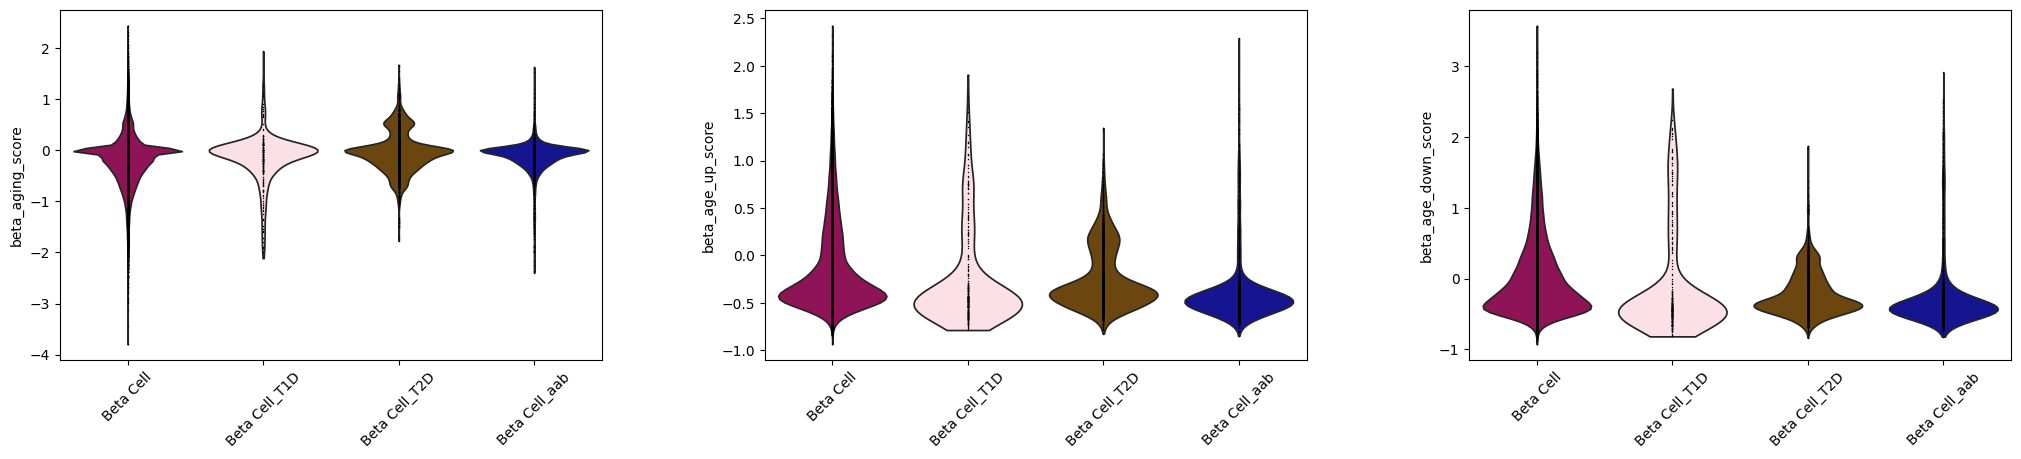

In [6]:
sc.pl.violin(
    beta_cells[
        beta_cells.obs["Level_3_extension_diabetes"].isin([
            "Beta Cell",
            "Beta Cell_T1D",
            "Beta Cell_T2D",
            "Beta Cell_aab",
        ])
    ],
    keys=["beta_aging_score", 'beta_age_up_score', 'beta_age_down_score'],
    groupby="Level_3_extension_diabetes",
    rotation=45, jitter=False
)

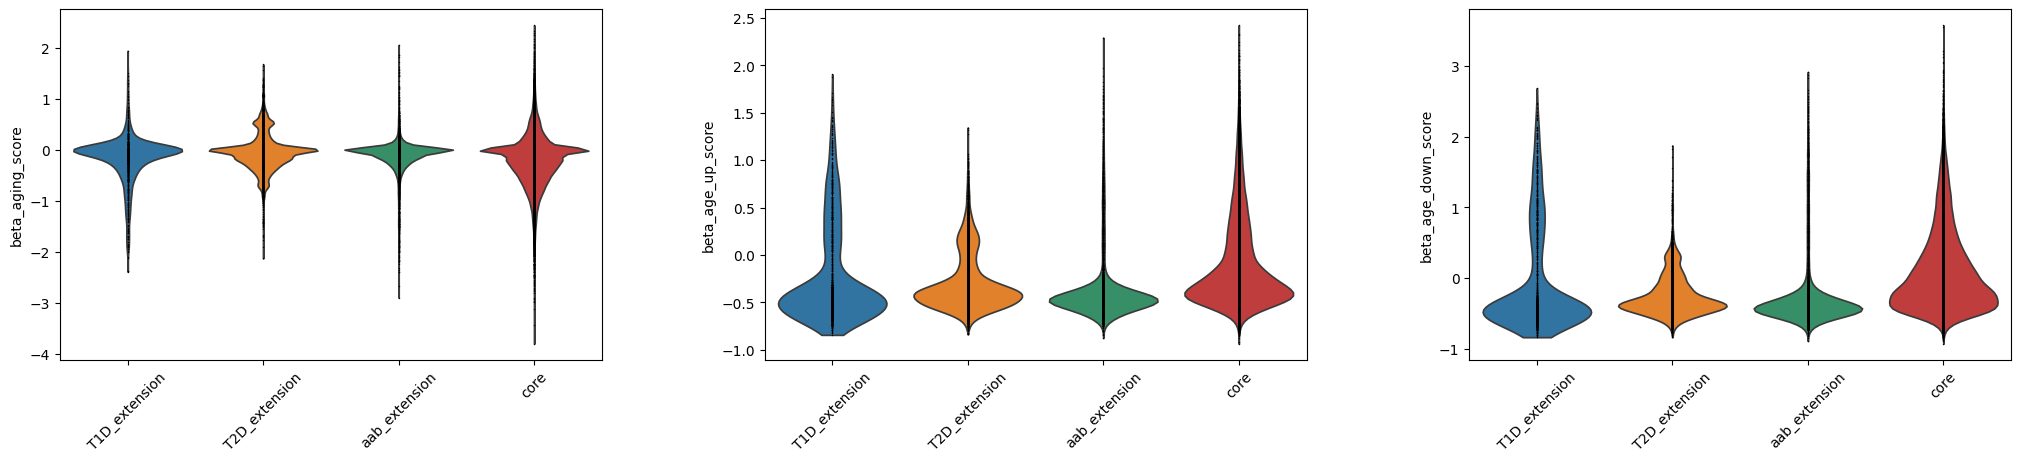

In [7]:
sc.pl.violin(
    beta_cells[
        beta_cells.obs["Level_3_extension_diabetes"].isin([
            "Beta Cell",
            "Beta Cell_T1D",
            "Beta Cell_T2D",
            "Beta Cell_aab",
        ])
    ],
    keys=["beta_aging_score", 'beta_age_up_score', 'beta_age_down_score'],
    groupby="source",
    rotation=45, jitter=False
)

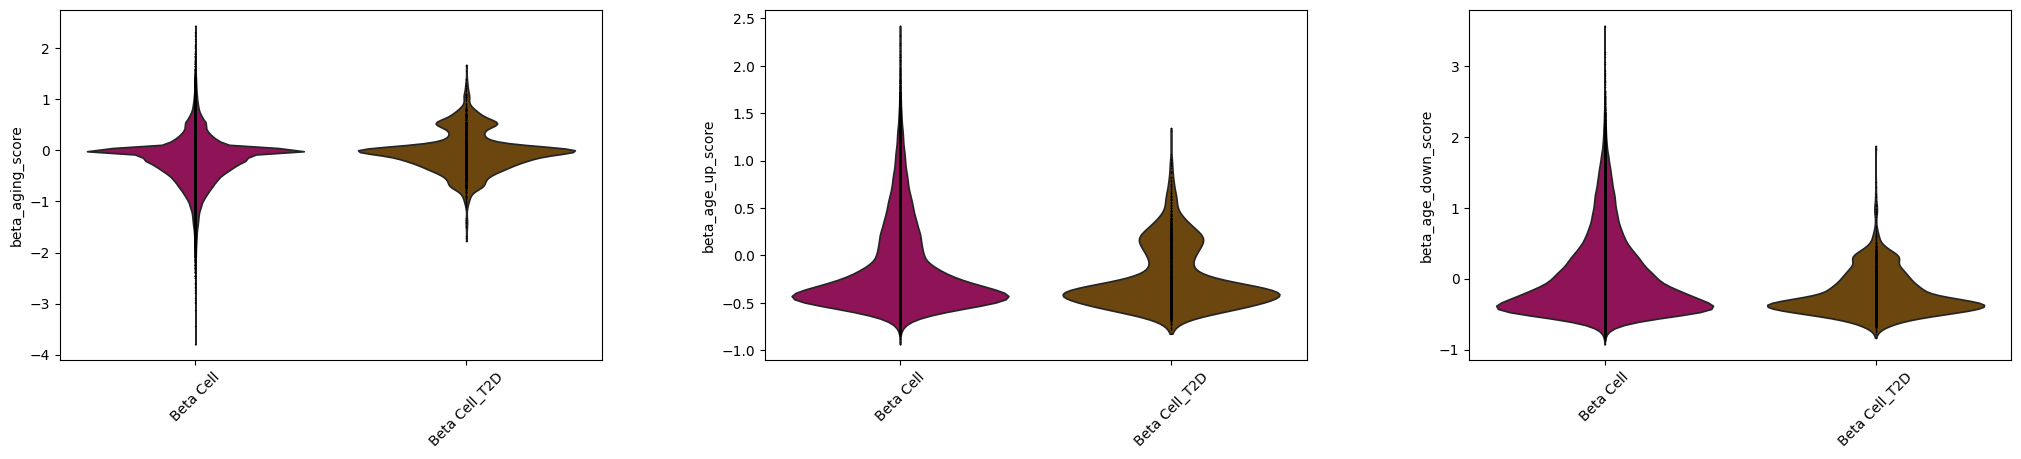

In [8]:
sc.pl.violin(
    beta_cells[
        beta_cells.obs["Level_3_extension_diabetes"].isin([
            "Beta Cell",
            # "Beta Cell_T1D",
            "Beta Cell_T2D",
            # "Beta Cell_aab",
        ])
    ],
    keys=["beta_aging_score", 'beta_age_up_score', 'beta_age_down_score'],
    groupby="Level_3_extension_diabetes",
    rotation=45, jitter=False
)

In [9]:
beta_cells[beta_cells.obs.source == 'T2D_extension'].obs.beta_age_up_score.describe()

count    14135.000000
mean        -0.292280
std          0.299217
min         -0.835977
25%         -0.492766
50%         -0.387081
75%         -0.186938
max          1.343811
Name: beta_age_up_score, dtype: float64

In [10]:
beta_cells[(beta_cells.obs.source == 'T2D_extension') & (beta_cells.obs.beta_age_up_score > 0)].obs

,barcode,Dataset,ID,sample_id,donor_id,alignment_software,assay_ontology_term_id,institute,library_id,library_preparation_batch,...,alpha_cell_uncertainty,beta_cell_uncertainty,delta_cell_uncertainty,pancreatic_polypeptide_cell_uncertainty,Level_3_extension_diabetes,Level_4_extension_diabetes,Disease_State,beta_age_up_score,beta_age_down_score,beta_aging_score
TTATTGCCATTGACCA-1_0,NaN,GSE251913,NaN,Islet_150_TR1,SAMN21845647,NaN,NaN,missing,NaN,NaN,...,NaN,NaN,NaN,NaN,Beta Cell,Beta Cell: Dedifferentiation-like,T2D,0.230713,0.406749,-0.176036
AAGACTCTCTTACCGC-1_0,NaN,GSE251913,NaN,Islet_150_TR1,SAMN21845647,NaN,NaN,missing,NaN,NaN,...,NaN,0.521622,NaN,NaN,Beta Cell,Beta Cell: Dedifferentiation-like,T2D,0.187366,0.573664,-0.386298
TCAGTTTTCGACATAC-1_0,NaN,GSE251913,NaN,Islet_150_TR1,SAMN21845647,NaN,NaN,missing,NaN,NaN,...,NaN,0.199732,NaN,NaN,Beta Cell,Beta Cell: INS_High,T2D,0.245632,0.427355,-0.181723
AATGAAGAGGTGCAGT-1_0,NaN,GSE251913,NaN,Islet_150_TR1,SAMN21845647,NaN,NaN,missing,NaN,NaN,...,NaN,0.607021,NaN,NaN,Beta Cell_T2D,Beta Cell: INS_High_T2D,T2D,0.003025,-0.437995,0.441020
GTTGCTCCACACGTGC-1_0,NaN,GSE251913,NaN,Islet_150_TR1,SAMN21845647,NaN,NaN,missing,NaN,NaN,...,NaN,0.420660,NaN,NaN,Beta Cell,Beta Cell: Interferon Response,T2D,0.166316,-0.375342,0.541659
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HPAP-109_TACTTACGTGGAAGTC-1_1,NaN,HPAP,NaN,HPAP-109,HPAP-109,NaN,NaN,missing,NaN,NaN,...,NaN,0.312914,NaN,NaN,Beta Cell,Beta Cell: INS_High,T2D,0.133348,-0.226229,0.359577
HPAP-109_TATTGGGAGAGTCTGG-1_1,NaN,HPAP,NaN,HPAP-109,HPAP-109,NaN,NaN,missing,NaN,NaN,...,NaN,0.327913,NaN,NaN,Beta Cell,Beta Cell: Immediate Early Activation,T2D,0.046421,-0.215790,0.262211
HPAP-109_TCGTAGAGTAGTCGGA-1_1,NaN,HPAP,NaN,HPAP-109,HPAP-109,NaN,NaN,missing,NaN,NaN,...,NaN,0.192221,NaN,NaN,Beta Cell,Beta Cell: High OxPhos,T2D,0.035998,-0.666297,0.702295
HPAP-109_TCTACCGTCGACACTA-1_1,NaN,HPAP,NaN,HPAP-109,HPAP-109,NaN,NaN,missing,NaN,NaN,...,NaN,0.469631,NaN,NaN,Beta Cell,Beta Cell: Immediate Early Activation,T2D,0.289096,-0.348230,0.637326


In [11]:
beta_cells[(beta_cells.obs.source == 'T2D_extension') & (beta_cells.obs.beta_age_up_score > 0)].obs.Dataset.value_counts()

Dataset
GSE251913    2355
HPAP          191
Name: count, dtype: int64

In [14]:
beta_cells.obs['Level_4_extension_diabetes_simplified'] = beta_cells.obs.Level_4_extension_diabetes.copy()
beta_cells.obs.Level_4_extension_diabetes_simplified = np.where(beta_cells.obs.Level_3_extension_diabetes.str.contains('T1D|T2D|aab'), beta_cells.obs.Level_3_extension_diabetes, beta_cells.obs.Level_4_extension_diabetes)
beta_cells.obs["Level_4_extension_diabetes_simplified"].unique().tolist()

['Beta Cell: Mature Identity',
 'Beta Cell: Dedifferentiation-like',
 'Beta Cell: High OxPhos',
 'Beta Cell: INS_Mid, IAPP_High',
 'Beta Cell: Immediate Early Activation',
 'Beta Cell: INS_Low',
 'Beta Cell: Interferon Response',
 'Beta Cell: Oxidative Stress',
 'Beta Cell: Ion Channel Activity',
 'Beta Cell: ER Stress',
 'Beta Cell: Secretory Granules',
 'Beta Cell: INS_High',
 'Beta Cell: Proliferating',
 'Beta Cell: INS_Mid',
 'Beta Cell: INS_High, IAPP_Low',
 'Beta Cell_T1D',
 'Beta Cell_T2D',
 'Beta Cell_aab']

In [15]:
beta_cells[(beta_cells.obs.source == 'T2D_extension') & (beta_cells.obs.beta_age_up_score > 0)].obs.Level_4_extension_diabetes_simplified.value_counts()

Level_4_extension_diabetes_simplified
Beta Cell_T2D                            835
Beta Cell: INS_High                      559
Beta Cell: Interferon Response           307
Beta Cell: Dedifferentiation-like        252
Beta Cell: High OxPhos                    97
Beta Cell: Proliferating                  90
Beta Cell: Immediate Early Activation     85
Beta Cell: Oxidative Stress               68
Beta Cell: Secretory Granules             67
Beta Cell: ER Stress                      55
Beta Cell: INS_Mid, IAPP_High             46
Beta Cell: INS_Mid                        43
Beta Cell: Mature Identity                34
Beta Cell: INS_Low                         4
Beta Cell: Ion Channel Activity            3
Beta Cell: INS_High, IAPP_Low              1
Name: count, dtype: int64

In [16]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from sklearn.model_selection import GroupShuffleSplit

In [17]:
def calibrate_healthy_reference_boundary(
    adata_sub,
    disease_labels,
    label_col="Level_4_extension_diabetes_simplified",
    source_col="source",
    donor_col="donor_id",
    rep_key="X_scvi",
    core_label="core",
    n_neighbors=50,
    test_size=0.25,
    random_state=0,
):
    """
    Calibrates healthy endocrine reference-space distances using held-out healthy donors,
    then compares disease cells against this healthy-to-healthy distance distribution.
    """

    obs = adata_sub.obs.copy()

    healthy_mask = (
        obs[source_col].astype(str).eq(core_label)
        & ~obs[label_col].astype(str).str.contains("T1D|T2D|aab", na=False)
    )

    disease_mask = obs[label_col].astype(str).isin(disease_labels)

    healthy_idx = np.where(healthy_mask.values)[0]
    disease_idx = np.where(disease_mask.values)[0]

    healthy_obs = obs.iloc[healthy_idx]

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=random_state,
    )

    train_rel, test_rel = next(
        splitter.split(
            healthy_obs,
            groups=healthy_obs[donor_col].values,
        )
    )

    healthy_train_idx = healthy_idx[train_rel]
    healthy_test_idx = healthy_idx[test_rel]

    X_train = normalize(adata_sub.obsm[rep_key][healthy_train_idx])
    X_test = normalize(adata_sub.obsm[rep_key][healthy_test_idx])
    X_disease = normalize(adata_sub.obsm[rep_key][disease_idx])

    nn = NearestNeighbors(
        n_neighbors=n_neighbors,
        metric="cosine",
        algorithm="brute",
    )
    nn.fit(X_train)

    # held-out healthy to healthy-reference distances
    healthy_dist, _ = nn.kneighbors(X_test)

    # disease to healthy-reference distances
    disease_dist, _ = nn.kneighbors(X_disease)

    def summarize_distances(dist):
        return {
            "mean_knn_distance": dist.mean(axis=1),
            "median_knn_distance": np.median(dist, axis=1),
            "min_knn_distance": dist.min(axis=1),
            "p90_knn_distance": np.quantile(dist, 0.90, axis=1),
        }

    healthy_summary = summarize_distances(healthy_dist)
    disease_summary = summarize_distances(disease_dist)

    healthy_df = pd.DataFrame(healthy_summary)
    healthy_df["group"] = "heldout_healthy"
    healthy_df["cell_id"] = adata_sub.obs_names[healthy_test_idx].values
    healthy_df["label"] = obs.iloc[healthy_test_idx][label_col].values
    healthy_df["donor"] = obs.iloc[healthy_test_idx][donor_col].values

    disease_df = pd.DataFrame(disease_summary)
    disease_df["group"] = "disease"
    disease_df["cell_id"] = adata_sub.obs_names[disease_idx].values
    disease_df["label"] = obs.iloc[disease_idx][label_col].values
    disease_df["donor"] = obs.iloc[disease_idx][donor_col].values

    out = pd.concat([healthy_df, disease_df], ignore_index=True)

    # healthy-calibrated thresholds
    thresholds = {
        "mean_knn_distance_p95": healthy_df["mean_knn_distance"].quantile(0.95),
        "mean_knn_distance_p99": healthy_df["mean_knn_distance"].quantile(0.99),
        "min_knn_distance_p95": healthy_df["min_knn_distance"].quantile(0.95),
        "min_knn_distance_p99": healthy_df["min_knn_distance"].quantile(0.99),
    }

    out["outside_healthy_p95"] = (
        out["mean_knn_distance"] > thresholds["mean_knn_distance_p95"]
    )

    out["outside_healthy_p99"] = (
        out["mean_knn_distance"] > thresholds["mean_knn_distance_p99"]
    )

    return out, thresholds

In [18]:
beta_disease_labels = [
    "Beta Cell_T1D",
    "Beta Cell_T2D",
    "Beta Cell_aab",
]

beta_boundary_df, beta_thresholds = calibrate_healthy_reference_boundary(
    beta_cells,
    disease_labels=beta_disease_labels,
    label_col="Level_4_extension_diabetes_simplified",
    source_col="source",
    donor_col="donor_id",
    rep_key="X_scvi",
    n_neighbors=50,
)

beta_thresholds

{'mean_knn_distance_p95': np.float64(0.07749888859689227),
 'mean_knn_distance_p99': np.float64(0.11265742138028143),
 'min_knn_distance_p95': np.float64(0.04244761168956754),
 'min_knn_distance_p99': np.float64(0.06586396872997267)}

In [28]:
beta_boundary_df.head()

,mean_knn_distance,median_knn_distance,min_knn_distance,p90_knn_distance,group,cell_id,label,donor,outside_healthy_p95,outside_healthy_p99
0,0.038998,0.041051,0.016299,0.047584,heldout_healthy,AACCTCCATCAT_GSM2700339_GeneFull_filtered,Beta Cell: Ion Channel Activity,Non_diabetic_donor_2,False,False
1,0.070470,0.070361,0.036239,0.083888,heldout_healthy,AACTTCCTACAA_GSM2700339_GeneFull_filtered,Beta Cell: ER Stress,Non_diabetic_donor_2,False,False
2,0.041548,0.043677,0.017787,0.053491,heldout_healthy,AACTTCCTACAC_GSM2700339_GeneFull_filtered,Beta Cell: Immediate Early Activation,Non_diabetic_donor_2,False,False
3,0.034155,0.035945,0.013959,0.045112,heldout_healthy,AACTTCCTACAG_GSM2700339_GeneFull_filtered,Beta Cell: Immediate Early Activation,Non_diabetic_donor_2,False,False
4,0.041291,0.042543,0.025026,0.045786,heldout_healthy,AACTTCCTACAT_GSM2700339_GeneFull_filtered,Beta Cell: INS_Low,Non_diabetic_donor_2,False,False


In [20]:
alpha_cells = adata[adata.obs.Level_3_extension_diabetes.str.contains('Alpha')].copy()

In [21]:
alpha_cells

AnnData object with n_obs × n_vars = 143120 × 36805
    obs: 'barcode', 'Dataset', 'ID', 'sample_id', 'donor_id', 'alignment_software', 'assay_ontology_term_id', 'institute', 'library_id', 'library_preparation_batch', 'library_sequencing_run', 'Manual_Annotation', 'cell_enrichment', 'condition', 'celltype_all', 'manner_of_death', 'reference_genome', 'sample_collection_method', 'sample_source', 'sampled_site_condition', 'samples', 'sex', 'sex--cell_ontology_term_id', 'suspension_type', 'technology', 'tissue_type', 'assay', 'tissue', 'organism', 'disease', 'gene_annotation_version', 'batch_covar_split', 'batch_covar_split_donor_id', 'batch_covariate', 'info_batch_covariate_split', 'doublet_score', 'predicted_doublet', 'n_genes', 'total_counts', 'total_counts_mito', 'total_counts_ribo', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mito', 'log1p_total_counts_ribo', 'n_genes_by_counts', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_

In [23]:
alpha_cells.obs['Level_4_extension_diabetes_simplified'] = alpha_cells.obs.Level_4_extension_diabetes.copy()
alpha_cells.obs.Level_4_extension_diabetes_simplified = np.where(alpha_cells.obs.Level_3_extension_diabetes.str.contains('T1D|T2D|aab'), alpha_cells.obs.Level_3_extension_diabetes, alpha_cells.obs.Level_4_extension_diabetes)
alpha_cells.obs["Level_4_extension_diabetes_simplified"].unique().tolist()

['Alpha Cell: GCG_Low',
 'Alpha Cell: Mature Identity',
 'Alpha Cell: ER Stress',
 'Alpha Cell: High OxPhos',
 'Alpha Cell: GCG_High',
 'Alpha Cell: GCG_Mid',
 'Alpha Cell: Interferon Response',
 'Alpha Cell: Oxidative Stress',
 'Alpha Cell: Dedifferentiation-like',
 'Alpha Cell: Proliferating',
 'Alpha Cell: GCG_Low, POU6F2_High',
 'Alpha Cell: GCG_High, IRX2_High',
 'Alpha Cell_T1D',
 'Alpha Cell_T2D',
 'Alpha Cell_aab']

In [24]:
alpha_disease_labels = [
    "Alpha Cell_T1D",
    "Alpha Cell_T2D",
    "Alpha Cell_aab",
]

alpha_boundary_df, alpha_thresholds = calibrate_healthy_reference_boundary(
    alpha_cells,
    disease_labels=alpha_disease_labels,
    label_col="Level_4_extension_diabetes_simplified",
    source_col="source",
    donor_col="donor_id",
    rep_key="X_scvi",
    n_neighbors=50,
)

alpha_thresholds

{'mean_knn_distance_p95': np.float64(0.10285073071718213),
 'mean_knn_distance_p99': np.float64(0.15428277075290672),
 'min_knn_distance_p95': np.float64(0.05572214126586914),
 'min_knn_distance_p99': np.float64(0.08772474765777585)}

In [25]:
def summarize_boundary(boundary_df):
    return (
        boundary_df
        .query("group == 'disease'")
        .groupby("label")
        .agg(
            n_cells=("cell_id", "count"),
            mean_distance=("mean_knn_distance", "mean"),
            median_distance=("mean_knn_distance", "median"),
            frac_outside_p95=("outside_healthy_p95", "mean"),
            frac_outside_p99=("outside_healthy_p99", "mean"),
        )
        .sort_values("frac_outside_p95", ascending=False)
    )

beta_boundary_summary = summarize_boundary(beta_boundary_df)
alpha_boundary_summary = summarize_boundary(alpha_boundary_df)

display(beta_boundary_summary)
display(alpha_boundary_summary)

,n_cells,mean_distance,median_distance,frac_outside_p95,frac_outside_p99
label,,,,,
Beta Cell_T2D,3410,0.060855,0.054671,0.192375,0.051320
Beta Cell_T1D,396,0.047786,0.044933,0.098485,0.017677
Beta Cell_aab,2621,0.044183,0.042650,0.032430,0.001145


,n_cells,mean_distance,median_distance,frac_outside_p95,frac_outside_p99
label,,,,,
Alpha Cell_T2D,4752,0.069261,0.064473,0.125000,0.022096
Alpha Cell_T1D,2646,0.063369,0.060525,0.069917,0.008692
Alpha Cell_aab,1996,0.055881,0.053650,0.034068,0.002505


In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_boundary_distances(boundary_df, title):
    plot_df = boundary_df.copy()

    plt.figure(figsize=(12, 6), dpi=300)
    sns.boxplot(
        data=plot_df,
        x="label",
        y="mean_knn_distance",
        hue="group",
        showfliers=False,
    )
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.ylabel("Mean distance to healthy reference")
    plt.xlabel("")
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(title)
    plt.tight_layout()
    plt.show()

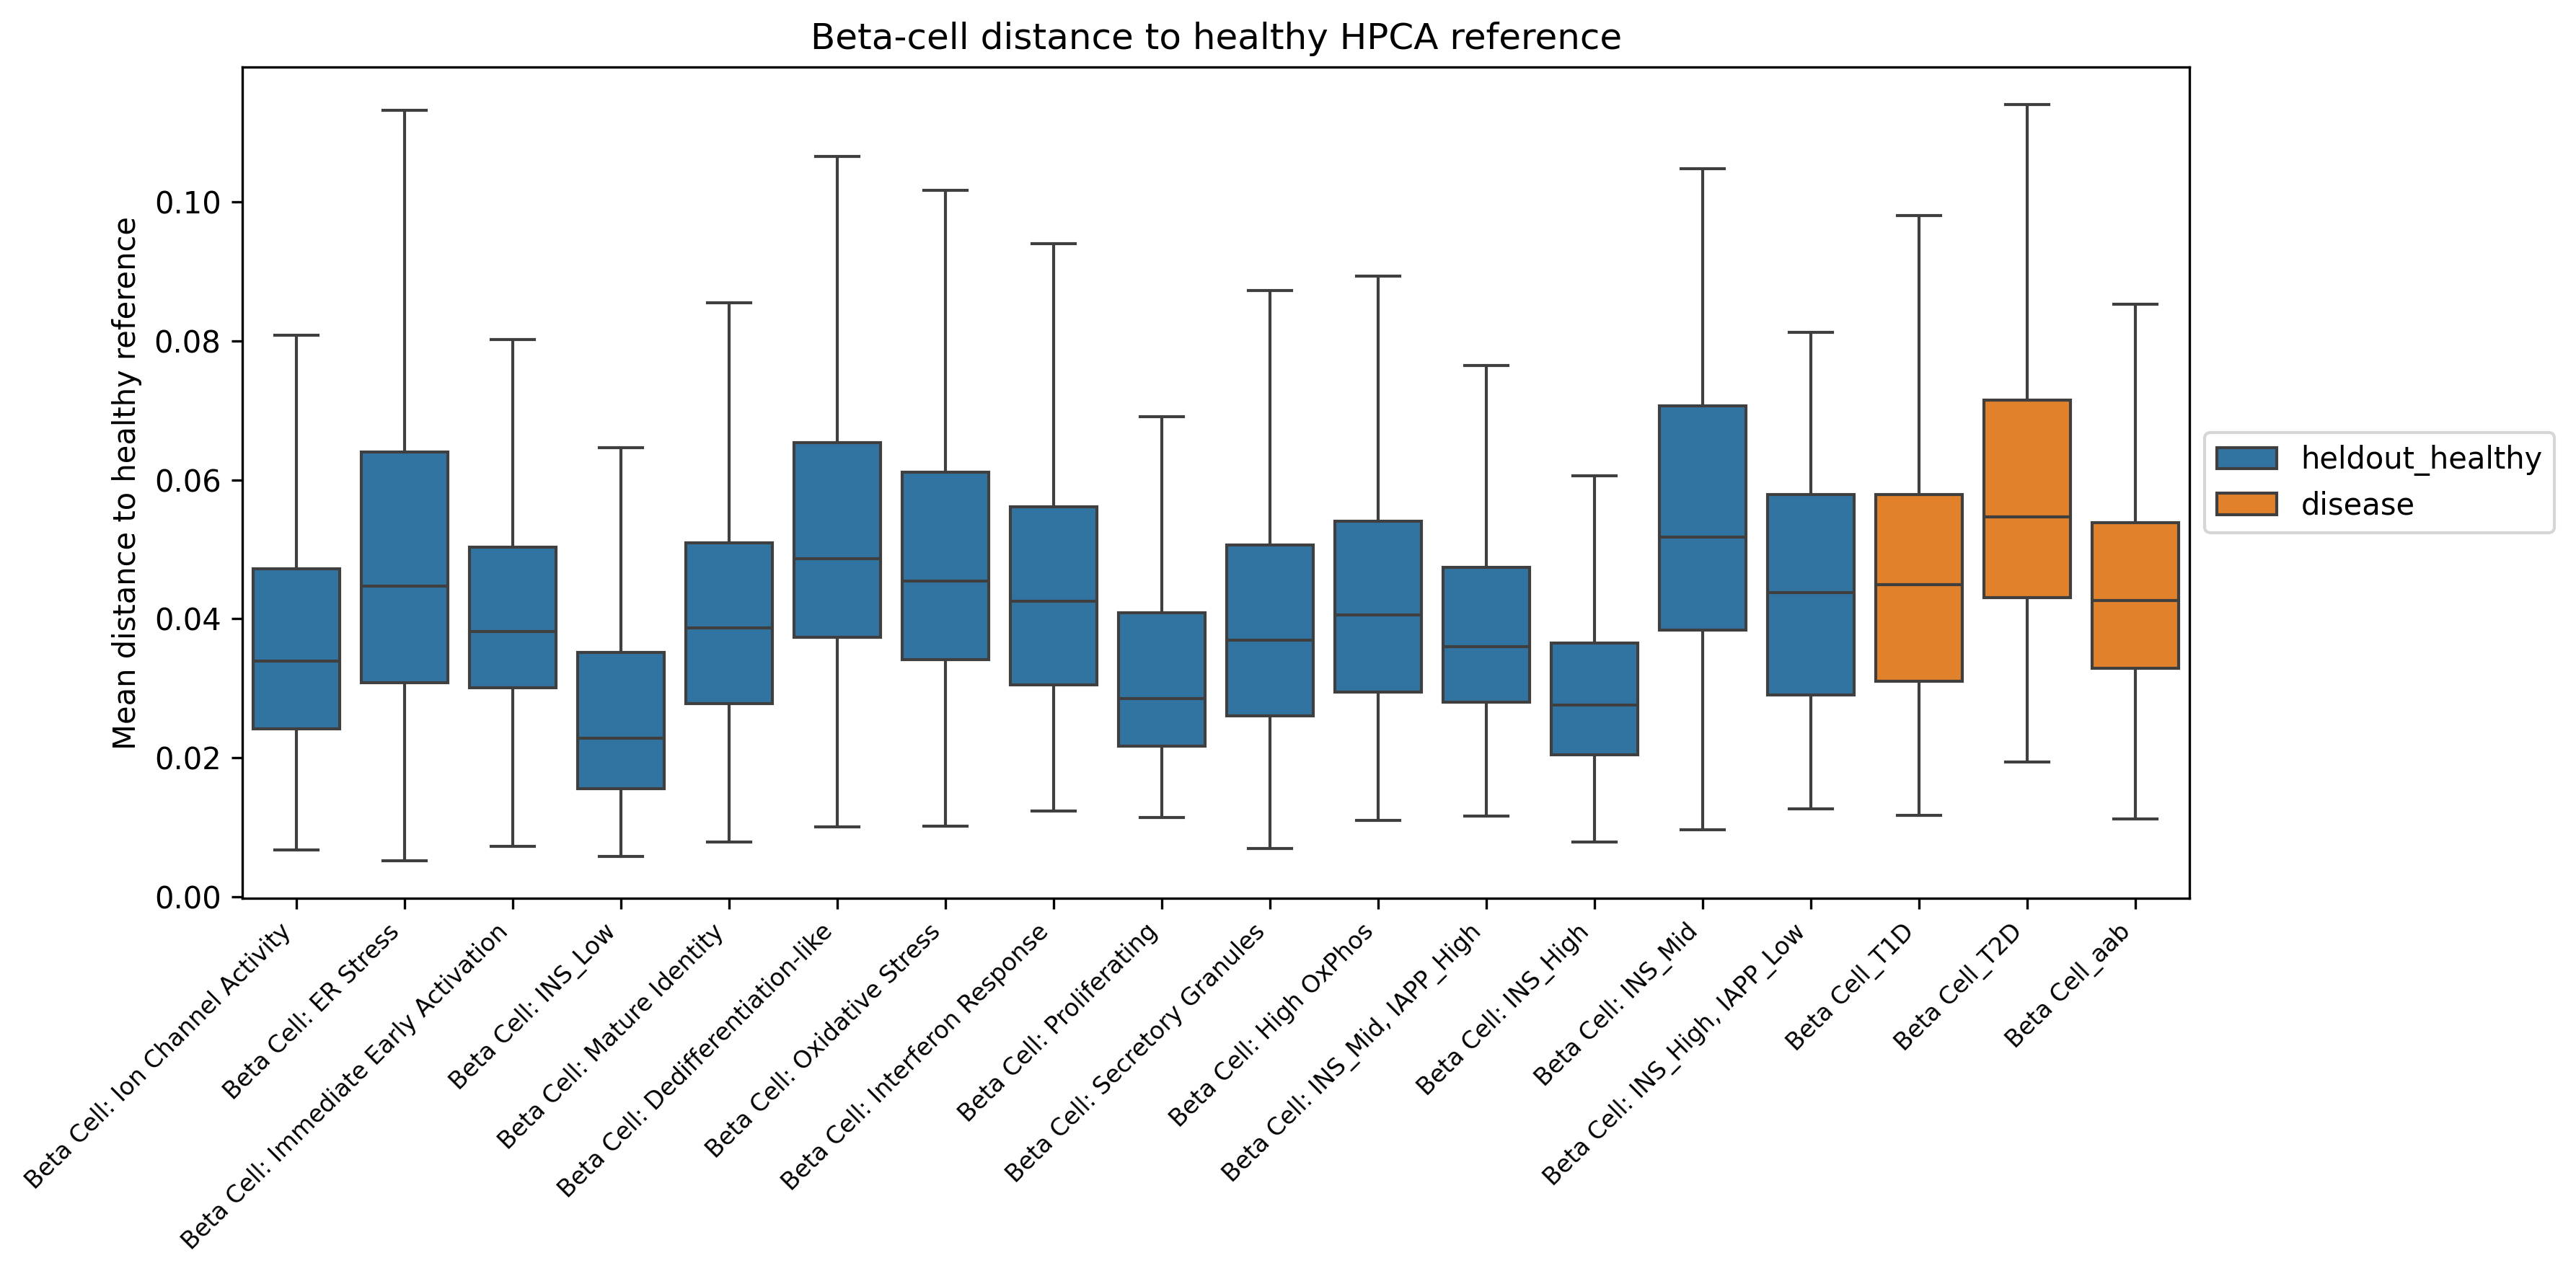

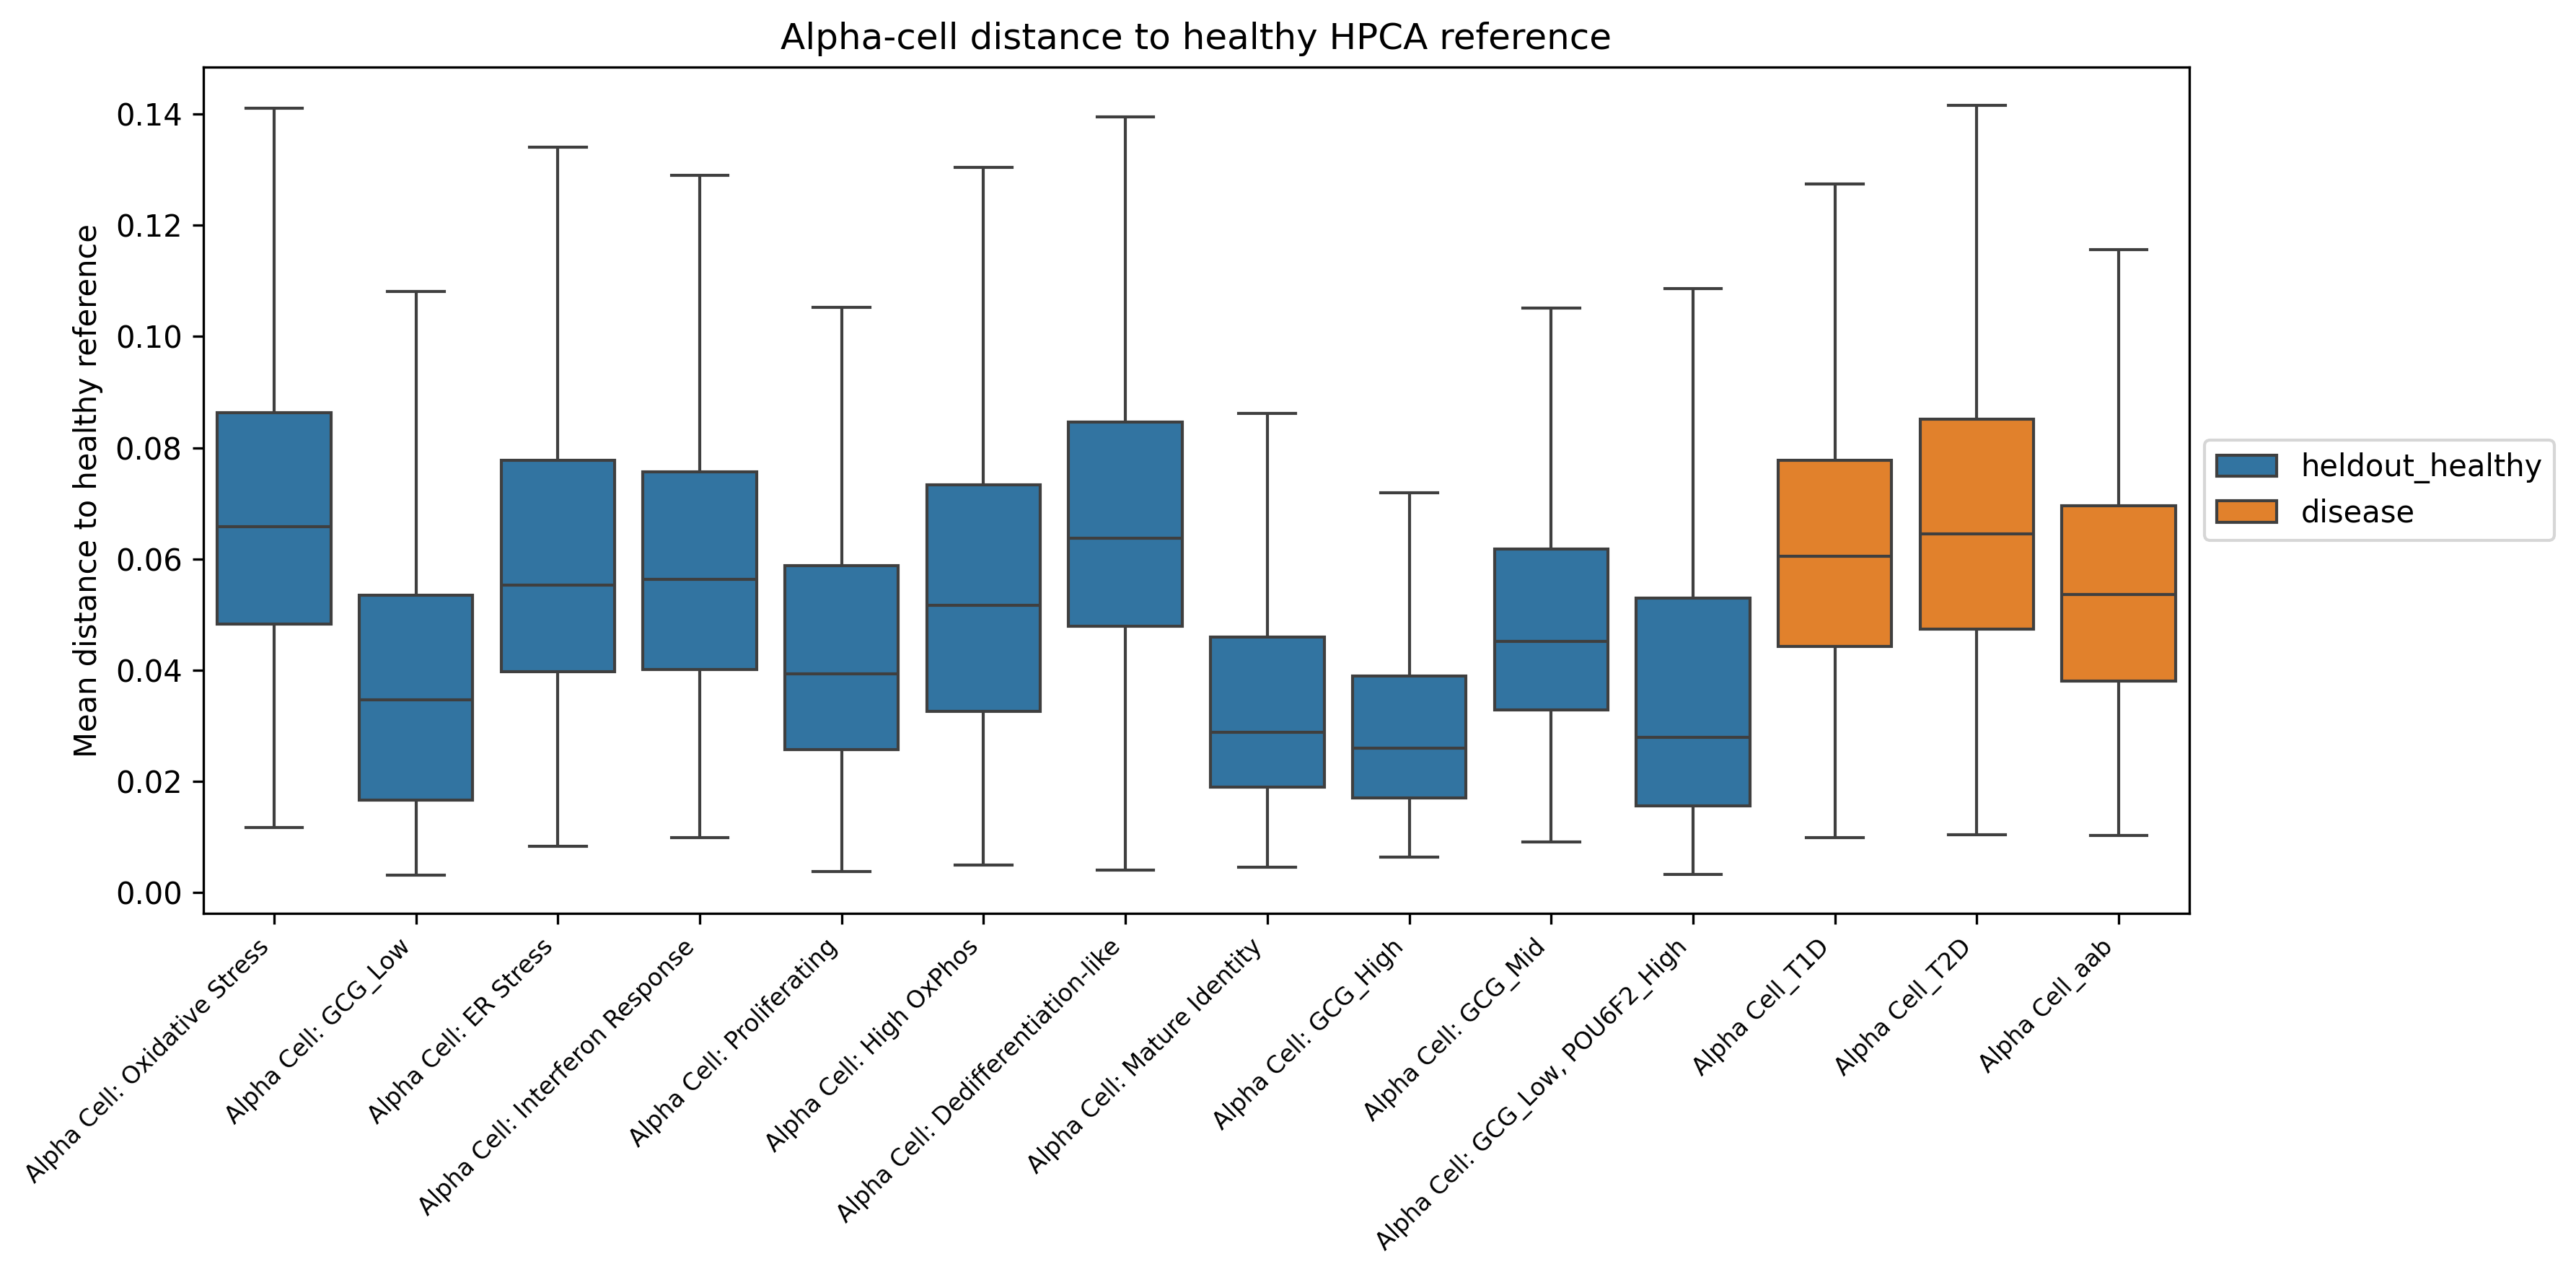

In [39]:
plot_boundary_distances(
    beta_boundary_df,
    "Beta-cell distance to healthy HPCA reference",
)

plot_boundary_distances(
    alpha_boundary_df,
    "Alpha-cell distance to healthy HPCA reference",
)